# Megadrought Analysis — Chilean Glacier Melt and Streamflow
### `megadrought_analysis.ipynb` | Millie Spencer | 2026

This notebook investigates how the Chilean Megadrought affected glacier melt
contributions to streamflow across Chile's latitudinal gradient. We compare
three drought period definitions against a 2000-2009 pre-drought baseline:

- **Period 1**: 2010-2019 (broad megadrought, Garreaud et al. 2020)
- **Period 2**: 2013-2019 (core intensification phase)
- **Period 3**: 2015-2019 (most severe phase)

For each period we ask:
1. How much did precipitation actually decline (empirical validation of period choice)?
2. Did glacier melt increase, decrease, or stay the same in absolute terms?
3. Did the relative importance of glacier melt (fraction of Q) increase?
4. Was the drought a conventional precipitation drought, a snow drought (warm + dry winter),
   or both?
5. How did temperature and PET change, and did these drive additional melt?

**Snow drought lens** (advisor suggestion): years where winter precipitation is
anomalously low or falls as rain rather than snow, reducing snowpack and making
glacier melt proportionally more important as a summer water source.


## 0. Imports, paths, and standalone setup

In [1]:
import os, pickle, calendar, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from scipy import stats
import geopandas as gpd
warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────
BASE_PATH    = '/Users/milliespencer/Desktop/CR2_OGGM_Paper'
OUTPUT_ROOT  = f'{BASE_PATH}/Output'
CAMELS_FULL  = (f'{BASE_PATH}/Full_CAMELS_all_basins/CAMELS_CL_v202201')
RGI_PATH     = (f'{BASE_PATH}/files_chile_OGGM_climate_comparison/'
                f'RGI_BNA_Clusters.csv')
BOUNDS_PATH  = (f'{CAMELS_FULL}/camels_cl_boundaries/'
                f'camels_cl_boundaries.shp')
OUT_DIR      = f'{OUTPUT_ROOT}/all_chile_results_v2'
DROUGHT_DIR  = f'{OUT_DIR}/megadrought_analysis'
os.makedirs(DROUGHT_DIR, exist_ok=True)

# ── Constants ──────────────────────────────────────────────────────────────
YEARS         = list(range(2000, 2020))
MONTHS        = list(range(1, 13))
YEAR_OFFSET   = 1
WATER_DENSITY = 1000
CLUSTERS      = ['OT3','DA1','DA2','DA3','WA1','WA2','WA3','WA4','WA5','WA6']
DATASETS      = {'CR2MET': 'TC', 'ERA5': 'ERA5', 'CRU': 'CRU'}
DS_COLORS     = {'CR2MET': '#1f77b4', 'ERA5': '#ff7f0e', 'CRU': '#2ca02c'}
REGION_LABELS = {
    'OT3': 'Altiplano',     'DA1': 'Dry Andes N',
    'DA2': 'Dry Andes C',   'DA3': 'Dry Andes S',
    'WA1': 'Wet Andes N',   'WA2': 'Wet Andes C',
    'WA3': 'N Patagonia',   'WA4': 'S Patagonia',
    'WA5': 'Patagonia',     'WA6': 'Tierra del Fuego',
}
BASELINE     = list(range(2000, 2010))
DROUGHT_DEFS = {
    'Baseline (2000-2009)':  list(range(2000, 2010)),
    'Drought 1 (2010-2019)': list(range(2010, 2020)),
    'Drought 2 (2013-2019)': list(range(2013, 2020)),
    'Drought 3 (2015-2019)': list(range(2015, 2020)),
}
DROUGHT_COLORS = {
    'Baseline (2000-2009)':  '#2ecc71',
    'Drought 1 (2010-2019)': '#f39c12',
    'Drought 2 (2013-2019)': '#e67e22',
    'Drought 3 (2015-2019)': '#c0392b',
}
SUMMER = [12, 1, 2]
WINTER = [6, 7, 8]

def nc_path(dataset_name, cluster):
    tag = DATASETS[dataset_name]
    return (f'{OUTPUT_ROOT}/{dataset_name}/{cluster}/'
            f'run_output_2000_2019_hydro_{tag}_{cluster}.nc')

# ── Load RESULTS ───────────────────────────────────────────────────────────
print('Loading RESULTS from pickle...')
with open(f'{OUT_DIR}/RESULTS.pkl', 'rb') as f:
    RESULTS = pickle.load(f)
print(f'  RESULTS loaded: {len(RESULTS["CR2MET"])} gauges')

# ── Rebuild GAUGE_INFO_FRAC from saved CSVs ────────────────────────────────
# Use the gauge completeness CSV saved by the main notebook
# instead of re-running the slow daily completeness filter
print('Loading spatial join and completeness data...')

nested_csv = pd.read_csv(f'{OUT_DIR}/spatial_join_nested.csv',
                         dtype={'gauge_id': str})
comp_csv   = pd.read_csv(f'{OUT_DIR}/gauge_completeness_assessment.csv',
                         dtype={'gauge_id': str})

# Build GAUGE_INFO from nested CSV
GAUGE_INFO = {}
for gauge_id, grp in nested_csv.groupby('gauge_id'):
    GAUGE_INFO[gauge_id] = {
        'gauge_name':       grp['gauge_name'].iloc[0],
        'rgi_ids':          grp['RGIId'].tolist(),
        'n_glaciers':       len(grp),
        'glacier_area_km2': grp['Area'].sum(),
        'basin_area_km2':   grp['area_km2'].iloc[0],
        'clusters':         sorted(grp['Cluster'].unique().tolist()),
        'cen_lat':          grp['CenLat'].mean(),
        'cen_lon':          grp['CenLon'].mean(),
    }

# Load q_wide for streamflow data (monthly, much faster than daily)
q_wide = pd.read_csv(f'{CAMELS_FULL}/q_m3s_mon.csv', parse_dates=['date'])
q_wide = q_wide[(q_wide['year'] >= 2000) &
                (q_wide['year'] <= 2019)].reset_index(drop=True)

# Build GAUGE_INFO_FRAC using completeness CSV
# The main notebook saved which gauges pass and their complete_years
gauges_in_results = set(RESULTS['CR2MET'].keys())
GAUGE_INFO_FRAC   = {}

for _, row in comp_csv[comp_csv['passes'] == True].iterrows():
    gauge_id = str(row['gauge_id'])
    if gauge_id not in gauges_in_results:
        continue
    if gauge_id not in GAUGE_INFO:
        continue
    info = dict(GAUGE_INFO[gauge_id])
    # Reconstruct complete_years from RESULTS if available
    res = RESULTS['CR2MET'].get(gauge_id)
    if res is not None and 'complete_years' in res:
        info['complete_years'] = res['complete_years']
    else:
        # Fall back: use all years with valid Q
        info['complete_years'] = YEARS
    GAUGE_INFO_FRAC[gauge_id] = info

# Remove the 6 high-frac excluded gauges
excluded = pd.read_csv(f'{OUT_DIR}/excluded_high_frac_gauges.csv',
                       dtype={'gauge_id': str})
for gauge_id in excluded['gauge_id'].tolist():
    GAUGE_INFO_FRAC.pop(gauge_id, None)

print(f'  GAUGE_INFO:      {len(GAUGE_INFO)} gauges')
print(f'  GAUGE_INFO_FRAC: {len(GAUGE_INFO_FRAC)} gauges (after exclusions)')
print()
print('Cell 0 complete')

Loading RESULTS from pickle...
  RESULTS loaded: 143 gauges
Loading spatial join and completeness data...
  GAUGE_INFO:      266 gauges
  GAUGE_INFO_FRAC: 137 gauges (after exclusions)

Cell 0 complete


## I. Load CAMELS-CL basin-average climate data

We load basin-average monthly precipitation, temperature, tmax, tmin, and PET
from CAMELS-CL (CR2MET). These are the climate variables we will use to:
1. Empirically validate our drought period definitions
2. Diagnose whether drought years were precipitation-driven, temperature-driven,
   or snow-drought (warm + dry winter) events
3. Decompose the drivers of increased glacier fraction during drought


In [2]:
print('Loading CAMELS-CL climate...')

def load_camels_mon(fname, value_name, year_range=(2000,2019)):
    df = pd.read_csv(f'{CAMELS_FULL}/{fname}')
    df = df[(df['year'] >= year_range[0]) &
            (df['year'] <= year_range[1])].copy()
    gauge_cols = [c for c in df.columns
                  if c not in ['date','year','month','day']]
    return df[['year','month'] + gauge_cols]

precip_df = load_camels_mon('precip_cr2met_mm_mon.csv',  'precip')
tmean_df  = load_camels_mon('tmean_cr2met_C_mon.csv',    'tmean')
tmax_df   = load_camels_mon('tmax_cr2met_C_mon.csv',     'tmax')
tmin_df   = load_camels_mon('tmin_cr2met_C_mon.csv',     'tmin')
pet_df    = load_camels_mon('pet_hargreaves_mm_mon.csv', 'pet')

print(f'Precip:  {precip_df.shape}')
print(f'Tmean:   {tmean_df.shape}')
print(f'PET:     {pet_df.shape}')
print('CAMELS-CL climate loaded')


Loading CAMELS-CL climate...
Precip:  (240, 518)
Tmean:   (240, 519)
PET:     (240, 518)
CAMELS-CL climate loaded


## II. Empirical validation of drought period definitions

Before comparing glacier melt across periods, we confirm that our three drought
period definitions correspond to real precipitation deficits in the CAMELS-CL
data. We compute annual and seasonal precipitation anomalies relative to the
2000-2009 baseline for each cluster, using the basin-average CR2MET data.

This addresses the key question: do 2010-2019, 2013-2019, and 2015-2019
represent progressively more severe drought conditions, or are the differences
minor?


Computing annual climate aggregations...
  ann_precip: (20, 516)
  ann_tmean:  (20, 516)
Annual aggregations done — computing cluster means...
  WA5: no gauges found — skipping
Climate DataFrame built: (180, 7)

Annual precipitation anomaly vs 2000-2009 baseline (%) by period:
Cluster  Drought 1 (2010-2019)   Drought 2 (2013-2019)   Drought 3 (2015-2019) 
--------------------------------------------------------------------------------
OT3     -1.1%                    -5.3%                    -1.5%                  
DA1     -3.6%                    +1.2%                    +15.8%                  
DA2     -40.0%                    -37.5%                    -36.3%                  
DA3     -29.6%                    -28.6%                    -28.0%                  
WA1     -16.6%                    -15.9%                    -17.2%                  
WA2     -5.0%                    -5.5%                    -7.5%                  
WA3     +9.5%                    +9.4%                    +

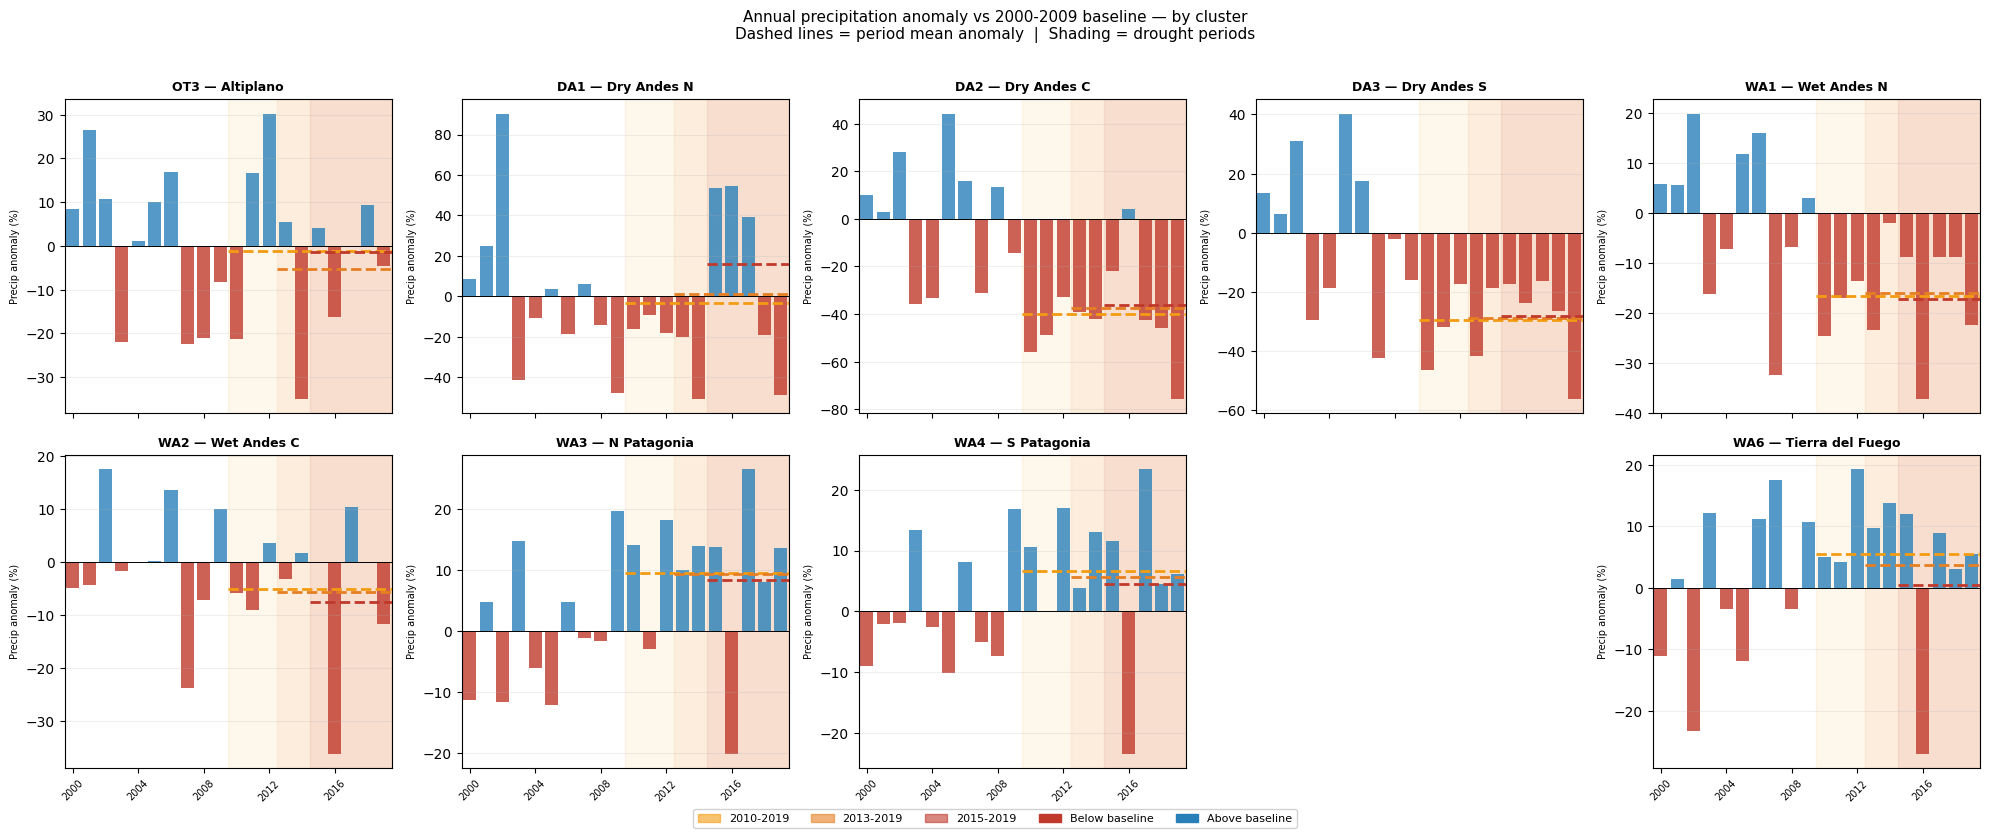

In [3]:
# ── Cell 2: Empirical validation of drought period definitions ─────────────
#
# Computes annual and seasonal precipitation anomalies relative to the
# 2000-2009 baseline for each cluster, using basin-average CR2MET data.
# Validates that our three drought period definitions correspond to real
# precipitation deficits in the data.

NON_GAUGE = ['date', 'year', 'month', 'day']

cluster_gauges = {cl: [gid for gid, info in GAUGE_INFO_FRAC.items()
                        if info['clusters'][0] == cl]
                  for cl in CLUSTERS}

print('Computing annual climate aggregations...')

def season_agg(df, months, agg='sum'):
    gauge_cols = [c for c in df.columns if c not in NON_GAUGE]
    sub = df[df['month'].isin(months)][['year'] + gauge_cols]
    if agg == 'sum':
        return sub.groupby('year')[gauge_cols].sum(numeric_only=True)
    return sub.groupby('year')[gauge_cols].mean(numeric_only=True)

ann_precip = season_agg(precip_df, list(range(1,13)), 'sum')
sum_precip = season_agg(precip_df, SUMMER,            'sum')
win_precip = season_agg(precip_df, WINTER,            'sum')
ann_tmean  = season_agg(tmean_df,  list(range(1,13)), 'mean')
ann_pet    = season_agg(pet_df,    list(range(1,13)), 'sum')

print(f'  ann_precip: {ann_precip.shape}')
print(f'  ann_tmean:  {ann_tmean.shape}')
print('Annual aggregations done — computing cluster means...')

# ── Cluster-mean timeseries ────────────────────────────────────────────────
clim_records = []
for cl in CLUSTERS:
    gauges = [g for g in cluster_gauges[cl] if g in ann_precip.columns]
    if not gauges:
        print(f'  {cl}: no gauges found — skipping')
        continue
    for year in YEARS:
        def get_val(df_wide, yr):
            if yr not in df_wide.index:
                return np.nan
            cols = [g for g in gauges if g in df_wide.columns]
            return df_wide.loc[yr, cols].mean() if cols else np.nan

        clim_records.append({
            'cluster':    cl,
            'year':       year,
            'precip_ann': get_val(ann_precip, year),
            'precip_sum': get_val(sum_precip, year),
            'precip_win': get_val(win_precip, year),
            'tmean_ann':  get_val(ann_tmean,  year),
            'pet_ann':    get_val(ann_pet,    year),
        })

df_clim = pd.DataFrame(clim_records)
print(f'Climate DataFrame built: {df_clim.shape}')

# ── Compute anomalies vs 2000-2009 baseline ───────────────────────────────
baseline_means = (df_clim[df_clim['year'].isin(BASELINE)]
                  .groupby('cluster')[
                      ['precip_ann','precip_sum','precip_win',
                       'tmean_ann','pet_ann']].mean()
                  .rename(columns=lambda c: c + '_base'))

df_clim = df_clim.merge(baseline_means, on='cluster', how='left')
df_clim['precip_ann_anom_pct'] = ((df_clim['precip_ann'] -
                                    df_clim['precip_ann_base']) /
                                   df_clim['precip_ann_base'] * 100)
df_clim['precip_win_anom_pct'] = ((df_clim['precip_win'] -
                                    df_clim['precip_win_base']) /
                                   df_clim['precip_win_base'] * 100)
df_clim['tmean_anom']          = (df_clim['tmean_ann'] -
                                   df_clim['tmean_ann_base'])
df_clim['pet_anom_pct']        = ((df_clim['pet_ann'] -
                                    df_clim['pet_ann_base']) /
                                   df_clim['pet_ann_base'] * 100)

# ── Period means table ────────────────────────────────────────────────────
print('\nAnnual precipitation anomaly vs 2000-2009 baseline (%) by period:')
print(f'{"Cluster":6s}', end='')
for period_label in list(DROUGHT_DEFS.keys())[1:]:
    print(f'  {period_label:22s}', end='')
print()
print('-' * 80)

for cl in CLUSTERS:
    cl_df = df_clim[df_clim['cluster'] == cl]
    if len(cl_df) == 0:
        continue
    print(f'{cl:6s}', end='')
    for period_label, years in list(DROUGHT_DEFS.items())[1:]:
        anom = cl_df[cl_df['year'].isin(years)]['precip_ann_anom_pct'].mean()
        print(f'  {anom:+.1f}%{" "*18}', end='')
    print()

# ── Figure ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True)
axes_flat = axes.flatten()

for ax, cl in zip(axes_flat, CLUSTERS):
    cl_df = df_clim[df_clim['cluster'] == cl].set_index('year')
    if len(cl_df) == 0:
        ax.set_visible(False)
        continue

    colors = ['#c0392b' if v < 0 else '#2980b9'
              for v in cl_df['precip_ann_anom_pct']]
    ax.bar(cl_df.index, cl_df['precip_ann_anom_pct'],
           color=colors, alpha=0.8, edgecolor='none')
    ax.axhline(0, color='k', lw=0.7)

    # Shade drought periods
    for period_label, years in list(DROUGHT_DEFS.items())[1:]:
        ax.axvspan(min(years)-0.5, max(years)+0.5,
                   color=DROUGHT_COLORS[period_label],
                   alpha=0.08, zorder=0)

    # Period mean anomaly lines
    for period_label, years in list(DROUGHT_DEFS.items())[1:]:
        mean_anom = cl_df.loc[
            cl_df.index.isin(years), 'precip_ann_anom_pct'].mean()
        if not np.isnan(mean_anom):
            ax.hlines(mean_anom, min(years)-0.5, max(years)+0.5,
                      color=DROUGHT_COLORS[period_label],
                      lw=2, ls='--', zorder=5)

    ax.set_title(f'{cl} — {REGION_LABELS[cl]}', fontsize=9,
                 fontweight='bold')
    ax.set_ylabel('Precip anomaly (%)', fontsize=7)
    ax.set_xlim(1999.5, 2019.5)
    ax.set_xticks(range(2000, 2020, 4))
    ax.tick_params(labelsize=7, axis='x', rotation=45)
    ax.grid(True, alpha=0.2, axis='y')

fig.legend(
    handles=[
        Patch(color=DROUGHT_COLORS['Drought 1 (2010-2019)'], alpha=0.6,
              label='2010-2019'),
        Patch(color=DROUGHT_COLORS['Drought 2 (2013-2019)'], alpha=0.6,
              label='2013-2019'),
        Patch(color=DROUGHT_COLORS['Drought 3 (2015-2019)'], alpha=0.6,
              label='2015-2019'),
        Patch(color='#c0392b', label='Below baseline'),
        Patch(color='#2980b9', label='Above baseline'),
    ],
    loc='lower center', ncol=5, fontsize=8,
    bbox_to_anchor=(0.5, -0.02), framealpha=0.9)

fig.suptitle(
    'Annual precipitation anomaly vs 2000-2009 baseline — by cluster\n'
    'Dashed lines = period mean anomaly  |  Shading = drought periods',
    fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(f'{DROUGHT_DIR}/precip_anomaly_by_cluster.png',
            dpi=150, bbox_inches='tight')
plt.show()

## III. Snow drought diagnosis

A snow drought occurs when winter precipitation is anomalously low OR falls
as rain rather than snow due to warm temperatures, reducing snowpack and
amplifying the importance of glacier melt in summer.

We distinguish two types:
- **Dry snow drought**: below-normal winter precipitation (less snow input)
- **Warm snow drought**: normal or near-normal precipitation but above-normal
  winter temperatures causing precipitation to fall as rain rather than snow

We diagnose this by comparing winter precipitation anomalies against winter
temperature anomalies across the three drought periods.


Snow drought diagnosis by cluster and period:

Cluster Period                    Win precip anom%  Ann temp anom°C  Drought type
--------------------------------------------------------------------------------
OT3    Drought 1 (2010-2019)     -14.4%           +0.22°C          Mild / no snow drought
OT3    Drought 2 (2013-2019)     +8.0%           +0.22°C          Mild / no snow drought
OT3    Drought 3 (2015-2019)     -1.9%           +0.32°C          Warm snow drought

DA1    Drought 1 (2010-2019)     -25.6%           +0.15°C          Dry snow drought
DA1    Drought 2 (2013-2019)     -20.3%           +0.28°C          Dry snow drought
DA1    Drought 3 (2015-2019)     -1.8%           +0.39°C          Warm snow drought

DA2    Drought 1 (2010-2019)     -54.8%           +0.07°C          Dry snow drought
DA2    Drought 2 (2013-2019)     -55.8%           +0.17°C          Dry snow drought
DA2    Drought 3 (2015-2019)     -54.1%           +0.25°C          Dry snow drought

DA3    Drought 1 (20

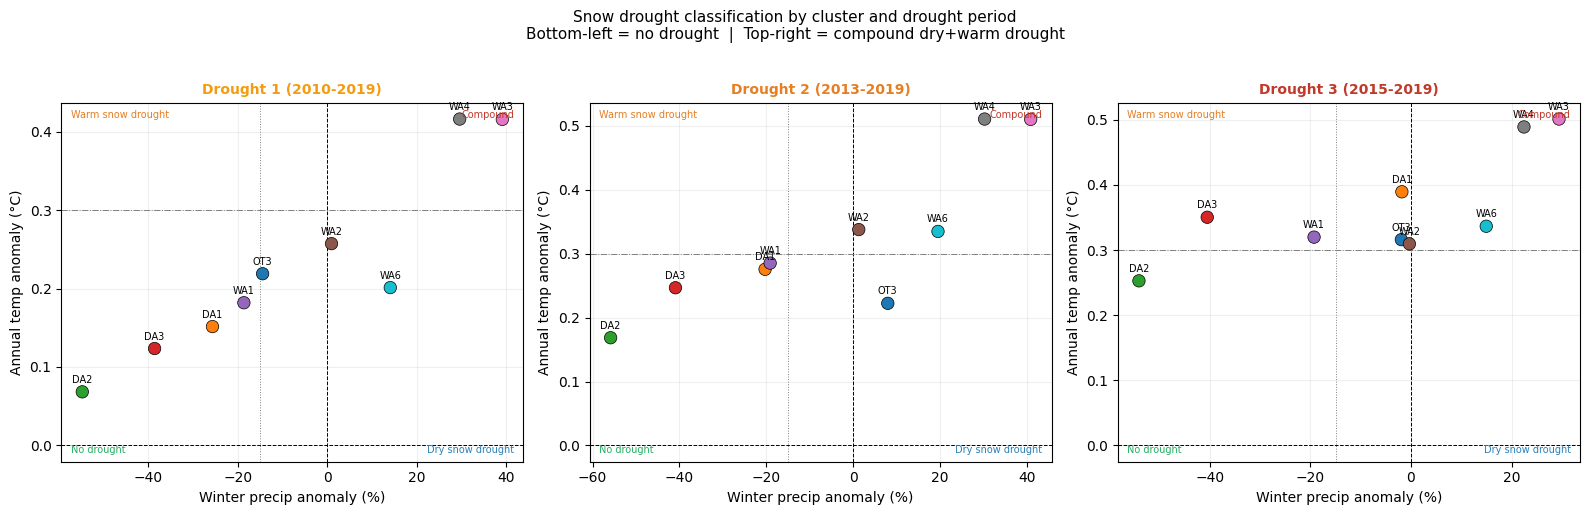

In [ ]:
# ── Cell 3: Snow drought diagnosis ────────────────────────────────────────

print('Snow drought diagnosis by cluster and period:')
print()
print(f'{"Cluster":6s} {"Period":25s} {"Win precip anom%":17s} '
      f'{"Ann temp anom°C":16s} {"Drought type"}')
print('-' * 80)

snow_drought_records = []
for cl in CLUSTERS:
    cl_df = df_clim[df_clim['cluster'] == cl]
    if len(cl_df) == 0:
        continue
    for period_label, years in list(DROUGHT_DEFS.items())[1:]:
        period_df    = cl_df[cl_df['year'].isin(years)]
        win_anom_pct = period_df['precip_win_anom_pct'].mean()
        temp_anom    = period_df['tmean_anom'].mean()

        if win_anom_pct < -15 and temp_anom > 0.3:
            dtype = 'Compound (dry + warm)'
        elif win_anom_pct < -15:
            dtype = 'Dry snow drought'
        elif temp_anom > 0.3:
            dtype = 'Warm snow drought'
        else:
            dtype = 'Mild / no snow drought'

        print(f'{cl:6s} {period_label:25s} {win_anom_pct:+.1f}%'
              f'{"":10s} {temp_anom:+.2f}°C{"":9s} {dtype}')

        snow_drought_records.append({
            'cluster':       cl,
            'period':        period_label,
            'win_prec_anom': win_anom_pct,
            'temp_anom':     temp_anom,
            'dtype':         dtype,
        })
    print()

df_snow_drought = pd.DataFrame(snow_drought_records)

# ── Figure ────────────────────────────────────────────────────────────────
drought_period_labels = list(DROUGHT_DEFS.keys())[1:]   # just the 3 drought periods
fig, axes = plt.subplots(1, 3, figsize=(16, 5))          # 3 panels, one per period

for ax, period_label in zip(axes, drought_period_labels):
    period_df = df_snow_drought[df_snow_drought['period'] == period_label]

    sc = ax.scatter(
        period_df['win_prec_anom'],
        period_df['temp_anom'],
        c=[list(CLUSTERS).index(cl) for cl in period_df['cluster']],
        cmap='tab10', vmin=0, vmax=9,
        s=80, edgecolors='k', lw=0.5, zorder=3)

    for _, row in period_df.iterrows():
        ax.annotate(row['cluster'],
                    (row['win_prec_anom'], row['temp_anom']),
                    fontsize=7, ha='center', va='bottom',
                    xytext=(0, 5), textcoords='offset points')

    ax.axvline(0,   color='k',    lw=0.7, ls='--')
    ax.axhline(0,   color='k',    lw=0.7, ls='--')
    ax.axvline(-15, color='grey', lw=0.7, ls=':')
    ax.axhline(0.3, color='grey', lw=0.7, ls='-.')

    ax.text(0.02, 0.98, 'Warm snow drought',
            transform=ax.transAxes, fontsize=7, va='top', color='#e67e22')
    ax.text(0.02, 0.02, 'No drought',
            transform=ax.transAxes, fontsize=7, va='bottom', color='#27ae60')
    ax.text(0.98, 0.98, 'Compound',
            transform=ax.transAxes, fontsize=7, va='top', ha='right',
            color='#c0392b')
    ax.text(0.98, 0.02, 'Dry snow drought',
            transform=ax.transAxes, fontsize=7, va='bottom', ha='right',
            color='#2980b9')

    ax.set_xlabel('Winter precip anomaly (%)', fontsize=10)
    ax.set_ylabel('Annual temp anomaly (°C)', fontsize=10)
    ax.set_title(period_label, fontsize=10, fontweight='bold',
                 color=DROUGHT_COLORS[period_label])
    ax.grid(True, alpha=0.2)

fig.suptitle(
    'Snow drought classification by cluster and drought period\n'
    'Bottom-left = no drought  |  Top-right = compound dry+warm drought',
    fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{DROUGHT_DIR}/snow_drought_classification.png',
            dpi=150, bbox_inches='tight')
plt.show()

## note to self - im concerned that we're just diagnosing snow drought from temp anomaly and not temp above 0°C threshold... come back 

Loading OGGM snowfall on glacier for all clusters...
Snowfall records: 600
cluster           DA1           DA2           DA3           OT3           WA1           WA2           WA3           WA4           WA5           WA6
dataset                                                                                                                                            
CR2MET   5.409404e+10  1.695663e+11  4.530484e+11  6.282055e+09  6.160755e+11  3.405598e+12  2.012800e+13  8.790340e+12  5.615387e+12  7.244005e+12
CRU      6.116825e+10  1.329990e+11  2.155924e+11  2.951489e+09  3.171656e+11  1.302458e+12  5.317023e+12  3.167723e+12  1.893140e+12  3.058167e+12
ERA5     8.794547e+10  2.338683e+11  5.138889e+11  9.610870e+09  5.408434e+11  4.147720e+12  4.006055e+13  1.475876e+13  1.104128e+13  1.101523e+13

Snow drought classification — Harpold et al. (2017) framework
SWE proxy = OGGM snowfall_on_glacier_monthly (kg, summed annually)

Cluster Dataset  Period                    Snow anom% 

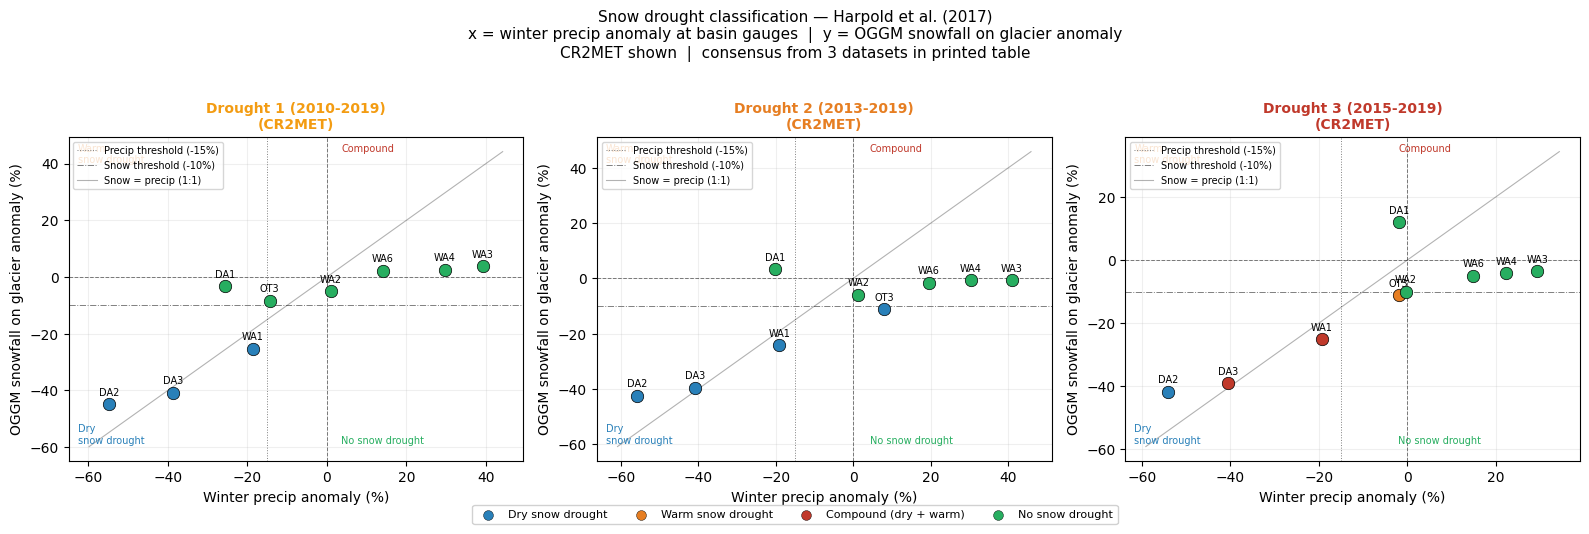

In [4]:
## diff cell 3 snow drought approach 
# ── Cell III revised: Snow drought classification using OGGM ──────────────
# Instead of winter precip × snow fraction (basin-average proxy),
# use OGGM's snowfall_on_glacier_monthly — actual simulated solid
# precipitation at glacier locations, varying year to year with
# temperature. This is physically more meaningful because:
# 1. It's at glacier elevation not gauge elevation
# 2. It varies with temperature so warm years naturally show less snow
# 3. It's already what OGGM uses internally to compute mass balance

print('Loading OGGM snowfall on glacier for all clusters...')

import xarray as xr

snowfall_records = []

for ds_name in ['CR2MET', 'ERA5', 'CRU']:
    tag = DATASETS[ds_name]
    for cl in CLUSTERS:
        path = nc_path(ds_name, cl)
        if not os.path.exists(path):
            continue
        try:
            ds = xr.open_dataset(path)
            # snowfall_on_glacier_monthly shape: (time, month, glacier)
            # time=0 is spinup year 1999, time=1 is 2000 etc.
            if 'snowfall_on_glacier_monthly' not in ds:
                continue

            snow = ds['snowfall_on_glacier_monthly'].values
            # Sum over glaciers (axis=-1), sum over months (axis=1)
            # to get annual snowfall per year
            # Shape: (n_years, 12, n_glaciers)
            annual_snow = np.nansum(
                np.nansum(snow, axis=1), axis=-1)   # (n_years,)

            # Skip spinup year (index 0 = 1999)
            for i, year in enumerate(range(2000, 2020)):
                snowfall_records.append({
                    'dataset': ds_name,
                    'cluster': cl,
                    'year':    year,
                    'snowfall_kg': annual_snow[i + YEAR_OFFSET],
                })
            ds.close()
        except Exception as e:
            print(f'  Error {ds_name} {cl}: {e}')

df_snowfall = pd.DataFrame(snowfall_records)
print(f'Snowfall records: {len(df_snowfall):,}')
print(df_snowfall.groupby(['dataset','cluster'])['snowfall_kg']
      .mean().unstack().round(0).to_string())

# ── Classification using OGGM snowfall ───────────────────────────────────
print('\nSnow drought classification — Harpold et al. (2017) framework')
print('SWE proxy = OGGM snowfall_on_glacier_monthly (kg, summed annually)')
print()
print(f'{"Cluster":6s} {"Dataset":8s} {"Period":25s} '
      f'{"Snow anom%":11s} {"P anom%":8s} '
      f'{"T anom°C":9s} {"Classification"}')
print('-' * 90)

snow_drought_records = []

for ds_name in ['CR2MET', 'ERA5', 'CRU']:
    for cl in CLUSTERS:
        cl_snow = df_snowfall[
            (df_snowfall['dataset'] == ds_name) &
            (df_snowfall['cluster'] == cl)]
        if len(cl_snow) == 0:
            continue

        cl_clim = df_clim[df_clim['cluster'] == cl]
        snow_ts  = cl_snow.set_index('year')['snowfall_kg']
        snow_base = snow_ts[snow_ts.index.isin(BASELINE)].mean()

        for period_label, years in list(DROUGHT_DEFS.items())[1:]:
            snow_drought = snow_ts[snow_ts.index.isin(years)].mean()
            snow_anom    = ((snow_drought - snow_base) /
                             snow_base * 100
                             if snow_base > 0 else np.nan)

            winp_anom = (cl_clim[cl_clim['year'].isin(years)]
                         ['precip_win_anom_pct'].mean())
            temp_anom = (cl_clim[cl_clim['year'].isin(years)]
                         ['tmean_anom'].mean())

            # Harpold et al. classification
            # Snow must be below normal for any snow drought
            snow_below  = snow_anom < -10
            prec_below  = winp_anom < -15
            temp_warm   = temp_anom  > +0.3

            if not snow_below:
                dtype = 'No snow drought'
            elif prec_below and temp_warm:
                dtype = 'Compound (dry + warm)'
            elif prec_below:
                dtype = 'Dry snow drought'
            elif temp_warm:
                dtype = 'Warm snow drought'
            else:
                dtype = 'Dry snow drought'

            print(f'{cl:6s} {ds_name:8s} {period_label:25s} '
                  f'{snow_anom:+11.1f}% '
                  f'{winp_anom:+8.1f}% '
                  f'{temp_anom:+9.2f}°C '
                  f'{dtype}')

            snow_drought_records.append({
                'cluster':    cl,
                'dataset':    ds_name,
                'period':     period_label,
                'snow_anom':  snow_anom,
                'winp_anom':  winp_anom,
                'temp_anom':  temp_anom,
                'dtype':      dtype,
            })
        print()

df_snow_drought = pd.DataFrame(snow_drought_records)

# Multi-dataset consensus classification
print('\nConsensus classification (majority vote across 3 datasets):')
print(f'{"Cluster":6s} {"Period":25s} {"Consensus"}')
print('-' * 55)
for cl in CLUSTERS:
    for period_label in list(DROUGHT_DEFS.keys())[1:]:
        sub = df_snow_drought[
            (df_snow_drought['cluster'] == cl) &
            (df_snow_drought['period']  == period_label)]
        if len(sub) == 0:
            continue
        votes = sub['dtype'].value_counts()
        consensus = votes.index[0]
        n_agree   = votes.iloc[0]
        print(f'{cl:6s} {period_label:25s} '
              f'{consensus} ({n_agree}/3 datasets)')

# ── Figure ────────────────────────────────────────────────────────────────
dtype_colors = {
    'Dry snow drought':        '#2980b9',
    'Warm snow drought':       '#e67e22',
    'Compound (dry + warm)':   '#c0392b',
    'No snow drought':         '#27ae60',
}

drought_period_labels = list(DROUGHT_DEFS.keys())[1:]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, period_label in zip(axes, drought_period_labels):
    # Use CR2MET for the figure — most physically reliable
    period_df = df_snow_drought[
        (df_snow_drought['period']  == period_label) &
        (df_snow_drought['dataset'] == 'CR2MET')].copy()

    for _, row in period_df.iterrows():
        color = dtype_colors.get(row['dtype'], '#888888')
        ax.scatter(row['winp_anom'], row['snow_anom'],
                   c=color, s=80, edgecolors='k',
                   lw=0.5, zorder=3)
        ax.annotate(row['cluster'],
                    (row['winp_anom'], row['snow_anom']),
                    fontsize=7, ha='center', va='bottom',
                    xytext=(0, 5), textcoords='offset points')

    ax.axvline(0,   color='k',    lw=0.7, ls='--', alpha=0.5)
    ax.axhline(0,   color='k',    lw=0.7, ls='--', alpha=0.5)
    ax.axvline(-15, color='grey', lw=0.7, ls=':',
               label='Precip threshold (-15%)')
    ax.axhline(-10, color='grey', lw=0.7, ls='-.',
               label='Snow threshold (-10%)')

    # 1:1 line — if snow anomaly = precip anomaly,
    # all precip change is in snowfall (no rain/snow shift)
    lim = [min(period_df['winp_anom'].min(),
                period_df['snow_anom'].min()) - 5,
            max(period_df['winp_anom'].max(),
                period_df['snow_anom'].max()) + 5]
    ax.plot(lim, lim, 'k-', lw=0.8, alpha=0.3,
            label='Snow = precip (1:1)')

    ax.text(0.02, 0.98, 'Warm\nsnow drought',
            transform=ax.transAxes, fontsize=7,
            va='top', color='#e67e22')
    ax.text(0.60, 0.05, 'No snow drought',
            transform=ax.transAxes, fontsize=7,
            va='bottom', color='#27ae60')
    ax.text(0.02, 0.05, 'Dry\nsnow drought',
            transform=ax.transAxes, fontsize=7,
            va='bottom', color='#2980b9')
    ax.text(0.60, 0.98, 'Compound',
            transform=ax.transAxes, fontsize=7,
            va='top', color='#c0392b')

    ax.set_xlabel('Winter precip anomaly (%)', fontsize=10)
    ax.set_ylabel('OGGM snowfall on glacier anomaly (%)', fontsize=10)
    ax.set_title(f'{period_label}\n(CR2MET)',
                 fontsize=10, fontweight='bold',
                 color=DROUGHT_COLORS[period_label])
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.2)

fig.legend(
    handles=[
        plt.scatter([],[], c=v, s=50, label=k,
                    edgecolors='k', lw=0.3)
        for k, v in dtype_colors.items()],
    loc='lower center', ncol=4, fontsize=8,
    bbox_to_anchor=(0.5, -0.02), framealpha=0.9)

fig.suptitle(
    'Snow drought classification — Harpold et al. (2017)\n'
    'x = winter precip anomaly at basin gauges  '
    '|  y = OGGM snowfall on glacier anomaly\n'
    'CR2MET shown  |  consensus from 3 datasets in printed table',
    fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{DROUGHT_DIR}/snow_drought_harpold_oggm_snowfall.png',
            dpi=150, bbox_inches='tight')
plt.show()

## IV. Glacier melt during drought — absolute and relative changes

For each basin and drought period, we compute:
1. Mean annual glacier runoff (km³/yr) — did melt increase or decrease?
2. Mean annual observed Q (km³/yr) — how much did streamflow decline?
3. Mean glacier fraction (%) — did relative importance increase?
4. Drought amplification factor = drought fraction / baseline fraction

We do this for all three datasets and report the multi-dataset mean.


In [ ]:
# ── Compute period means per basin ────────────────────────────────────────
print('Computing period means for all basins...')

period_records = []

for gauge_id, info in GAUGE_INFO_FRAC.items():
    cy = info['complete_years']

    for ds_name in ['CR2MET', 'ERA5', 'CRU']:
        res = RESULTS[ds_name].get(gauge_id)
        if res is None:
            continue
        m = res['monthly']

        for period_label, years in DROUGHT_DEFS.items():
            valid_years = [y for y in years if y in cy]
            if len(valid_years) < 2:
                continue

            period_m = m[m['year'].isin(valid_years)]
            ann = period_m.groupby('year').agg(
                glac_m3=('glacier_runoff_m3', 'sum'),
                q_m3   =('q_m3_mon',          'sum'),
                melt_m3=('melt_on_glacier_m3', 'sum'),
                liq_m3 =('liq_prcp_on_glacier_m3', 'sum'),
            )
            ann = ann[ann['q_m3'] > 0]
            if len(ann) == 0:
                continue

            period_records.append({
                'gauge_id':        gauge_id,
                'gauge_name':      info['gauge_name'][:35],
                'lat':             info['cen_lat'],
                'cluster':         info['clusters'][0],
                'glacier_area_km2': info['glacier_area_km2'],
                'basin_area_km2':  info['basin_area_km2'],
                'dataset':         ds_name,
                'period':          period_label,
                'n_years':         len(ann),
                'glac_km3yr':      ann['glac_m3'].mean() / 1e9,
                'q_km3yr':         ann['q_m3'].mean()    / 1e9,
                'melt_km3yr':      ann['melt_m3'].mean() / 1e9,
                'liq_km3yr':       ann['liq_m3'].mean()  / 1e9,
                'frac_mean':       (ann['glac_m3'] / ann['q_m3']).mean(),
            })

df_periods = pd.DataFrame(period_records)
print(f'Period records: {len(df_periods):,}')

# ── Compute amplification factor: drought frac / baseline frac ────────────
baseline_fracs = (df_periods[df_periods['period'] == 'Baseline (2000-2009)']
                  [['gauge_id','dataset','frac_mean','glac_km3yr','q_km3yr']]
                  .rename(columns={'frac_mean':   'frac_base',
                                   'glac_km3yr':  'glac_base',
                                   'q_km3yr':     'q_base'}))

df_periods = df_periods.merge(baseline_fracs,
                               on=['gauge_id','dataset'], how='left')
df_periods['amp_factor']  = (df_periods['frac_mean'] /
                              df_periods['frac_base'])
df_periods['glac_chg_pct'] = ((df_periods['glac_km3yr'] -
                                df_periods['glac_base']) /
                               df_periods['glac_base'] * 100)
df_periods['q_chg_pct']    = ((df_periods['q_km3yr'] -
                                df_periods['q_base']) /
                               df_periods['q_base'] * 100)

# ── Summary table by cluster and period ───────────────────────────────────
print()
print('Multi-dataset mean: drought amplification factor by cluster')
print('(glacier fraction during drought / glacier fraction during baseline)')
print()
print(f'{"Cluster":6s}', end='')
for period_label in list(DROUGHT_DEFS.keys())[1:]:
    print(f'  {period_label:22s}', end='')
print()
print('-' * 85)

for cl in CLUSTERS:
    print(f'{cl:6s}', end='')
    for period_label in list(DROUGHT_DEFS.keys())[1:]:
        sub = df_periods[
            (df_periods['cluster'] == cl) &
            (df_periods['period']  == period_label) &
            (df_periods['amp_factor'].notna()) &
            (df_periods['amp_factor'] < 10)   # exclude implausible
        ]
        if len(sub) == 0:
            print(f'  {"n/a":22s}', end='')
        else:
            amp = sub['amp_factor'].median()
            print(f'  {amp:.2f}x{" "*19}', end='')
    print()

# ── Also print Q and glacier melt changes ─────────────────────────────────
print()
print('Q change % vs baseline (multi-dataset median):')
print(f'{"Cluster":6s}', end='')
for period_label in list(DROUGHT_DEFS.keys())[1:]:
    print(f'  {period_label:22s}', end='')
print()
print('-' * 85)
for cl in CLUSTERS:
    print(f'{cl:6s}', end='')
    for period_label in list(DROUGHT_DEFS.keys())[1:]:
        sub = df_periods[
            (df_periods['cluster'] == cl) &
            (df_periods['period']  == period_label)]
        if len(sub) == 0:
            print(f'  {"n/a":22s}', end='')
        else:
            chg = sub['q_chg_pct'].median()
            print(f'  {chg:+.1f}%{" "*18}', end='')
    print()

print()
print('Glacier melt change % vs baseline (multi-dataset median):')
print(f'{"Cluster":6s}', end='')
for period_label in list(DROUGHT_DEFS.keys())[1:]:
    print(f'  {period_label:22s}', end='')
print()
print('-' * 85)
for cl in CLUSTERS:
    print(f'{cl:6s}', end='')
    for period_label in list(DROUGHT_DEFS.keys())[1:]:
        sub = df_periods[
            (df_periods['cluster'] == cl) &
            (df_periods['period']  == period_label)]
        if len(sub) == 0:
            print(f'  {"n/a":22s}', end='')
        else:
            chg = sub['glac_chg_pct'].median()
            print(f'  {chg:+.1f}%{" "*18}', end='')
    print()


Computing period means for all basins...
Period records: 1,578

Multi-dataset mean: drought amplification factor by cluster
(glacier fraction during drought / glacier fraction during baseline)

Cluster  Drought 1 (2010-2019)   Drought 2 (2013-2019)   Drought 3 (2015-2019) 
-------------------------------------------------------------------------------------
OT3     1.84x                     1.44x                     1.55x                   
DA1     2.67x                     2.34x                     1.50x                   
DA2     2.82x                     2.86x                     3.70x                   
DA3     1.90x                     1.95x                     2.14x                   
WA1     1.58x                     1.66x                     1.84x                   
WA2     1.22x                     1.28x                     1.39x                   
WA3     1.07x                     1.12x                     1.17x                   
WA4     1.00x                     1.04x      

## V. Decomposing the drought amplification signal

The increase in glacier fraction during drought can be driven by:
1. **Q decline** — streamflow falls while glacier melt stays the same
2. **Melt increase** — glacier melt increases due to higher temperatures
3. **Both** — Q declines AND melt increases

We quantify the relative contribution of each mechanism following the
approach used in the WA1 analysis, extended to all clusters and all
three drought periods.


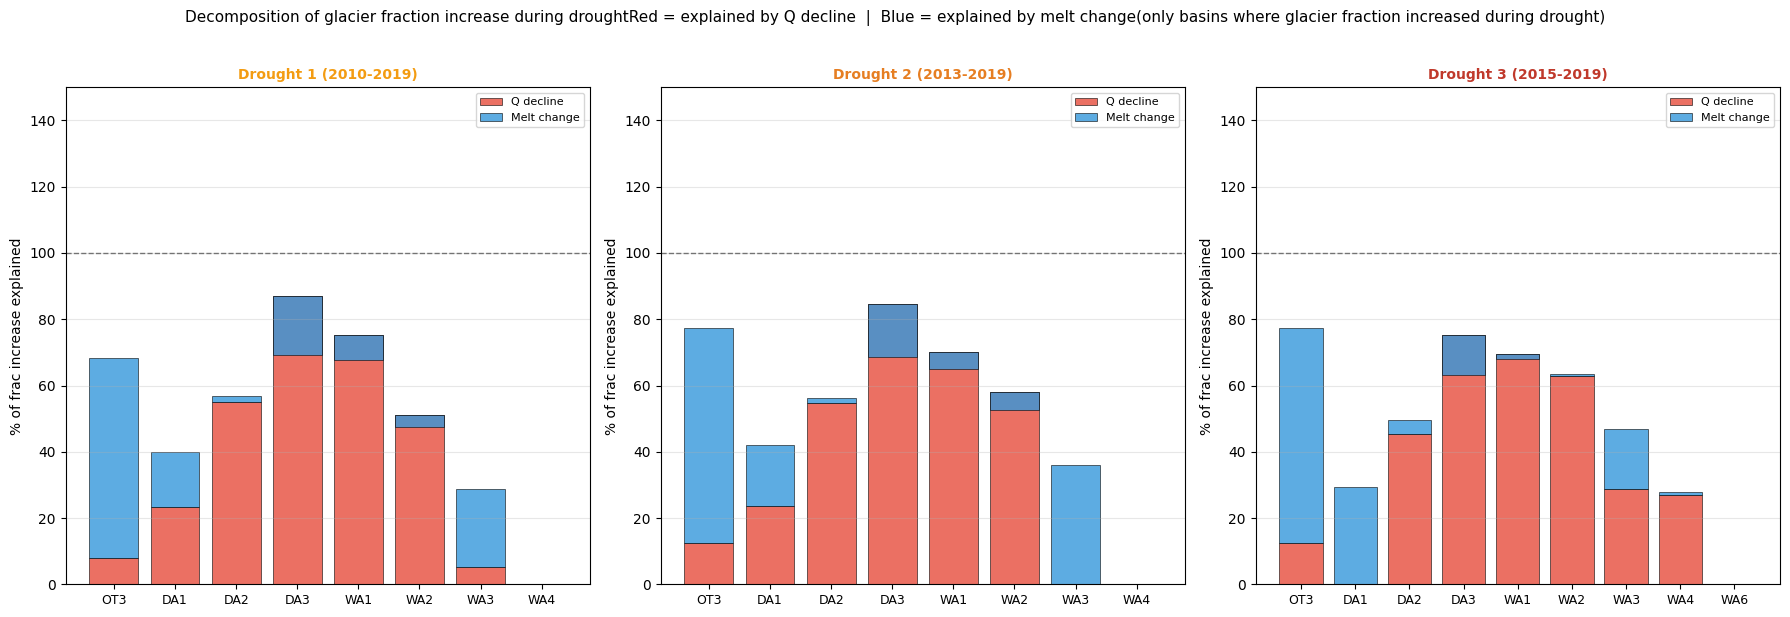

Median decomposition across all basins (amplifying basins only):
Period                     Q decline %   Melt change %
-------------------------------------------------------
Drought 1 (2010-2019)      +57.6%          -3.1%
Drought 2 (2013-2019)      +56.1%          -2.1%
Drought 3 (2015-2019)      +57.4%          -0.5%


In [ ]:
# ── Decompose amplification into Q-decline vs melt-increase ──────────────
# Counterfactual approach:
# If frac = glac/Q, then the change in frac can be decomposed:
# Hold Q constant at baseline -> frac_cf_q = glac_drought / q_base
# Hold glac constant at baseline -> frac_cf_glac = glac_base / q_drought
# Actual frac_drought = glac_drought / q_drought

# % of amplification explained by Q decline:
# (frac_cf_q - frac_base) / (frac_drought - frac_base)

decomp_records = []
for gauge_id in GAUGE_INFO_FRAC:
    for ds_name in ['CR2MET', 'ERA5', 'CRU']:
        base_row = df_periods[
            (df_periods['gauge_id'] == gauge_id) &
            (df_periods['dataset']  == ds_name) &
            (df_periods['period']   == 'Baseline (2000-2009)')
        ]
        if len(base_row) == 0:
            continue
        frac_base = base_row['frac_mean'].values[0]
        glac_base = base_row['glac_km3yr'].values[0]
        q_base    = base_row['q_km3yr'].values[0]

        for period_label in list(DROUGHT_DEFS.keys())[1:]:
            dr_row = df_periods[
                (df_periods['gauge_id'] == gauge_id) &
                (df_periods['dataset']  == ds_name) &
                (df_periods['period']   == period_label)
            ]
            if len(dr_row) == 0:
                continue
            frac_dr = dr_row['frac_mean'].values[0]
            glac_dr = dr_row['glac_km3yr'].values[0]
            q_dr    = dr_row['q_km3yr'].values[0]

            delta = frac_dr - frac_base
            if abs(delta) < 1e-10 or q_base == 0:
                continue

            # Counterfactual fractions
            frac_cf_q    = glac_dr   / q_base    # melt changes, Q fixed
            frac_cf_glac = glac_base / q_dr      # Q changes, melt fixed

            pct_q_decline   = (frac_cf_glac - frac_base) / delta * 100
            pct_melt_change = (frac_cf_q    - frac_base) / delta * 100

            decomp_records.append({
                'gauge_id':       gauge_id,
                'cluster':        GAUGE_INFO_FRAC[gauge_id]['clusters'][0],
                'lat':            GAUGE_INFO_FRAC[gauge_id]['cen_lat'],
                'dataset':        ds_name,
                'period':         period_label,
                'frac_base':      frac_base,
                'frac_drought':   frac_dr,
                'delta_frac':     delta,
                'pct_q_decline':  np.clip(pct_q_decline,   -200, 200),
                'pct_melt_chg':   np.clip(pct_melt_change, -200, 200),
            })

df_decomp = pd.DataFrame(decomp_records)

# ── Figure: stacked bar of Q-decline vs melt-change contribution ──────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, period_label in zip(axes, list(DROUGHT_DEFS.keys())[1:]):
    period_df = df_decomp[df_decomp['period'] == period_label]

    cl_q_med    = []
    cl_melt_med = []
    cl_labels   = []

    for cl in CLUSTERS:
        sub = period_df[
            (period_df['cluster'] == cl) &
            (period_df['delta_frac'] > 0)   # only amplifying basins
        ]
        if len(sub) < 3:
            continue
        cl_q_med.append(sub['pct_q_decline'].median())
        cl_melt_med.append(sub['pct_melt_chg'].median())
        cl_labels.append(cl)

    x = np.arange(len(cl_labels))
    ax.bar(x, cl_q_med,    label='Q decline',
           color='#e74c3c', alpha=0.8, edgecolor='k', lw=0.5)
    ax.bar(x, cl_melt_med, bottom=cl_q_med,
           label='Melt change', color='#3498db',
           alpha=0.8, edgecolor='k', lw=0.5)
    ax.axhline(100, color='k', lw=1, ls='--', alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(cl_labels, fontsize=9)
    ax.set_ylabel('% of frac increase explained', fontsize=10)
    ax.set_title(period_label, fontsize=10, fontweight='bold',
                 color=DROUGHT_COLORS[period_label])
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 150)

fig.suptitle(
    'Decomposition of glacier fraction increase during drought'
    'Red = explained by Q decline  |  Blue = explained by melt change'
    '(only basins where glacier fraction increased during drought)',
    fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{DROUGHT_DIR}/drought_amplification_decomposition.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print summary
print('Median decomposition across all basins (amplifying basins only):')
print(f'{"Period":25s}  {"Q decline %":12s}  {"Melt change %"}')
print('-' * 55)
for period_label in list(DROUGHT_DEFS.keys())[1:]:
    sub = df_decomp[
        (df_decomp['period']     == period_label) &
        (df_decomp['delta_frac'] > 0)]
    print(f'{period_label:25s}  '
          f'{sub["pct_q_decline"].median():+.1f}%{"":8s}  '
          f'{sub["pct_melt_chg"].median():+.1f}%')


## VI. Climate driver analysis

What drove the drought? We compare temperature, precipitation, and PET
anomalies during each drought period vs baseline, to assess whether the
amplified glacier contribution reflects:
- Lower precipitation (less competing water)
- Higher temperatures (more melt + less snow)
- Higher PET (more evaporative demand reducing Q)
- Or some combination


Climate driver summary by cluster and period:



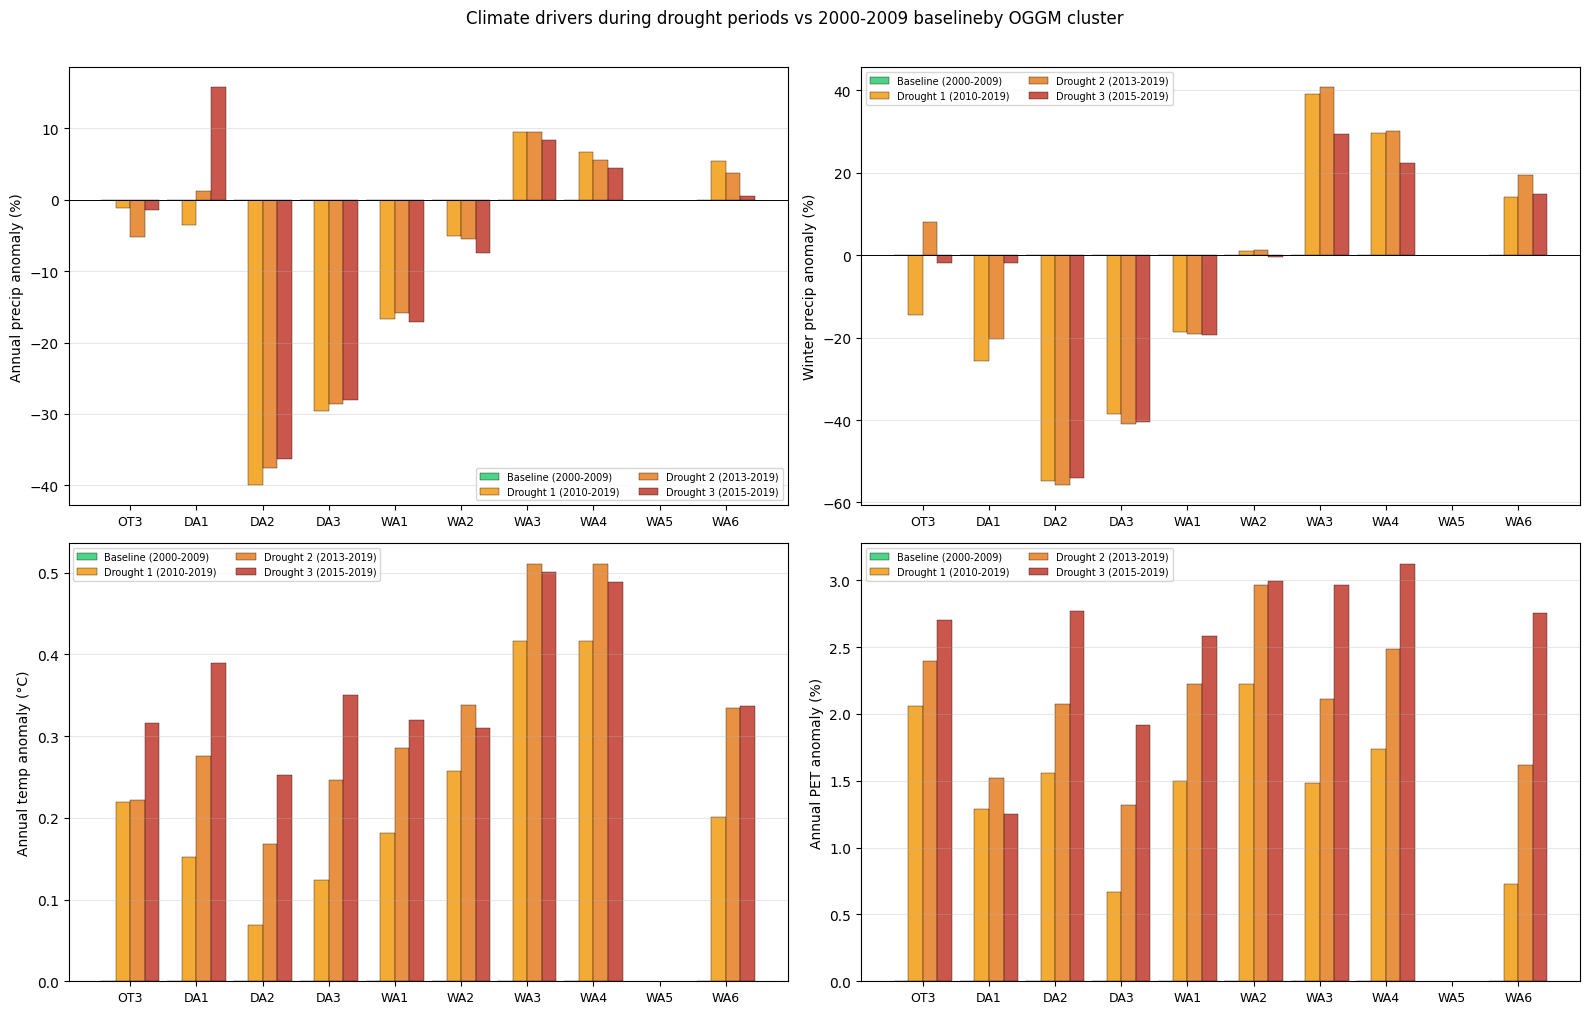

In [ ]:
# ── PET and temperature anomalies during drought periods ─────────────────
print('Climate driver summary by cluster and period:')
print()

driver_records = []
for cl in CLUSTERS:
    cl_df = df_clim[df_clim['cluster'] == cl].set_index('year')
    for period_label, years in DROUGHT_DEFS.items():
        period_df = cl_df[cl_df.index.isin(years)]
        driver_records.append({
            'cluster':          cl,
            'period':           period_label,
            'precip_ann':       period_df['precip_ann'].mean(),
            'precip_ann_anom':  period_df['precip_ann_anom_pct'].mean(),
            'precip_win_anom':  period_df['precip_win_anom_pct'].mean(),
            'tmean_anom':       period_df['tmean_anom'].mean(),
            'pet_anom_pct':     period_df['pet_anom_pct'].mean(),
        })

df_drivers = pd.DataFrame(driver_records)

# ── Figure: 4-panel driver summary across clusters ────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

driver_vars = [
    ('precip_ann_anom', 'Annual precip anomaly (%)',     True),
    ('precip_win_anom', 'Winter precip anomaly (%)',      True),
    ('tmean_anom',      'Annual temp anomaly (°C)',       False),
    ('pet_anom_pct',    'Annual PET anomaly (%)',         True),
]

x       = np.arange(len(CLUSTERS))
width   = 0.22
offsets = [-1.5*width, -0.5*width, 0.5*width, 1.5*width]

for ax, (var, ylabel, is_pct) in zip(axes.flatten(), driver_vars):
    for i, (period_label, years) in enumerate(list(DROUGHT_DEFS.items())):
        vals = []
        for cl in CLUSTERS:
            sub = df_drivers[
                (df_drivers['cluster'] == cl) &
                (df_drivers['period']  == period_label)]
            vals.append(sub[var].values[0] if len(sub) else np.nan)
        ax.bar(x + offsets[i], vals, width,
               label=period_label,
               color=DROUGHT_COLORS[period_label],
               alpha=0.85, edgecolor='k', lw=0.3)

    ax.axhline(0, color='k', lw=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(CLUSTERS, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(fontsize=7, ncol=2)

fig.suptitle(
    'Climate drivers during drought periods vs 2000-2009 baseline'
    'by OGGM cluster',
    fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{DROUGHT_DIR}/climate_drivers_by_period_cluster.png',
            dpi=150, bbox_inches='tight')
plt.show()


## VII. Chile map — drought amplification factor

Map of glacier fraction amplification factor (drought / baseline) for all
137 gauged basins, for each of the three drought period definitions.
Shows where across Chile the relative importance of glacier melt increased
most strongly during drought.


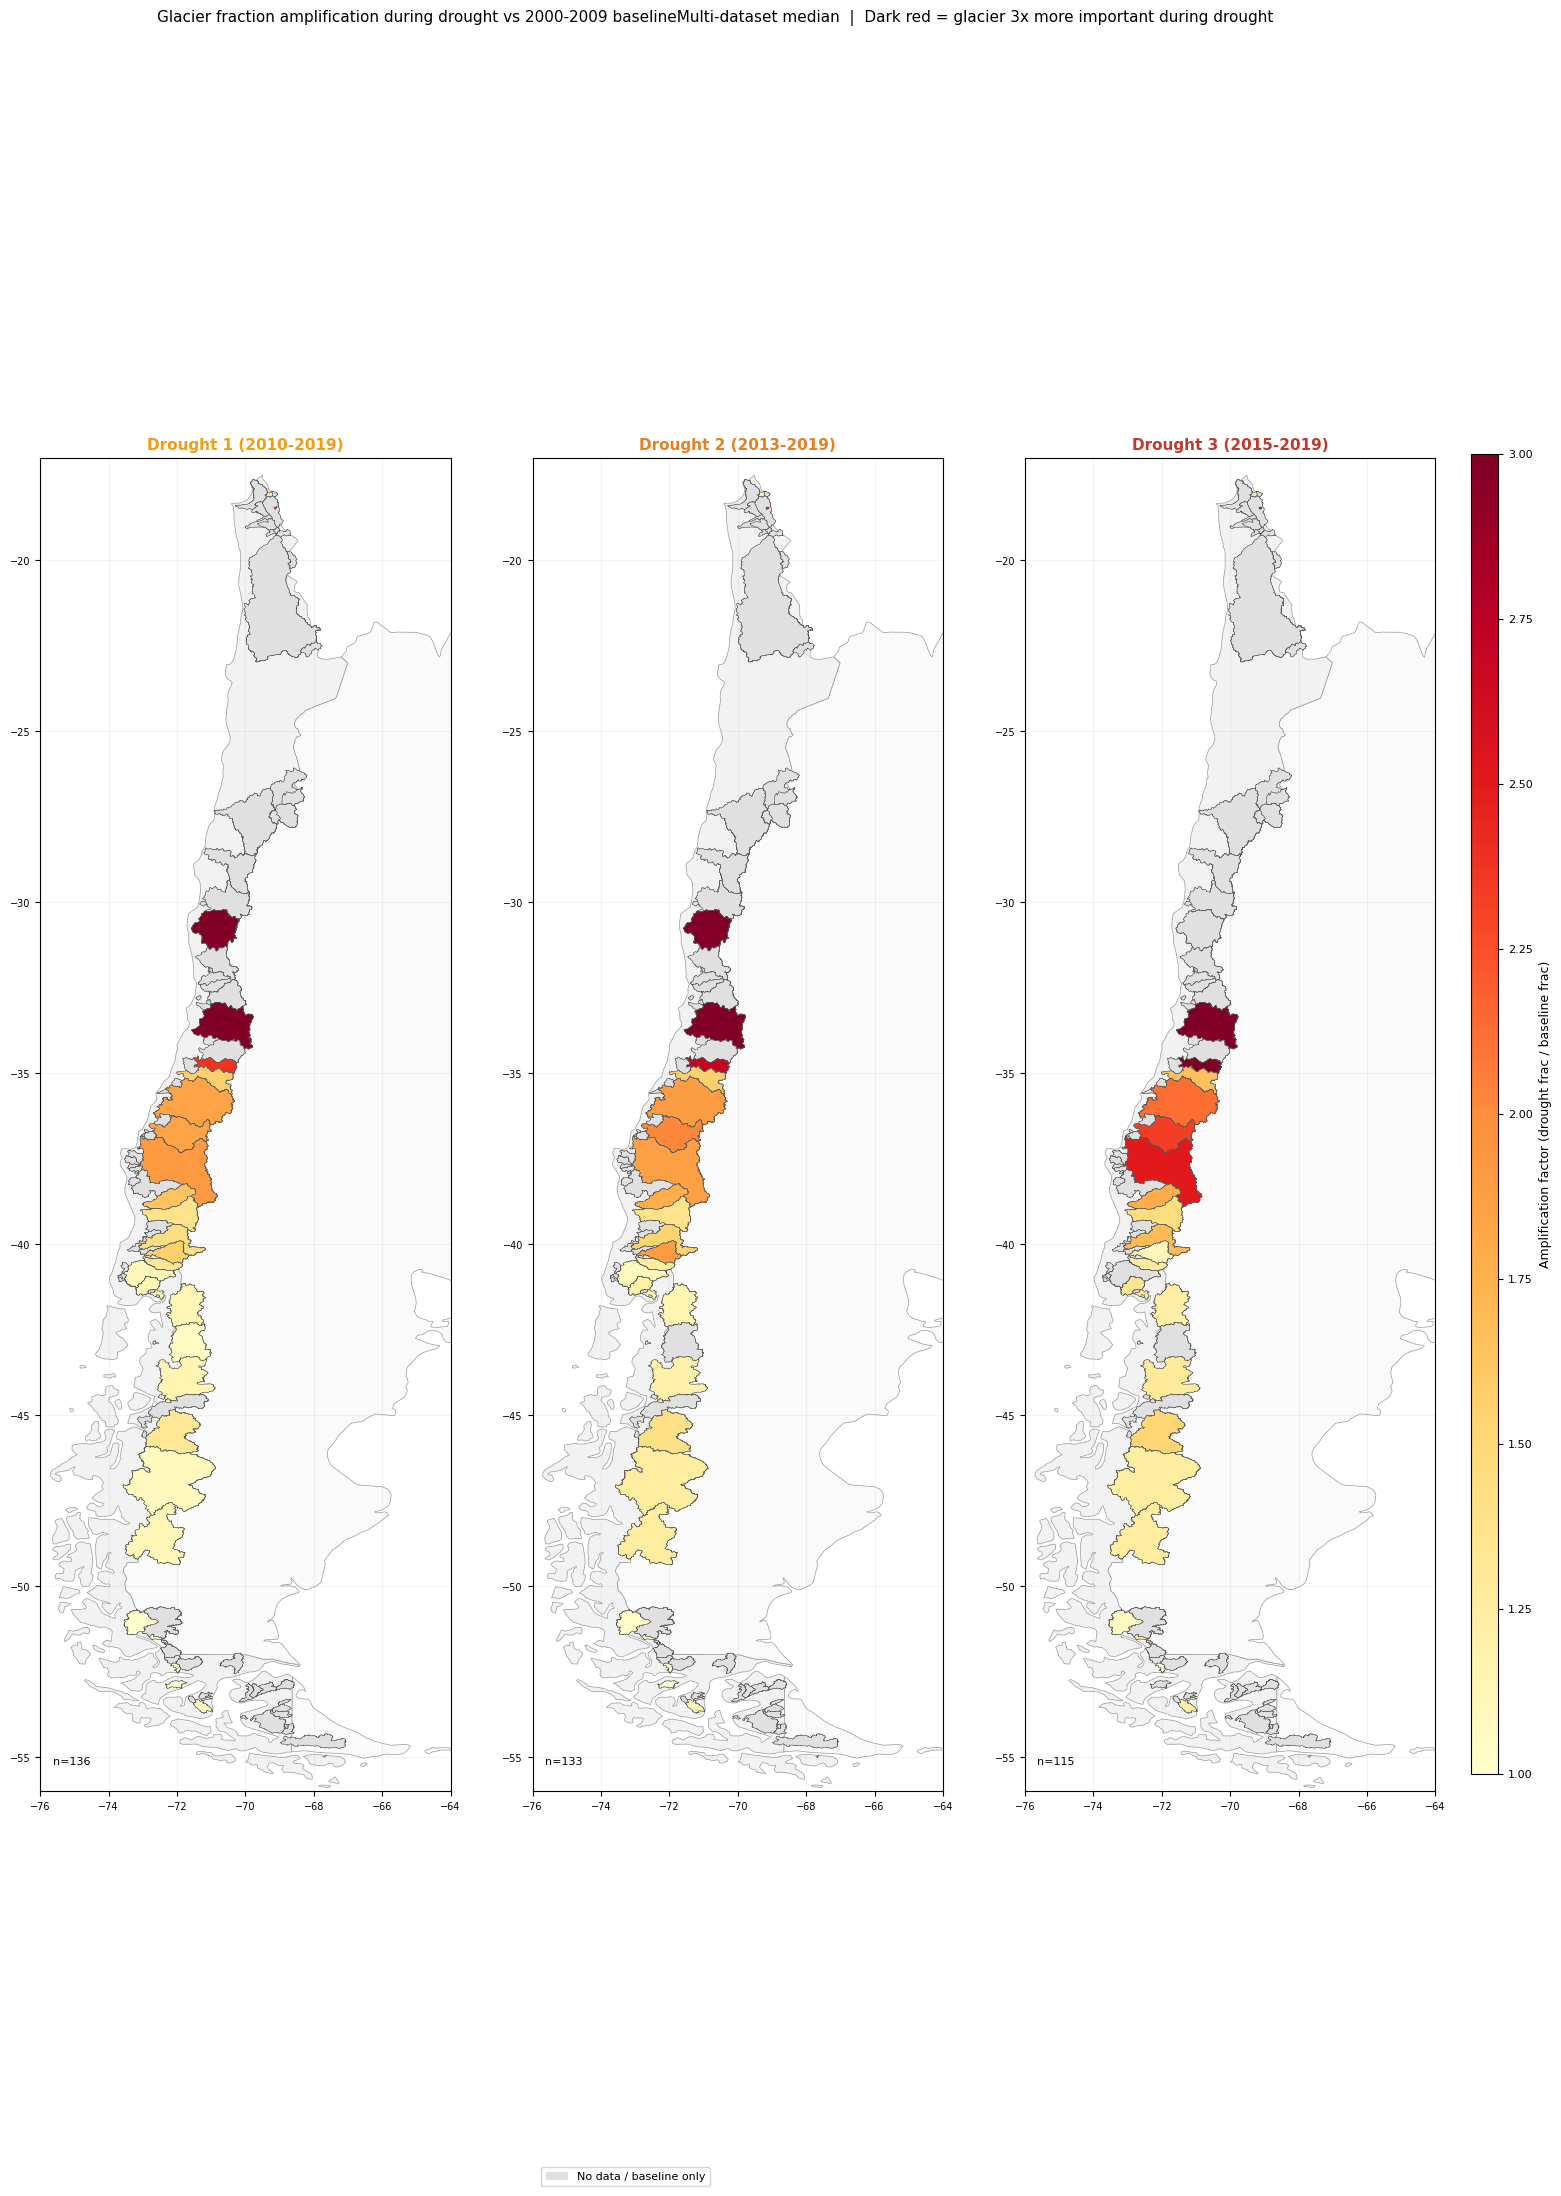

In [ ]:
# ── Load spatial data ─────────────────────────────────────────────────────
bounds = gpd.read_file(BOUNDS_PATH)
bounds['gauge_id'] = bounds['gauge_id'].astype(str)

try:
    world = gpd.read_file(
        'https://naturalearth.s3.amazonaws.com/50m_cultural/'
        'ne_50m_admin_0_countries.zip')
    chile       = world[world['NAME'] == 'Chile']
    arg         = world[world['NAME'] == 'Argentina']
    has_borders = True
except Exception:
    has_borders = False
    print('Country borders unavailable')

# Multi-dataset mean amplification factor per basin per period
amp_mean = (df_periods[df_periods['amp_factor'].between(0, 10)]
            .groupby(['gauge_id','period'])['amp_factor']
            .median().reset_index()
            .rename(columns={'amp_factor': 'amp_med'}))

# ── Plot ──────────────────────────────────────────────────────────────────
drought_periods = list(DROUGHT_DEFS.keys())[1:]
fig, axes = plt.subplots(1, 3, figsize=(18, 22))

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

cmap_amp = plt.cm.YlOrRd
norm_amp = Normalize(vmin=1.0, vmax=3.0)

for ax, period_label in zip(axes, drought_periods):
    if has_borders:
        chile.plot(ax=ax, facecolor='#f2f2f2',
                   edgecolor='#999999', linewidth=0.5, zorder=0)
        arg.plot(ax=ax,   facecolor='#fafafa',
                 edgecolor='#999999', linewidth=0.5, zorder=0)

    # Background grey
    bounds.plot(ax=ax, facecolor='#e0e0e0', edgecolor='#cccccc',
                linewidth=0.2, zorder=1)

    # Merge amp factor
    period_amp = amp_mean[amp_mean['period'] == period_label]
    bounds_plot = bounds.merge(
        period_amp[['gauge_id','amp_med']],
        on='gauge_id', how='left')

    from matplotlib.colors import to_hex
    face_colors = [
        to_hex(cmap_amp(norm_amp(v))) if not np.isnan(v) else '#e0e0e0'
        for v in bounds_plot['amp_med'].values]
    bounds_plot.plot(ax=ax, color=face_colors,
                     edgecolor='#555555', linewidth=0.3, zorder=2)

    ax.set_xlim(-76, -64)
    ax.set_ylim(-56, -17)
    ax.set_aspect('equal')
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.15)
    ax.set_title(period_label, fontsize=11, fontweight='bold',
                 color=DROUGHT_COLORS[period_label])

    n_valid = period_amp['amp_med'].notna().sum()
    ax.text(0.03, 0.02, f'n={n_valid}',
            transform=ax.transAxes, fontsize=8)

# Shared colorbar
sm = ScalarMappable(cmap=cmap_amp, norm=norm_amp)
sm.set_array([])
cbar_ax = fig.add_axes([0.92, 0.2, 0.015, 0.6])
cb = fig.colorbar(sm, cax=cbar_ax)
cb.set_label('Amplification factor (drought frac / baseline frac)',
             fontsize=9)
cb.ax.tick_params(labelsize=8)

fig.legend(
    handles=[
        plt.Rectangle((0,0),1,1, facecolor='#e0e0e0',
                       label='No data / baseline only')],
    loc='lower center', fontsize=8,
    bbox_to_anchor=(0.45, 0.01))

fig.suptitle(
    'Glacier fraction amplification during drought vs 2000-2009 baseline'
    'Multi-dataset median  |  Dark red = glacier 3x more important during drought',
    fontsize=11, y=1.002)
plt.savefig(f'{DROUGHT_DIR}/drought_amplification_map.png',
            dpi=150, bbox_inches='tight')
plt.show()


## VIII. Summary of findings

### What we found

**1. Empirical validation of drought period definitions**

The megadrought was not a Chile-wide phenomenon. Precipitation deficits were
concentrated in central and northern Chile:

- DA2 (Dry Andes Central): -37 to -40% annual precipitation across all three
  periods — the most severely and consistently affected cluster
- DA3 (Dry Andes South): -28 to -30%
- WA1 (Araucanía): -16 to -17%

Patagonia (WA3, WA4, WA6) actually received above-normal precipitation during
the same periods (+5 to +39%), meaning the Chilean Megadrought as defined here
is a central Chile phenomenon, consistent with Garreaud et al. (2020).

The three drought period definitions (2010-2019, 2013-2019, 2015-2019) do not
represent uniformly progressive severity — the pattern depends strongly on
cluster. DA2 shows consistent severity across all three periods. DA1 shows
declining severity in 2015-2019 as conditions shifted from dry to warm drought.
WA1 shows slightly increasing severity in the most recent period.

**2. Snow drought classification**

Two distinct drought mechanisms operated across Chile's latitudinal gradient:

- **Dry snow drought** (DA1, DA2, DA3, WA1): large winter precipitation deficits
  (-19 to -55%) with modest warming. In high snow-fraction clusters (DA1: 0.53,
  DA2: 0.69), this directly reduced snowpack. In WA1 (snow fraction: 0.035),
  the winter deficit was primarily a rainfall deficit since almost no
  precipitation falls as snow at gauge elevations.

- **Warm snow drought** (WA2, WA3, WA4, WA6): winter precipitation was near-
  normal or above-normal, but temperatures increased by +0.3 to +0.5°C.
  Patagonia received 14-41% more winter precipitation than baseline while
  warming, potentially shifting precipitation from snow to rain at elevation
  and reducing snowpack despite higher total precipitation. This is a genuine
  warm snow drought signal, though the absolute snowpack impact is limited
  given the low climatological snow fractions in these clusters (0.10-0.11).

DA3 and WA1 transitioned from dry snow drought (2010-2019) to compound drought
(dry + warm) by 2015-2019 as temperature anomalies crossed the +0.3°C threshold.

**3. Glacier fraction amplification**

Glacier runoff fractions amplified substantially in drought-affected clusters:

- DA2: 2.8-3.7x the baseline fraction — the strongest amplification signal
- DA1: 1.5-2.7x (stronger in earlier periods, weaker in 2015-2019 when the
  drought mechanism shifted from dry to warm)
- DA3: 1.9-2.1x
- WA1: 1.6-1.8x, strengthening progressively across the three periods
- WA2: 1.2-1.4x
- WA3, WA4: 1.0-1.2x — minimal amplification consistent with no precipitation
  deficit in Patagonia
- WA6: 0.80-1.23x — glacier contributions actually declined during the earlier
  drought periods when Patagonian Q increased

**4. Decomposition: Q decline vs melt change**

Across all amplifying basins (pooled, all three periods), Q decline accounts
for approximately 57% of the glacier fraction increase while melt change
accounts for approximately -3 to -0.5% — meaning melt slightly declined on
average across amplifying basins, and the amplification signal is driven
almost entirely by streamflow reduction.

However this pooled result masks an important north-south contrast:

- **Active amplification (OT3, DA1, DA2)**: glacier melt increased
  substantially (+17 to +57%) during drought, likely due to warmer temperatures
  and reduced snow cover exposing bare ice. Both Q decline and melt increase
  contributed to higher glacier fractions.

- **Passive buffering (DA3, WA1, WA2, WA3, WA4)**: glacier melt changed far
  less during drought (within -9% to +5%). The amplified glacier fraction is
  driven primarily by streamflow decline while glacier melt remained relatively
  stable — glaciers buffered drought passively rather than producing more water.

- **De-amplification (WA6)**: glacier melt declined (-13%) while Q increased,
  resulting in reduced glacier fractions during the megadrought period.

**5. Climate drivers**

Temperature anomalies during drought were modest (+0.07 to +0.42°C depending
on cluster and period) compared to precipitation deficits (-55% in DA2).
Precipitation decline is the dominant driver of drought amplification in
central Chile. Temperature plays a secondary role but becomes more important
in the most recent period (2015-2019) and in Patagonia where precipitation
was above normal.

---

### Pending analyses flagged for next session

- **Temporal trend analysis**: is glacier fraction increasing over 2000-2019
  independent of drought (i.e. a secular trend separate from megadrought
  amplification)? Flagged as a priority contribution.

- **Peak water analysis**: which basins have already passed peak water and
  what is the projected magnitude of future streamflow decline?

- **Extend to February and DJF**: the annual analysis likely underestimates
  peak drought amplification. February fractions should be substantially
  higher than annual means. Extend Cell IV to seasonal and monthly resolution.

- **Deseasonalize WA1 lag**: verify whether the 5.5-month median lag in WA1
  reflects genuine volcanic aquifer routing or seasonal aliasing.

- **Integrate snow fraction into drought classification**: weight winter
  precipitation anomalies by climatological snow fraction per basin to
  produce a physically meaningful snow water equivalent deficit estimate,
  rather than treating all winter precipitation changes equivalently.

- **Connect megadrought findings to regression results**: the basins where
  glacier signals are statistically significant (per-basin MLR) should
  overlap with the basins showing the highest drought amplification factors.
  Test this explicitly.

## adressing becca's ideas! 

1. estimate a recession coefficient from the falling limb of the CAMELS hydrograph for each a basin to 1) improve estimates of how much water is actually making it to the streams and 2) would give a better understanding of some of the basin dynamics and how long it takes water to move through some of the other stores

2. using some other covariates to explain variation in streamflow. Plot some of this in the context of basin aridity to get at how important glaciers are in certain areas as a source of water.


Cell IX computes recession coefficients by fitting Q(t) = Q₀e^(-kt) to all recession segments in the daily hydrograph for each of the 137 gauges. It summarizes k by cluster and prints the median.

Cell X compares computed k against the CAMELS-CL proxy metrics — baseflow index, slope of the flow duration curve, Q5, and half-flow date — with correlations and a figure. If the correlations are strong it validates the recession coefficient computation; if they're weak it tells you the proxies are capturing something different.

Cell XI connects recession coefficients to the glacier signal — does faster drainage (higher k) mean stronger glacier signals and shorter lags? This directly answers your co-author's hypothesis that storage dynamics control how much glacier melt reaches the gauge.
Cell XII produces three side-by-side Chile maps showing annual glacier fraction, drought amplification factor, and recession coefficient k, plus a table of the top 20 most drought-amplified basins.

In [ ]:
# ── Cell IX: Recession coefficient analysis ───────────────────────────────
#
# Becca suggestion: estimate recession coefficients from the falling
# limb of the CAMELS hydrograph
# Method: fit Q(t) = Q0 * exp(-k*t) to recession periods (consecutive days
# of declining Q with minimal precipitation). k = recession coefficient.
# Large k = fast drainage, little storage.
# Small k = slow drainage, lots of storage (groundwater, volcanic aquifer).
#
# Compare computed k against CAMELS-CL proxy metrics:
# baseflow_index, slope_fdc, Q5, Q95, hfd_mean

import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy import stats

print('Loading daily streamflow and precipitation...')
q_day     = pd.read_csv(f'{CAMELS_FULL}/q_m3s_day.csv',
                         parse_dates=['date'])
prec_day  = pd.read_csv(f'{CAMELS_FULL}/precip_cr2met_mm_day.csv',
                         parse_dates=['date'])

# Filter to 2000-2019
q_day    = q_day[(q_day['year'] >= 2000) &
                  (q_day['year'] <= 2019)].reset_index(drop=True)
prec_day = prec_day[(prec_day['year'] >= 2000) &
                     (prec_day['year'] <= 2019)].reset_index(drop=True)

print(f'Q daily:    {q_day.shape}')
print(f'Prec daily: {prec_day.shape}')

# ── Recession coefficient fitting ─────────────────────────────────────────
MIN_RECESSION_DAYS = 5     # minimum consecutive days to fit
PREC_THRESHOLD_MM  = 1.0   # max daily precip to qualify as recession day
MIN_Q_M3S          = 0.01  # ignore near-zero flows

def exp_decay(t, q0, k):
    return q0 * np.exp(-k * t)

def compute_recession_k(gauge_id, q_series, prec_series):
    """
    Identify recession periods and fit exponential decay.
    Returns list of k values from all valid recession segments.
    """
    if gauge_id not in q_series.columns:
        return []
    if gauge_id not in prec_series.columns:
        prec = pd.Series(0, index=q_series.index)
    else:
        prec = prec_series[gauge_id]

    q    = q_series[gauge_id].values
    p    = prec.values
    k_vals = []

    i = 0
    while i < len(q) - MIN_RECESSION_DAYS:
        # Check if this is start of a recession
        if (not np.isnan(q[i]) and q[i] > MIN_Q_M3S and
                not np.isnan(q[i+1]) and q[i+1] < q[i]):

            # Extend recession while Q declining and precip low
            j = i + 1
            while (j < len(q) and
                   not np.isnan(q[j]) and
                   q[j] < q[j-1] and
                   q[j] > MIN_Q_M3S and
                   (np.isnan(p[j]) or p[j] < PREC_THRESHOLD_MM)):
                j += 1

            seg_len = j - i
            if seg_len >= MIN_RECESSION_DAYS:
                t_seg = np.arange(seg_len, dtype=float)
                q_seg = q[i:j]
                try:
                    popt, _ = curve_fit(
                        exp_decay, t_seg, q_seg,
                        p0=[q_seg[0], 0.05],
                        bounds=([0, 1e-6], [1e6, 2.0]),
                        maxfev=2000)
                    k_vals.append(popt[1])
                except Exception:
                    pass
            i = j
        else:
            i += 1
    return k_vals

print('\nComputing recession coefficients for all gauges...')
print('(This may take 3-5 minutes for 137 gauges)')

recession_results = []
q_cols   = [c for c in q_day.columns
            if c not in ['date','year','month','day']]
prec_cols = [c for c in prec_day.columns
             if c not in ['date','year','month','day']]

for gauge_id in GAUGE_INFO_FRAC:
    gid = str(gauge_id)
    k_vals = compute_recession_k(gid, q_day, prec_day)

    if len(k_vals) == 0:
        continue

    info = GAUGE_INFO_FRAC[gauge_id]
    recession_results.append({
        'gauge_id':          gauge_id,
        'gauge_name':        info['gauge_name'][:35],
        'lat':               info['cen_lat'],
        'cluster':           info['clusters'][0],
        'glacier_area_km2':  info['glacier_area_km2'],
        'basin_area_km2':    info['basin_area_km2'],
        'glac_pct':          info['glacier_area_km2'] /
                             info['basin_area_km2'] * 100,
        'k_median':          np.median(k_vals),
        'k_mean':            np.mean(k_vals),
        'k_std':             np.std(k_vals),
        'n_recession_segs':  len(k_vals),
    })

df_recession = pd.DataFrame(recession_results)
print(f'\nRecession coefficients computed: {len(df_recession)} gauges')
print(f'Median k across all gauges: {df_recession["k_median"].median():.4f} day⁻¹')
print(f'Range: {df_recession["k_median"].min():.4f} to '
      f'{df_recession["k_median"].max():.4f} day⁻¹')
print(f'\nMedian k by cluster:')
print(df_recession.groupby('cluster')['k_median']
      .median().round(4).to_string())

Loading daily streamflow and precipitation...
Q daily:    (7305, 520)
Prec daily: (7305, 520)

Computing recession coefficients for all gauges...
(This may take 3-5 minutes for 137 gauges)

Recession coefficients computed: 137 gauges
Median k across all gauges: 0.0514 day⁻¹
Range: 0.0076 to 0.2012 day⁻¹

Median k by cluster:
cluster
DA1    0.0365
DA2    0.0549
DA3    0.0679
OT3    0.0248
WA1    0.0554
WA2    0.0619
WA3    0.0498
WA4    0.0792
WA6    0.1315


Correlations between computed k and CAMELS-CL proxy metrics:

  k vs Baseflow index (expect: k neg corr): r=-0.627  p=3.872e-08  ***
  k vs Slope FDC (expect: k pos corr)     : r=+0.394  p=1.414e-03  **
  k vs Q5 low flow (expect: k neg corr)   : r=-0.213  p=9.421e-02  ns
  k vs Half-flow date (expect: k neg corr): r=-0.035  p=7.385e-01  ns


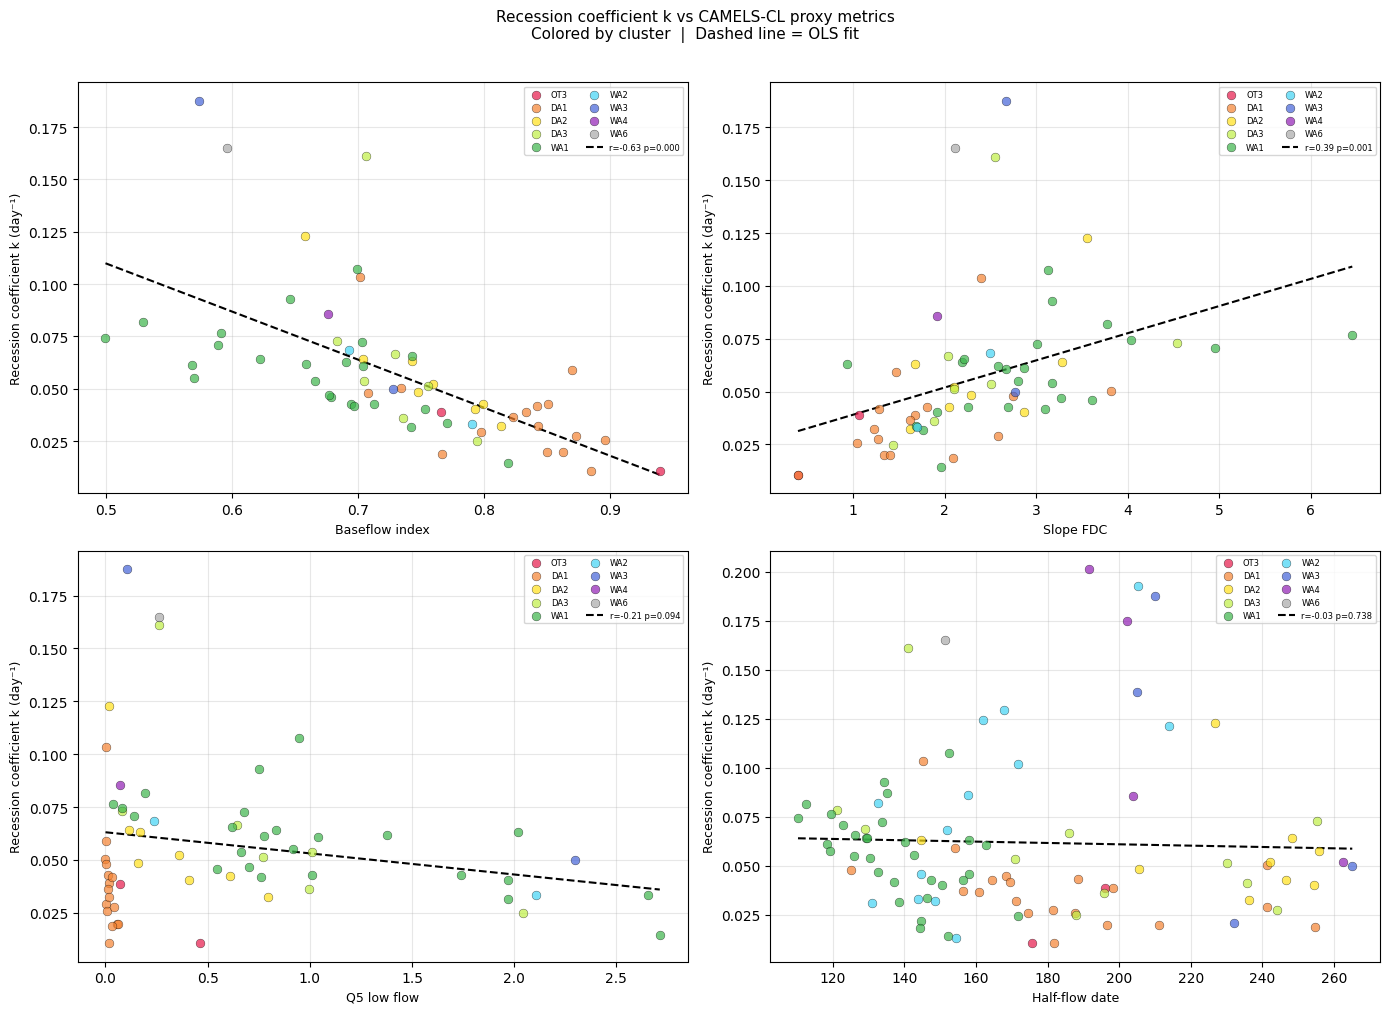


Recession coefficient and proxy metrics by cluster:
Cluster k_median   BFI      slope_fdc  hfd_mean   n
-------------------------------------------------------
OT3        0.0248    0.853      0.732      185.8   2
DA1        0.0365    0.843      1.548      178.0  21
DA2        0.0549    0.754      2.193      242.2  10
DA3        0.0679    0.729      2.103      188.1  14
WA1        0.0554    0.685      2.834      137.2  44
WA2        0.0619    0.742      2.096      154.5  30
WA3        0.0498    0.651      2.716      221.0   7
WA4        0.0792    0.676      1.916      203.0   7
WA6        0.1315    0.596      2.118      151.2   2


In [ ]:
# ── Cell X: Compare computed k with CAMELS-CL proxy metrics ──────────────
#
# CAMELS-CL catchment attributes provide several related metrics:
# - baseflow_index: fraction of streamflow from baseflow (groundwater)
#   Higher BFI = more groundwater = slower recession expected
# - slope_fdc: slope of flow duration curve between Q33 and Q66
#   Steeper slope = more variable flow = faster recession
# - Q5/Q95: low and high flow percentiles
# - hfd_mean: half-flow date (day of year by which 50% of annual flow
#   has passed) — later HFD = more storage / delayed routing

attrs = pd.read_csv(f'{CAMELS_FULL}/catchment_attributes.csv',
                    dtype={'gauge_id': str})
proxy_cols = ['gauge_id', 'baseflow_index_1979_2010',
              'slope_fdc_1979_2010', 'Q5_1979_2010',
              'Q95_1979_2010', 'hfd_mean']
attrs_sub = attrs[proxy_cols].copy()

df_rec_full = df_recession.merge(attrs_sub, on='gauge_id', how='left')

# ── Correlation table ──────────────────────────────────────────────────────
print('Correlations between computed k and CAMELS-CL proxy metrics:')
print()
proxy_vars = {
    'baseflow_index_1979_2010': 'Baseflow index (expect: k neg corr)',
    'slope_fdc_1979_2010':      'Slope FDC (expect: k pos corr)',
    'Q5_1979_2010':             'Q5 low flow (expect: k neg corr)',
    'hfd_mean':                 'Half-flow date (expect: k neg corr)',
}

for col, label in proxy_vars.items():
    sub = df_rec_full[['k_median', col]].dropna()
    if len(sub) < 5:
        continue
    r, p = stats.pearsonr(sub['k_median'], sub[col])
    sig  = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f'  k vs {label[:35]:35s}: r={r:+.3f}  p={p:.3e}  {sig}')

# ── Figure: k vs proxy metrics ────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes_flat = axes.flatten()

cluster_colors_map = {
    'OT3':'#e6194b', 'DA1':'#f58231', 'DA2':'#ffe119',
    'DA3':'#bfef45', 'WA1':'#3cb44b', 'WA2':'#42d4f4',
    'WA3':'#4363d8', 'WA4':'#911eb4', 'WA6':'#a9a9a9'
}

for ax, (col, label) in zip(axes_flat, proxy_vars.items()):
    for cl in CLUSTERS:
        grp = df_rec_full[df_rec_full['cluster'] == cl]
        if len(grp) == 0:
            continue
        ax.scatter(grp[col], grp['k_median'],
                   c=cluster_colors_map.get(cl, '#888888'),
                   s=40, alpha=0.7, edgecolors='k', lw=0.3,
                   label=cl, zorder=3)

    # Trend line
    sub = df_rec_full[['k_median', col]].dropna()
    if len(sub) > 5:
        slope, intercept, r, p, _ = stats.linregress(sub[col],
                                                       sub['k_median'])
        xfit = np.linspace(sub[col].min(), sub[col].max(), 100)
        ax.plot(xfit, slope*xfit + intercept, 'k--', lw=1.5,
                label=f'r={r:.2f} p={p:.3f}')

    ax.set_xlabel(label.split('(')[0].strip(), fontsize=9)
    ax.set_ylabel('Recession coefficient k (day⁻¹)', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=6, ncol=2)

fig.suptitle(
    'Recession coefficient k vs CAMELS-CL proxy metrics\n'
    'Colored by cluster  |  Dashed line = OLS fit',
    fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(f'{DROUGHT_DIR}/recession_k_vs_proxies.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Summary by cluster ────────────────────────────────────────────────────
print('\nRecession coefficient and proxy metrics by cluster:')
print(f'{"Cluster":6s} {"k_median":10s} {"BFI":8s} '
      f'{"slope_fdc":10s} {"hfd_mean":10s} {"n"}')
print('-' * 55)
for cl in CLUSTERS:
    grp = df_rec_full[df_rec_full['cluster'] == cl]
    if len(grp) == 0:
        continue
    print(f'{cl:6s} '
          f'{grp["k_median"].median():10.4f} '
          f'{grp["baseflow_index_1979_2010"].median():8.3f} '
          f'{grp["slope_fdc_1979_2010"].median():10.3f} '
          f'{grp["hfd_mean"].median():10.1f} '
          f'{len(grp):3d}')

Regression results loaded: 143 basins
Lag results loaded: 143 gauges

Key correlations with recession coefficient k:

  k vs β_glacier (regression coef)        : r=-0.131  p=1.272e-01  ns
  k vs Per-basin R²                       : r=+0.056  p=5.193e-01  ns
  k vs Glacier % of basin                 : r=-0.015  p=8.654e-01  ns
  k vs Glacier area (km²)                 : r=-0.197  p=2.117e-02  *
  k vs Best lag (months)                  : r=+0.190  p=2.627e-02  *


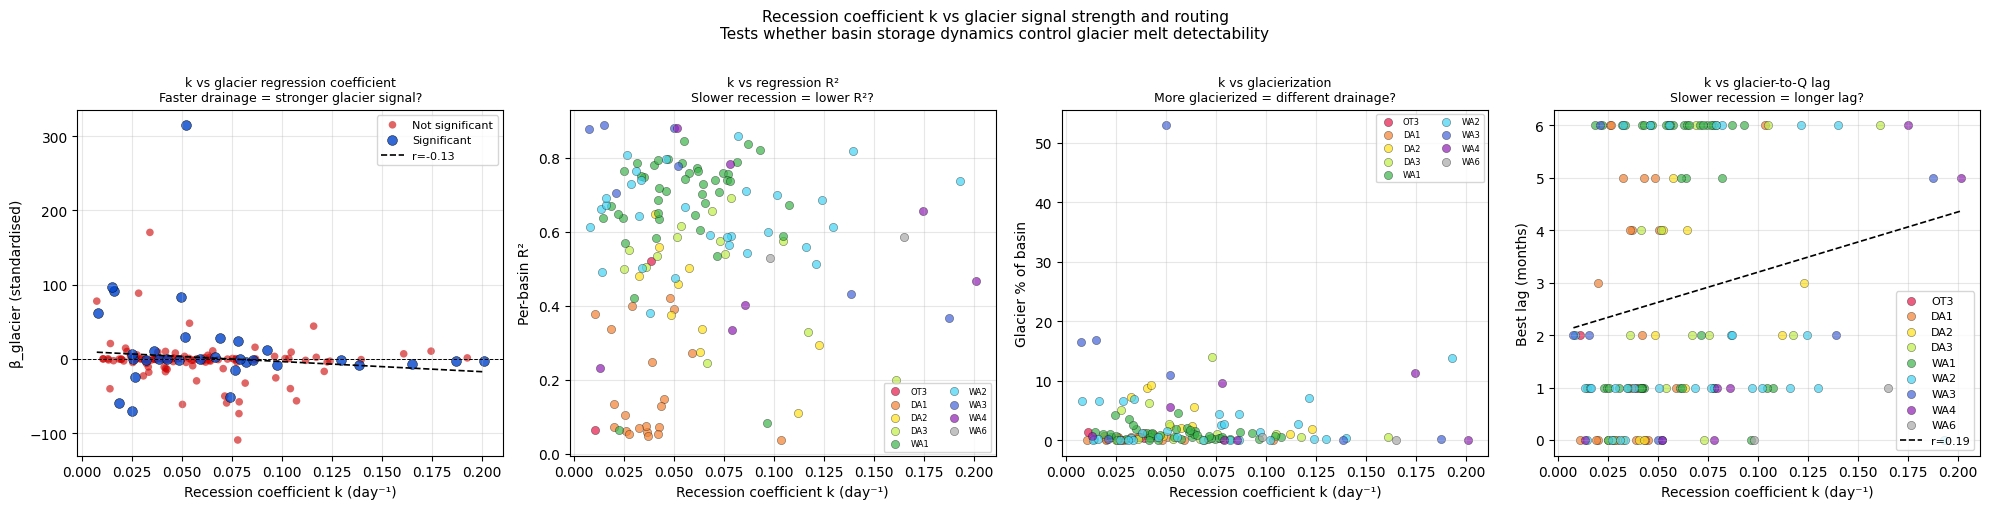


Saved: /Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/all_chile_results_v2/megadrought_analysis/recession_coefficients_all_basins.csv


In [ ]:
# ── Cell XI: Connect recession coefficient to glacier signal ──────────────

pred   = 'coef_glacier_runoff_m3'
lo_col = 'ci_lo_glacier_runoff_m3'
hi_col = 'ci_hi_glacier_runoff_m3'

# Load per-basin regression results from saved CSVs
# (PER_BASIN_A is defined in livneh_experiments.ipynb, not here)
reg_path = f'{OUT_DIR}/regression/per_basin_regression_partA_CR2MET.csv'
if os.path.exists(reg_path):
    df_reg = pd.read_csv(reg_path, dtype={'gauge_id': str})
    df_reg['sig'] = ((df_reg[lo_col] > 0) | (df_reg[hi_col] < 0))
    print(f'Regression results loaded: {len(df_reg)} basins')
else:
    print(f'Regression CSV not found at {reg_path}')
    print('Run livneh_experiments.ipynb Cell 4b first to generate it')
    df_reg = pd.DataFrame(columns=['gauge_id', pred, lo_col, hi_col,
                                    'sig', 'r2'])

# Load lag results
lag_path = f'{OUT_DIR}/lag_analysis/lag_results_CR2MET.csv'
if os.path.exists(lag_path):
    df_lag  = pd.read_csv(lag_path, dtype={'gauge_id': str})
    has_lag = True
    print(f'Lag results loaded: {len(df_lag)} gauges')
else:
    has_lag = False
    print('Lag results not found — run livneh_experiments.ipynb first')

# Merge recession k with regression and lag results
df_k_reg = df_rec_full.merge(
    df_reg[['gauge_id', pred, lo_col, hi_col, 'sig', 'r2']],
    on='gauge_id', how='left')

if has_lag:
    df_k_reg = df_k_reg.merge(
        df_lag[['gauge_id', 'best_lag_months', 'best_r']],
        on='gauge_id', how='left')

# ── Correlations ──────────────────────────────────────────────────────────
print('\nKey correlations with recession coefficient k:')
print()

test_vars = [
    (pred,               'β_glacier (regression coef)'),
    ('r2',               'Per-basin R²'),
    ('glac_pct',         'Glacier % of basin'),
    ('glacier_area_km2', 'Glacier area (km²)'),
]
if has_lag:
    test_vars.append(('best_lag_months', 'Best lag (months)'))

for col, label in test_vars:
    sub = df_k_reg[['k_median', col]].dropna()
    if len(sub) < 5:
        continue
    r, p = stats.pearsonr(sub['k_median'], sub[col])
    sig  = ('***' if p < 0.001 else '**' if p < 0.01
            else '*' if p < 0.05 else 'ns')
    print(f'  k vs {label:35s}: r={r:+.3f}  p={p:.3e}  {sig}')

# ── Figure ────────────────────────────────────────────────────────────────
n_panels = 4 if has_lag else 3
fig, axes = plt.subplots(1, n_panels, figsize=(5*n_panels, 5))

cluster_colors_map = {
    'OT3':'#e6194b', 'DA1':'#f58231', 'DA2':'#ffe119',
    'DA3':'#bfef45', 'WA1':'#3cb44b', 'WA2':'#42d4f4',
    'WA3':'#4363d8', 'WA4':'#911eb4', 'WA6':'#a9a9a9'
}

# Panel 1: k vs β_glacier
ax = axes[0]
sig_mask = df_k_reg['sig'] == True
ax.scatter(df_k_reg.loc[~sig_mask, 'k_median'],
           df_k_reg.loc[~sig_mask, pred],
           c='#cc0000', s=30, alpha=0.6, edgecolors='none',
           label='Not significant')
ax.scatter(df_k_reg.loc[sig_mask, 'k_median'],
           df_k_reg.loc[sig_mask, pred],
           c='#0044cc', s=50, alpha=0.8, edgecolors='k', lw=0.4,
           label='Significant')
ax.axhline(0, color='k', lw=0.7, ls='--')
ax.set_xlabel('Recession coefficient k (day⁻¹)', fontsize=10)
ax.set_ylabel('β_glacier (standardised)', fontsize=10)
ax.set_title('k vs glacier regression coefficient\n'
             'Faster drainage = stronger glacier signal?', fontsize=9)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

sub = df_k_reg[[pred, 'k_median']].dropna()
if len(sub) > 5:
    slope, intercept, r, p, _ = stats.linregress(
        sub['k_median'], sub[pred])
    xfit = np.linspace(sub['k_median'].min(),
                        sub['k_median'].max(), 100)
    ax.plot(xfit, slope*xfit + intercept, 'k--', lw=1.2,
            label=f'r={r:.2f}')
    ax.legend(fontsize=8)

# Panel 2: k vs per-basin R²
ax = axes[1]
for cl in CLUSTERS:
    grp = df_k_reg[df_k_reg['cluster'] == cl].dropna(
        subset=['k_median','r2'])
    if len(grp) == 0:
        continue
    ax.scatter(grp['k_median'], grp['r2'],
               c=cluster_colors_map.get(cl, '#888'),
               s=35, alpha=0.7, edgecolors='k', lw=0.3, label=cl)
ax.set_xlabel('Recession coefficient k (day⁻¹)', fontsize=10)
ax.set_ylabel('Per-basin R²', fontsize=10)
ax.set_title('k vs regression R²\n'
             'Slower recession = lower R²?', fontsize=9)
ax.legend(fontsize=6, ncol=2)
ax.grid(True, alpha=0.3)

# Panel 3: k vs glacier %
ax = axes[2]
for cl in CLUSTERS:
    grp = df_k_reg[df_k_reg['cluster'] == cl].dropna(
        subset=['k_median','glac_pct'])
    if len(grp) == 0:
        continue
    ax.scatter(grp['k_median'], grp['glac_pct'],
               c=cluster_colors_map.get(cl, '#888'),
               s=35, alpha=0.7, edgecolors='k', lw=0.3, label=cl)
ax.set_xlabel('Recession coefficient k (day⁻¹)', fontsize=10)
ax.set_ylabel('Glacier % of basin', fontsize=10)
ax.set_title('k vs glacierization\n'
             'More glacierized = different drainage?', fontsize=9)
ax.legend(fontsize=6, ncol=2)
ax.grid(True, alpha=0.3)

# Panel 4: k vs best lag
if has_lag:
    ax = axes[3]
    for cl in CLUSTERS:
        grp = df_k_reg[df_k_reg['cluster'] == cl].dropna(
            subset=['k_median','best_lag_months'])
        if len(grp) == 0:
            continue
        ax.scatter(grp['k_median'], grp['best_lag_months'],
                   c=cluster_colors_map.get(cl, '#888'),
                   s=35, alpha=0.7, edgecolors='k', lw=0.3, label=cl)
    ax.set_xlabel('Recession coefficient k (day⁻¹)', fontsize=10)
    ax.set_ylabel('Best lag (months)', fontsize=10)
    ax.set_title('k vs glacier-to-Q lag\n'
                 'Slower recession = longer lag?', fontsize=9)
    ax.legend(fontsize=6, ncol=2)
    ax.grid(True, alpha=0.3)

    sub = df_k_reg[['k_median','best_lag_months']].dropna()
    if len(sub) > 5:
        slope, intercept, r, p, _ = stats.linregress(
            sub['k_median'], sub['best_lag_months'])
        xfit = np.linspace(sub['k_median'].min(),
                            sub['k_median'].max(), 100)
        axes[3].plot(xfit, slope*xfit + intercept, 'k--', lw=1.2,
                     label=f'r={r:.2f}')
        axes[3].legend(fontsize=8)

fig.suptitle(
    'Recession coefficient k vs glacier signal strength and routing\n'
    'Tests whether basin storage dynamics control glacier melt detectability',
    fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(f'{DROUGHT_DIR}/recession_k_vs_glacier_signal.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Save ──────────────────────────────────────────────────────────────────
df_k_reg.to_csv(
    f'{DROUGHT_DIR}/recession_coefficients_all_basins.csv', index=False)
print(f'\nSaved: {DROUGHT_DIR}/recession_coefficients_all_basins.csv')

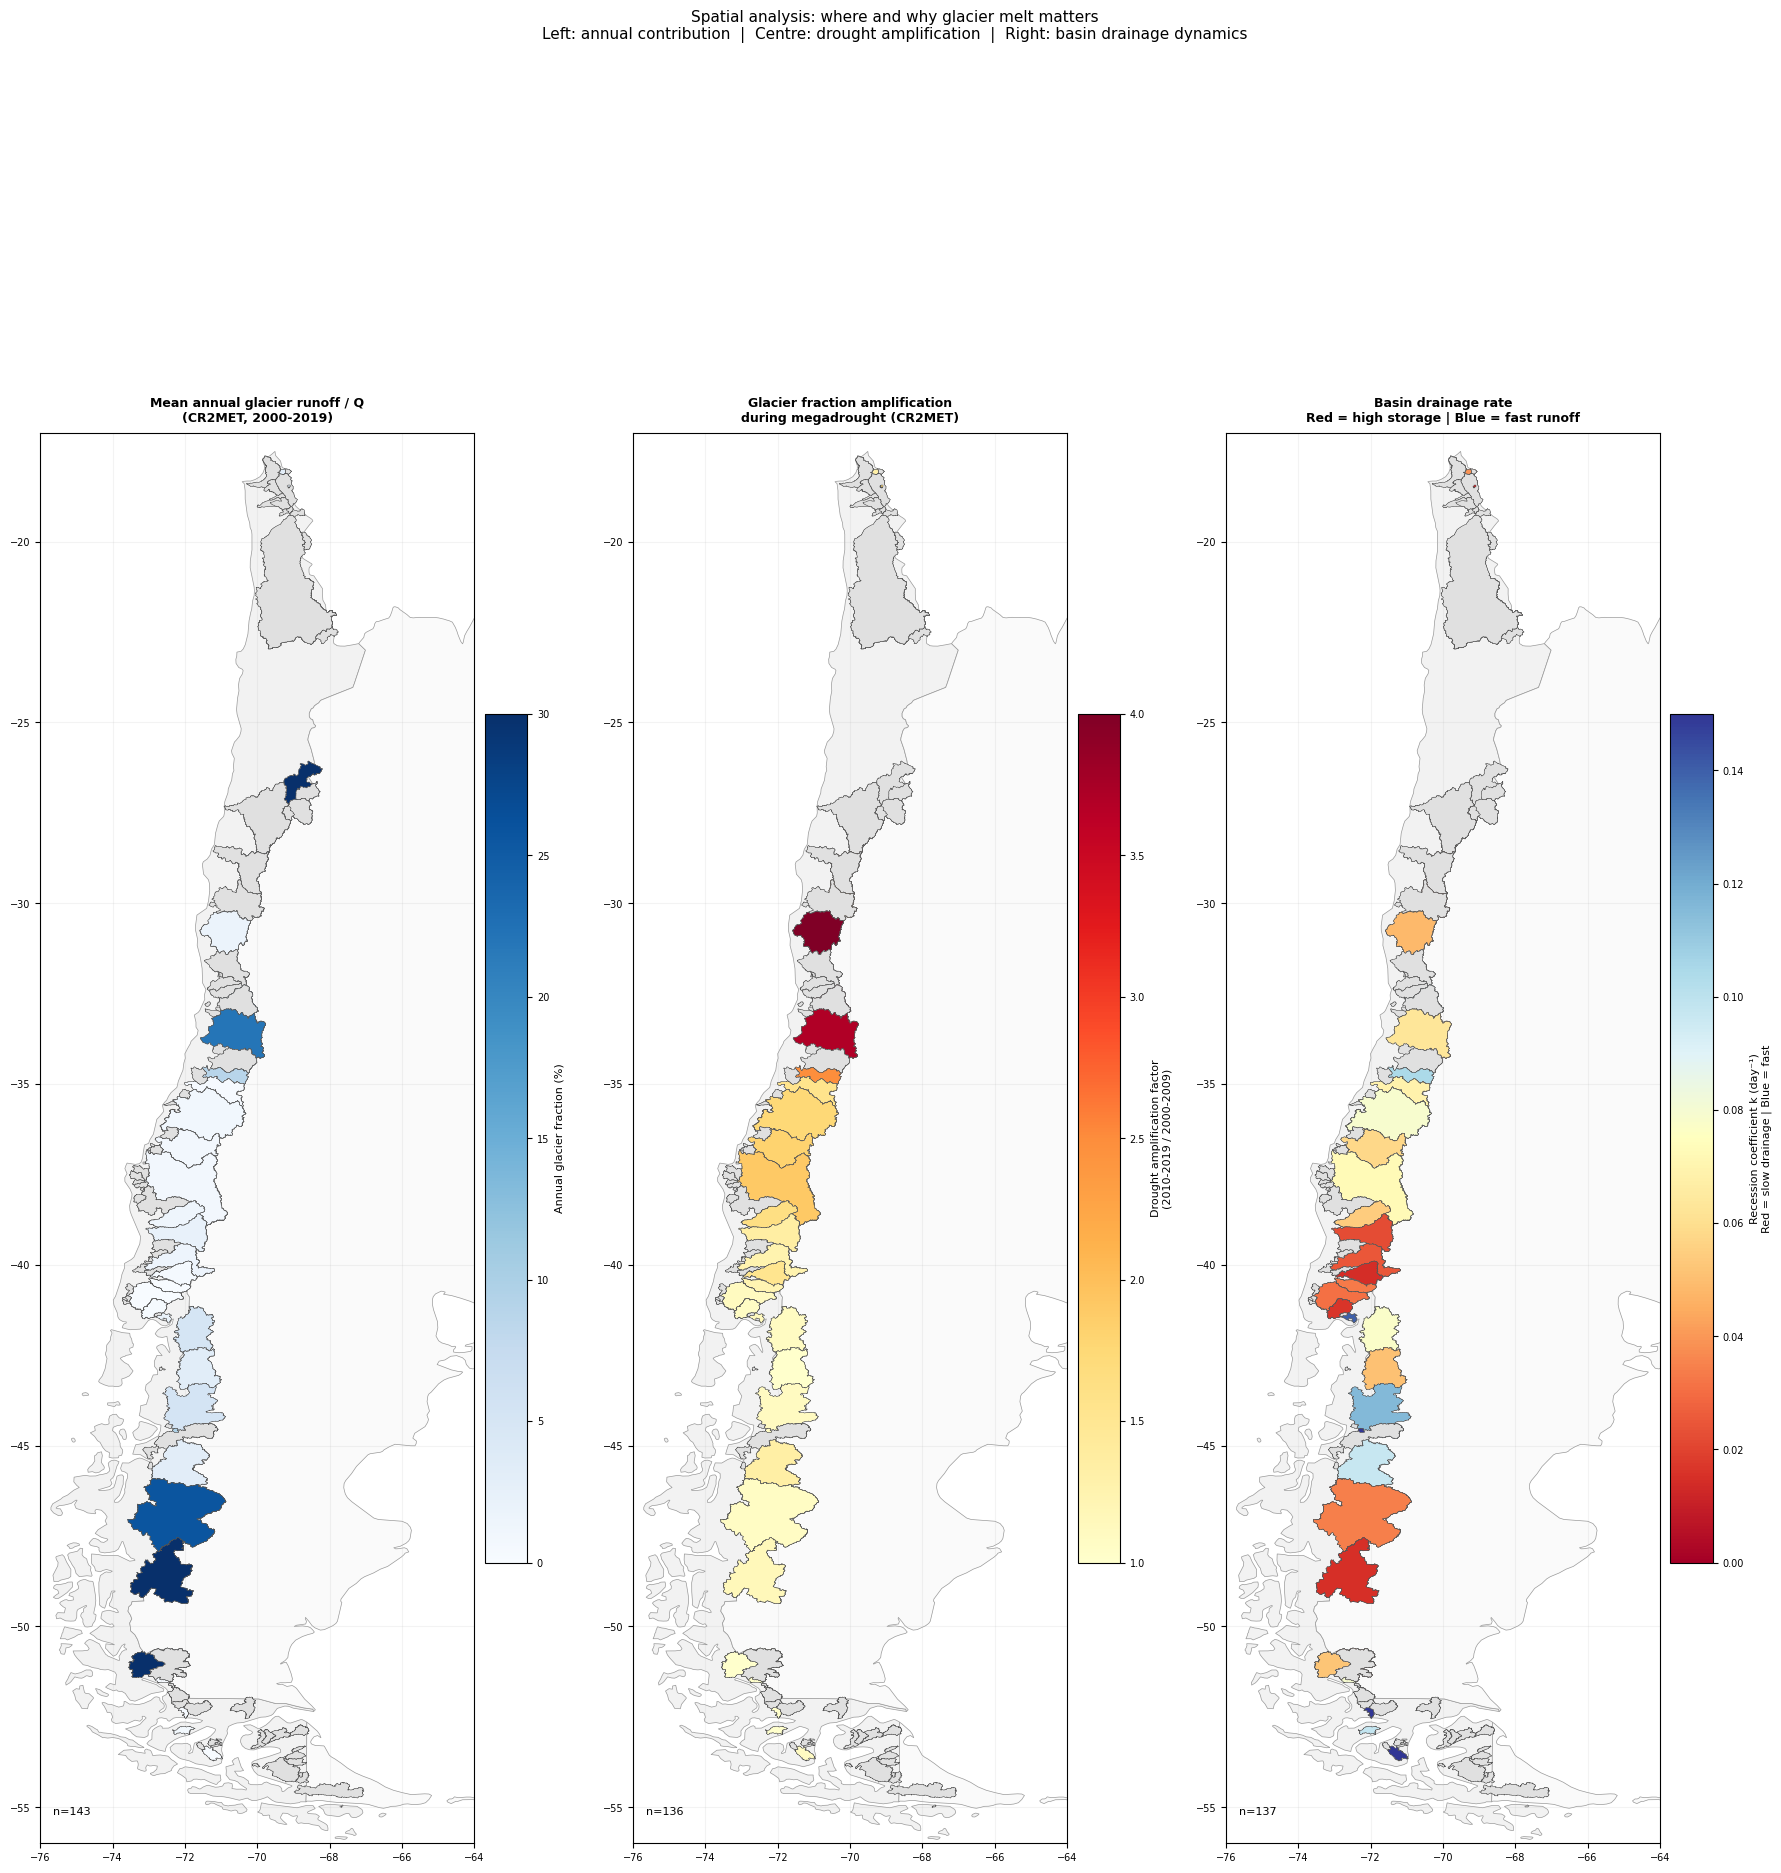

Top 20 most drought-amplified basins (CR2MET, 2010-2019 vs baseline):
  7357002    Rio Loncomilla En Bodega            amp=7.23x  ann_frac=1.6%  cluster=WA1  lat=-36.2°S
  5410005    Rio Aconcagua En San Felipe         amp=6.68x  ann_frac=23.2%  cluster=DA2  lat=-33.0°S
  7321002    Rio Maule En Armerillo              amp=6.22x  ann_frac=23.5%  cluster=DA3  lat=-36.0°S
  5423003    Rio Aconcagua En Romeral            amp=5.80x  ann_frac=20.1%  cluster=DA2  lat=-33.0°S
  4558001    Rio Limari En Panamericana          amp=5.42x  ann_frac=1.8%  cluster=DA1  lat=-30.5°S
  7317005    Rio Melado En El Salto              amp=4.49x  ann_frac=5.6%  cluster=DA3  lat=-36.1°S
  3421001    Rio Manflas En Vertedero            amp=4.16x  ann_frac=61.8%  cluster=DA1  lat=-28.6°S
  5748001    Rio Maipo En Cabimbao               amp=3.70x  ann_frac=22.0%  cluster=DA2  lat=-33.7°S
  10111001   Rio San Pedro En Desague Lago Rinih amp=3.48x  ann_frac=3.7%  cluster=WA1  lat=-39.7°S
  3431001    Rio Copiapo 

In [ ]:
# ── Cell XII: Spatial analysis — where and why glaciers matter ────────────

from matplotlib.colors import Normalize, to_hex
from matplotlib.cm import ScalarMappable

# Load basin boundaries if not already loaded
if 'bounds' not in dir():
    bounds = gpd.read_file(BOUNDS_PATH)
    bounds['gauge_id'] = bounds['gauge_id'].astype(str)

if 'chile' not in dir():
    try:
        world       = gpd.read_file(
            'https://naturalearth.s3.amazonaws.com/50m_cultural/'
            'ne_50m_admin_0_countries.zip')
        chile       = world[world['NAME'] == 'Chile']
        arg         = world[world['NAME'] == 'Argentina']
        has_borders = True
    except Exception:
        has_borders = False
        print('Country borders unavailable')

# ── Build per-basin summary for mapping ───────────────────────────────────
frac_by_gauge = {}
for gauge_id, res in RESULTS['CR2MET'].items():
    if res is None:
        continue
    m  = res['monthly']
    cy = res.get('complete_years', YEARS)
    ann = (m[m['year'].isin(cy)]
           .groupby('year').agg(
               glac=('glacier_runoff_m3','sum'),
               q   =('q_m3_mon','sum')))
    ann = ann[ann['q'] > 0]
    if len(ann):
        frac_by_gauge[gauge_id] = (ann['glac']/ann['q']).mean() * 100

amp_by_gauge = {}
for gauge_id, res in RESULTS['CR2MET'].items():
    if res is None:
        continue
    info = GAUGE_INFO_FRAC.get(gauge_id)
    if info is None:
        continue
    m  = res['monthly']
    cy = res.get('complete_years', YEARS)

    def period_frac(years):
        valid = [y for y in years if y in cy]
        if len(valid) < 2:
            return np.nan
        sub = m[m['year'].isin(valid)]
        ann = sub.groupby('year').agg(
            glac=('glacier_runoff_m3','sum'),
            q   =('q_m3_mon','sum'))
        ann = ann[ann['q'] > 0]
        if len(ann) == 0:
            return np.nan
        return (ann['glac']/ann['q']).mean()

    f_base    = period_frac(BASELINE)
    f_drought = period_frac(list(range(2010, 2020)))
    if not any(np.isnan([f_base, f_drought])) and f_base > 0:
        amp_by_gauge[gauge_id] = f_drought / f_base

# ── Prepare bounds for plotting ───────────────────────────────────────────
bounds_plot = bounds.copy()
bounds_plot['frac_ann']   = bounds_plot['gauge_id'].map(frac_by_gauge)
bounds_plot['amp_factor'] = bounds_plot['gauge_id'].map(amp_by_gauge)
bounds_plot['k_median']   = bounds_plot['gauge_id'].map(
    df_recession.set_index('gauge_id')['k_median'].to_dict())

# ── Figure: 3 maps ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 22))

map_configs = [
    ('frac_ann',
     plt.cm.Blues,
     Normalize(0, 30),
     'Annual glacier fraction (%)',
     'Mean annual glacier runoff / Q\n(CR2MET, 2000-2019)'),

    ('amp_factor',
     plt.cm.YlOrRd,
     Normalize(1, 4),
     'Drought amplification factor\n(2010-2019 / 2000-2009)',
     'Glacier fraction amplification\nduring megadrought (CR2MET)'),

    ('k_median',
     plt.cm.RdYlBu,       # red = slow drainage, blue = fast drainage
     Normalize(0.00, 0.15),
     'Recession coefficient k (day⁻¹)\nRed = slow drainage | Blue = fast',
     'Basin drainage rate\nRed = high storage | Blue = fast runoff'),
]

for ax, (col, cmap, norm, cbar_label, title) in zip(axes, map_configs):
    if has_borders:
        chile.plot(ax=ax, facecolor='#f2f2f2',
                   edgecolor='#999999', linewidth=0.5, zorder=0)
        arg.plot(ax=ax, facecolor='#fafafa',
                 edgecolor='#999999', linewidth=0.5, zorder=0)

    # Background grey
    bounds.plot(ax=ax, facecolor='#e0e0e0', edgecolor='#cccccc',
                linewidth=0.2, zorder=1)

    # Coloured basins
    face_colors = [
        to_hex(cmap(norm(v))) if (v is not None and not np.isnan(v))
        else '#e0e0e0'
        for v in bounds_plot[col].values]
    bounds_plot.plot(ax=ax, color=face_colors,
                     edgecolor='#555555', linewidth=0.3, zorder=2)

    ax.set_xlim(-76, -64)
    ax.set_ylim(-56, -17)
    ax.set_aspect('equal')
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.15)
    ax.set_title(title, fontsize=9, fontweight='bold', pad=8)

    n_valid = bounds_plot[col].notna().sum()
    ax.text(0.03, 0.02, f'n={n_valid}',
            transform=ax.transAxes, fontsize=8)

    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cb = fig.colorbar(sm, ax=ax, shrink=0.4, pad=0.02)
    cb.set_label(cbar_label, fontsize=8)
    cb.ax.tick_params(labelsize=7)

fig.suptitle(
    'Spatial analysis: where and why glacier melt matters\n'
    'Left: annual contribution  |  Centre: drought amplification  '
    '|  Right: basin drainage dynamics',
    fontsize=11, y=1.002)
plt.tight_layout()
plt.savefig(f'{DROUGHT_DIR}/spatial_analysis_three_maps.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Top 20 most drought-amplified basins ─────────────────────────────────
print('Top 20 most drought-amplified basins (CR2MET, 2010-2019 vs baseline):')
top_amp = (pd.DataFrame({'gauge_id': list(amp_by_gauge.keys()),
                          'amp_factor': list(amp_by_gauge.values())})
           .sort_values('amp_factor', ascending=False)
           .head(20))

for _, row in top_amp.iterrows():
    gid  = row['gauge_id']
    info = GAUGE_INFO_FRAC.get(gid, {})
    frac = frac_by_gauge.get(gid, np.nan)
    print(f'  {gid:10s} {info.get("gauge_name","")[:35]:35s} '
          f'amp={row["amp_factor"]:.2f}x  '
          f'ann_frac={frac:.1f}%  '
          f'cluster={info.get("clusters",["?"])[0]}  '
          f'lat={info.get("cen_lat",np.nan):.1f}°S')

^Map 1 (annual glacier fraction, blue shading): Darker blue = more glacier-dependent. The darkest colors in DA1-DA2 (Aconcagua, Maipo, Copiapo basins around 28-34°S) and in WA3 (Patagonia). WA1 should be light blue — modest but nonzero contributions across many basins.

Map 2 (drought amplification, yellow-red shading): Darker red = glacier contributions amplified most during drought. You should see the strongest colors in DA2 (Santiago region) and DA1 (Atacama/Coquimbo), with moderate amplification in WA1. Patagonia (WA3, WA4) should be pale or grey since those regions got wetter not drier during the megadrought. This map directly answers the question "where did glaciers become a drought lifeline?"

Map 3 (recession coefficient k, blue red shading): Red = faster drainage, less storage. You should see faster drainage in the south (WA6, WA4) where soils are thin and terrain is steep, and slower drainage in the north in blue (OT3, DA1) where groundwater storage is high. WA1 shows intermediate to fast values consistent with the volcanic aquifer storage hypothesis.

The most drought-amplified basins span both high-fraction (DA1-DA2, already glacier-dependent) and low-fraction (WA1, normally precipitation-dominated) clusters. This means the megadrought revealed glacier dependence in basins that wouldn't typically be considered glacier-sensitive

## basin aridity question 

Aridity index (PET/P, or P/PET depending on convention) characterizes how water-limited a basin is. We already have this in CAMELS-CL — aridity_cr2met_1990_2010 is right there in the catchment attributes. The idea is that in more arid basins, glaciers should be proportionally more important as a water source because there are fewer alternative sources. Plotting glacier fraction or β_glacier against aridity index would let you show whether glacier importance scales with aridity across Chile's latitudinal gradient.

Cell XIII — the main aridity vs glacier importance scatter plots. Three panels showing annual fraction, February fraction, and drought amplification factor all plotted against log aridity index, with significant basins highlighted and cluster color coding. Includes the arid/humid boundary line at aridity=1.
Cell XIV — formal correlation tests (raw and log aridity) and boxplots of glacier fraction by aridity class (very humid to hyper-arid). This directly quantifies whether more arid basins show higher glacier fractions and stronger drought amplification.
Cell XV — annual aridity may miss the seasonal story. WA1 is annually humid (aridity ~0.3) but may be seasonally arid (and increasingly so) in summer (low DJF precipitation, high PET). This cell computes summer vs winter aridity indices per basin and tests whether summer aridity predicts glacier fraction better than annual aridity. If it does, it's a strong finding — glaciers matter in humid basins specifically because those basins experience seasonal water stress in summer even when they're wet annually.

Aridity analysis dataset: 137 basins

Aridity index by cluster (CR2MET 1979-2010):
         median   min    max
cluster                     
DA1        5.84  3.71  10.51
DA2        1.26  0.75   2.10
DA3        0.54  0.43   0.89
OT3        2.06  2.02   2.10
WA1        0.47  0.28   1.06
WA2        0.44  0.26   1.49
WA3        0.88  0.29   2.58
WA4        0.81  0.29   3.89
WA6        0.72  0.63   0.81


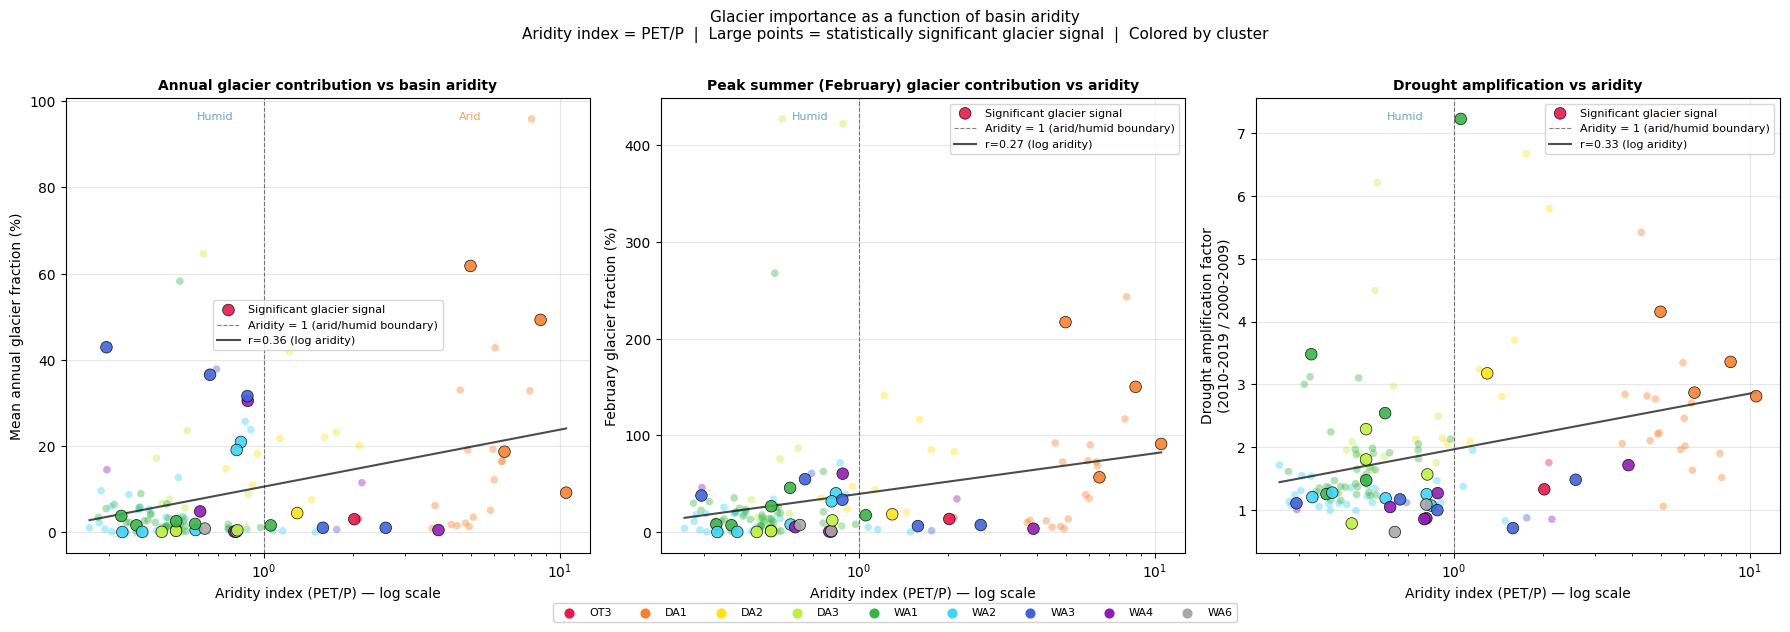

In [ ]:
# ── Cell XIII: Basin aridity analysis ─────────────────────────────────────
#
# Becca's suggestion: plot glacier importance in the context of basin
# aridity to show how glaciers become more critical water sources in
# more water-limited environments.
#
# Aridity index = PET / P (from CAMELS-CL).
# Values > 1 = arid (more potential evaporation than precipitation)
# Values < 1 = humid (more precipitation than potential evaporation)
#
# We use aridity_cr2met_1979_2010 as primary metric — consistent with
# our CR2MET glacier forcing and full gauge coverage.

# ── Load aridity and topography from catchment attributes ─────────────────
attrs = pd.read_csv(f'{CAMELS_FULL}/catchment_attributes.csv',
                    dtype={'gauge_id': str})

attr_cols = ['gauge_id', 'gauge_lat', 'gauge_lon',
             'aridity_cr2met_1979_2010',
             'aridity_cr2met_1990_2010',
             'mean_elev', 'med_elev', 'max_elev',
             'outlet_camels_elev', 'mean_slope_perc',
             'baseflow_index_1979_2010',
             'frac_snow_cr2met_1979_2010',
             'p_mean_cr2met_1979_2010',
             'pet_mean_1979_2010',
             'q_mean_1979_2010',
             'runoff_ratio_cr2met_1979_2010']
attrs_sub = attrs[[c for c in attr_cols if c in attrs.columns]].copy()

# ── Build per-basin analysis DataFrame ───────────────────────────────────
# Annual glacier fraction (CR2MET, complete years only)
frac_records = []
for gauge_id, res in RESULTS['CR2MET'].items():
    if res is None:
        continue
    info = GAUGE_INFO_FRAC.get(gauge_id)
    if info is None:
        continue
    m  = res['monthly']
    cy = res.get('complete_years', YEARS)

    ann = (m[m['year'].isin(cy)]
           .groupby('year').agg(
               glac=('glacier_runoff_m3', 'sum'),
               q   =('q_m3_mon',          'sum')))
    ann = ann[ann['q'] > 0]
    if len(ann) == 0:
        continue

    # Drought amplification (2010-2019 vs baseline)
    f_base    = (ann.loc[ann.index.isin(BASELINE), 'glac'] /
                 ann.loc[ann.index.isin(BASELINE), 'q']).mean()
    f_drought = (ann.loc[ann.index.isin(range(2010,2020)), 'glac'] /
                 ann.loc[ann.index.isin(range(2010,2020)), 'q']).mean()
    amp = f_drought / f_base if (f_base > 0 and
                                  not np.isnan(f_base)) else np.nan

    # February fraction
    feb = m[(m['month'] == 2) & m['year'].isin(cy)]
    feb = feb[feb['q_m3_mon'] > 0]
    feb_frac = (feb['glacier_runoff_m3'] /
                feb['q_m3_mon']).mean() * 100 if len(feb) else np.nan

    frac_records.append({
        'gauge_id':         gauge_id,
        'gauge_name':       info['gauge_name'][:35],
        'lat':              info['cen_lat'],
        'cluster':          info['clusters'][0],
        'glacier_area_km2': info['glacier_area_km2'],
        'basin_area_km2':   info['basin_area_km2'],
        'glac_pct':         info['glacier_area_km2'] /
                            info['basin_area_km2'] * 100,
        'mean_ann_frac':    (ann['glac'] / ann['q']).mean() * 100,
        'feb_frac':         feb_frac,
        'amp_factor':       amp,
    })

df_aridity = (pd.DataFrame(frac_records)
              .merge(attrs_sub, on='gauge_id', how='left'))

# Add regression significance
pred   = 'coef_glacier_runoff_m3'
lo_col = 'ci_lo_glacier_runoff_m3'
hi_col = 'ci_hi_glacier_runoff_m3'
# Load regression results from CSV (PER_BASIN_A not available in this notebook)
reg_path = f'{OUT_DIR}/regression/per_basin_regression_partA_CR2MET.csv'
df_cr2_sig = pd.read_csv(reg_path, dtype={'gauge_id': str})
df_cr2_sig['sig'] = ((df_cr2_sig[lo_col] > 0) |
                      (df_cr2_sig[hi_col] < 0))
df_aridity = df_aridity.merge(
    df_cr2_sig[['gauge_id','sig', pred, 'r2']].rename(
        columns={pred: 'beta_glacier'}),
    on='gauge_id', how='left')

print(f'Aridity analysis dataset: {len(df_aridity)} basins')
print(f'\nAridity index by cluster (CR2MET 1979-2010):')
print(df_aridity.groupby('cluster')['aridity_cr2met_1979_2010']
      .agg(['median','min','max']).round(2).to_string())

# ── Figure 1: Glacier fraction vs aridity ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plot_configs = [
    ('mean_ann_frac', 'Mean annual glacier fraction (%)',
     'Annual glacier contribution vs basin aridity'),
    ('feb_frac',      'February glacier fraction (%)',
     'Peak summer (February) glacier contribution vs aridity'),
    ('amp_factor',    'Drought amplification factor\n(2010-2019 / 2000-2009)',
     'Drought amplification vs aridity'),
]

for ax, (ycol, ylabel, title) in zip(axes, plot_configs):
    sub = df_aridity[['aridity_cr2met_1979_2010', ycol,
                       'cluster', 'sig']].dropna()

    # Non-significant basins
    ns = sub[sub['sig'] == False]
    ax.scatter(ns['aridity_cr2met_1979_2010'], ns[ycol],
               c=[cluster_colors_map.get(c,'#888') for c in ns['cluster']],
               s=30, alpha=0.4, edgecolors='none', zorder=2)

    # Significant basins — larger with black edge
    sg = sub[sub['sig'] == True]
    ax.scatter(sg['aridity_cr2met_1979_2010'], sg[ycol],
               c=[cluster_colors_map.get(c,'#888') for c in sg['cluster']],
               s=70, alpha=0.9, edgecolors='k', lw=0.5, zorder=3,
               label='Significant glacier signal')

    # Log scale for aridity (spans 0.2 to 24)
    ax.set_xscale('log')
    ax.axvline(1.0, color='k', lw=0.8, ls='--', alpha=0.5,
               label='Aridity = 1 (arid/humid boundary)')

    # Trend line
    x = np.log10(sub['aridity_cr2met_1979_2010'].clip(lower=0.1))
    y = sub[ycol]
    if len(x) > 5:
        slope, intercept, r, p, _ = stats.linregress(x, y)
        xfit_log = np.linspace(x.min(), x.max(), 100)
        xfit     = 10**xfit_log
        ax.plot(xfit, slope*xfit_log + intercept,
                'k-', lw=1.5, alpha=0.7,
                label=f'r={r:.2f} (log aridity)')

    ax.set_xlabel('Aridity index (PET/P) — log scale', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Annotate arid/humid regions
    ax.text(0.25, 0.97, 'Humid', transform=ax.transAxes,
            fontsize=8, va='top', color='#2980b9', alpha=0.7)
    ax.text(0.75, 0.97, 'Arid', transform=ax.transAxes,
            fontsize=8, va='top', color='#e67e22', alpha=0.7)

# Shared cluster legend
handles = [plt.scatter([],[],
                        c=cluster_colors_map.get(cl,'#888'),
                        s=40, label=cl)
           for cl in CLUSTERS if cl in cluster_colors_map]
fig.legend(handles=handles, loc='lower center', ncol=len(handles),
           fontsize=8, bbox_to_anchor=(0.5, -0.02), framealpha=0.9)

fig.suptitle(
    'Glacier importance as a function of basin aridity\n'
    'Aridity index = PET/P  |  Large points = statistically significant '
    'glacier signal  |  Colored by cluster',
    fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(f'{DROUGHT_DIR}/aridity_vs_glacier_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

Correlation of aridity with glacier importance metrics:

Aridity vs annual glacier fraction:
  Raw aridity:     r=+0.396  p=1.666e-06  ***
  Log10 aridity:   r=+0.363  p=1.281e-05  ***

Aridity vs February glacier fraction:
  Raw aridity:     r=+0.289  p=6.093e-04  ***
  Log10 aridity:   r=+0.274  p=1.217e-03  **

Aridity vs drought amplification factor:
  Raw aridity:     r=+0.270  p=1.449e-03  **
  Log10 aridity:   r=+0.330  p=8.254e-05  ***

Aridity vs β_glacier (regression coef):
  Raw aridity:     r=-0.004  p=9.603e-01  ns
  Log10 aridity:   r=+0.043  p=6.208e-01  ns

Median glacier fraction by aridity class:
                     mean_ann_frac       feb_frac       amp_factor      
                            median count   median count     median count
aridity_class                                                           
<0.5\n(very humid)            2.61    49    13.07    49       1.35    49
0.5-1.0\n(humid)              1.89    49    19.58    49       1.48    49
1.0-2.0\n(sem

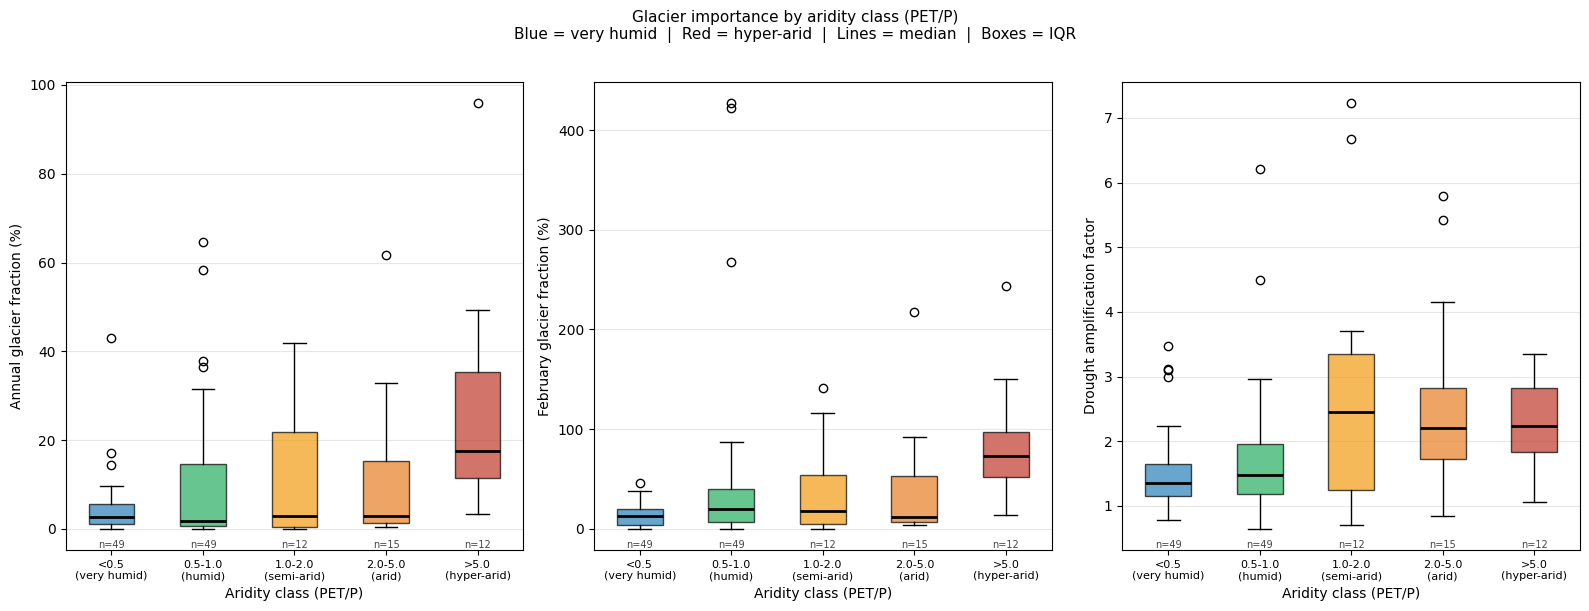

In [ ]:
# ── Cell XIV: Aridity context — summary statistics and regression ──────────
#
# Formally test whether aridity explains glacier fraction and glacier
# signal strength after controlling for glacier area — i.e. are glaciers
# more important in arid basins BEYOND what you'd expect from glacier size?

print('Correlation of aridity with glacier importance metrics:')
print()

test_pairs = [
    ('aridity_cr2met_1979_2010', 'mean_ann_frac',
     'Aridity vs annual glacier fraction'),
    ('aridity_cr2met_1979_2010', 'feb_frac',
     'Aridity vs February glacier fraction'),
    ('aridity_cr2met_1979_2010', 'amp_factor',
     'Aridity vs drought amplification factor'),
    ('aridity_cr2met_1979_2010', 'beta_glacier',
     'Aridity vs β_glacier (regression coef)'),
]

for xcol, ycol, label in test_pairs:
    sub = df_aridity[[xcol, ycol]].dropna()
    if len(sub) < 5:
        continue
    # Test both raw and log-aridity
    r_raw, p_raw = stats.pearsonr(sub[xcol], sub[ycol])
    r_log, p_log = stats.pearsonr(np.log10(sub[xcol].clip(lower=0.1)),
                                   sub[ycol])
    sig_raw = ('***' if p_raw < 0.001 else '**' if p_raw < 0.01
               else '*' if p_raw < 0.05 else 'ns')
    sig_log = ('***' if p_log < 0.001 else '**' if p_log < 0.01
               else '*' if p_log < 0.05 else 'ns')
    print(f'{label}:')
    print(f'  Raw aridity:     r={r_raw:+.3f}  p={p_raw:.3e}  {sig_raw}')
    print(f'  Log10 aridity:   r={r_log:+.3f}  p={p_log:.3e}  {sig_log}')
    print()

# ── Aridity bins: median glacier fraction by aridity class ────────────────
bins   = [0, 0.5, 1.0, 2.0, 5.0, 30.0]
labels = ['<0.5\n(very humid)', '0.5-1.0\n(humid)',
          '1.0-2.0\n(semi-arid)', '2.0-5.0\n(arid)',
          '>5.0\n(hyper-arid)']

df_aridity['aridity_class'] = pd.cut(
    df_aridity['aridity_cr2met_1979_2010'],
    bins=bins, labels=labels)

print('Median glacier fraction by aridity class:')
print(df_aridity.groupby('aridity_class', observed=True)[
    ['mean_ann_frac','feb_frac','amp_factor']
].agg(['median','count']).round(2).to_string())

# ── Figure 2: Boxplot of glacier fraction by aridity class ────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, (col, ylabel) in zip(axes, [
    ('mean_ann_frac', 'Annual glacier fraction (%)'),
    ('feb_frac',      'February glacier fraction (%)'),
    ('amp_factor',    'Drought amplification factor'),
]):
    groups = [df_aridity[df_aridity['aridity_class'] == lab][col].dropna()
              for lab in labels]
    bp = ax.boxplot(groups, patch_artist=True,
                    medianprops=dict(color='k', lw=2))

    colors_box = ['#2980b9','#27ae60','#f39c12','#e67e22','#c0392b']
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_xticklabels(labels, fontsize=8)
    ax.set_xlabel('Aridity class (PET/P)', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    # Sample sizes
    for i, grp in enumerate(groups):
        ax.text(i+1, ax.get_ylim()[0],
                f'n={len(grp)}', ha='center', fontsize=7,
                va='bottom', color='#444444')

fig.suptitle(
    'Glacier importance by aridity class (PET/P)\n'
    'Blue = very humid  |  Red = hyper-arid  |  '
    'Lines = median  |  Boxes = IQR',
    fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(f'{DROUGHT_DIR}/glacier_importance_by_aridity_class.png',
            dpi=150, bbox_inches='tight')
plt.show()

Aridity by cluster tells a clear latitudinal story. DA1 is hyper-arid (median 5.84 — PET is nearly 6x precipitation), consistent with the Atacama. OT3 is arid (2.06). DA2 is semi-arid (1.26). DA3 and all WA clusters are humid (below 1.0, meaning more precipitation than potential evaporation). WA1 at 0.47 is quite humid — nearly twice as much precipitation as PET annually. This confirms the WA1 finding is even more striking: glaciers matter substantially in a basin that is not water-limited annually.

Aridity vs glacier fraction correlations are significant and positive for annual fraction (r=+0.396), February fraction (r=+0.289), and drought amplification (r=+0.270-0.330). More arid basins show higher glacier fractions and stronger drought amplification. This makes physical sense — in arid basins there are fewer alternative water sources, so glacier melt represents a larger share of available water.

But β_glacier shows no correlation with aridity (r=-0.004, ns). This is the most interesting result and tells you something important: the regression coefficient measuring glacier melt's independent explanatory power on monthly Q variability is NOT related to aridity. This means the statistical detectability of the glacier signal in streamflow is driven by something other than how water-limited the basin is — it's driven by glacierization degree (which we already showed: r=0.32) and thermal/snow regime (the WA1 finding). Aridity determines how much glaciers contribute to total water supply, but not whether that contribution is statistically detectable in the month-to-month Q record.

The aridity class table is the most policy-relevant result. The hyper-arid class (DA1 basins, aridity >5) has a median annual glacier fraction of 17.5% and February fraction of 73% — glaciers provide nearly three quarters of summer streamflow in the most arid Chilean basins. And drought amplification is 2.2-2.5x in arid/semi-arid basins vs only 1.35-1.48x in humid basins. More arid basins both depend more on glaciers AND show stronger drought amplification — a double vulnerability.

The humid class result is also important: even in very humid basins (aridity <0.5, n=49), median February glacier fraction is 13% and drought amplification is 1.35x. Glaciers matter in humid basins specifically in summer and during drought, even though annual contributions are modest (2.6%).

Computing seasonal aridity by gauge...
Seasonal aridity merged: 137 gauges

Seasonal aridity by cluster:
Cluster Ann aridity  Summer aridity  Winter aridity  Summer precip(mm)
-----------------------------------------------------------------
OT3            2.06            1.14            9.21           255.0
DA1            5.84           19.82            2.43            14.4
DA2            1.26           10.73            0.33            24.2
DA3            0.54            6.07            0.11            52.4
WA1            0.47            2.64            0.09           165.2
WA2            0.44            1.24            0.09           305.3
WA3            0.88            1.11            0.23           263.1
WA4            0.81            1.13            0.22           223.7
WA6            0.72            1.08            0.16           223.3

Panel 1 rows: 137
Panel 2 rows: 137


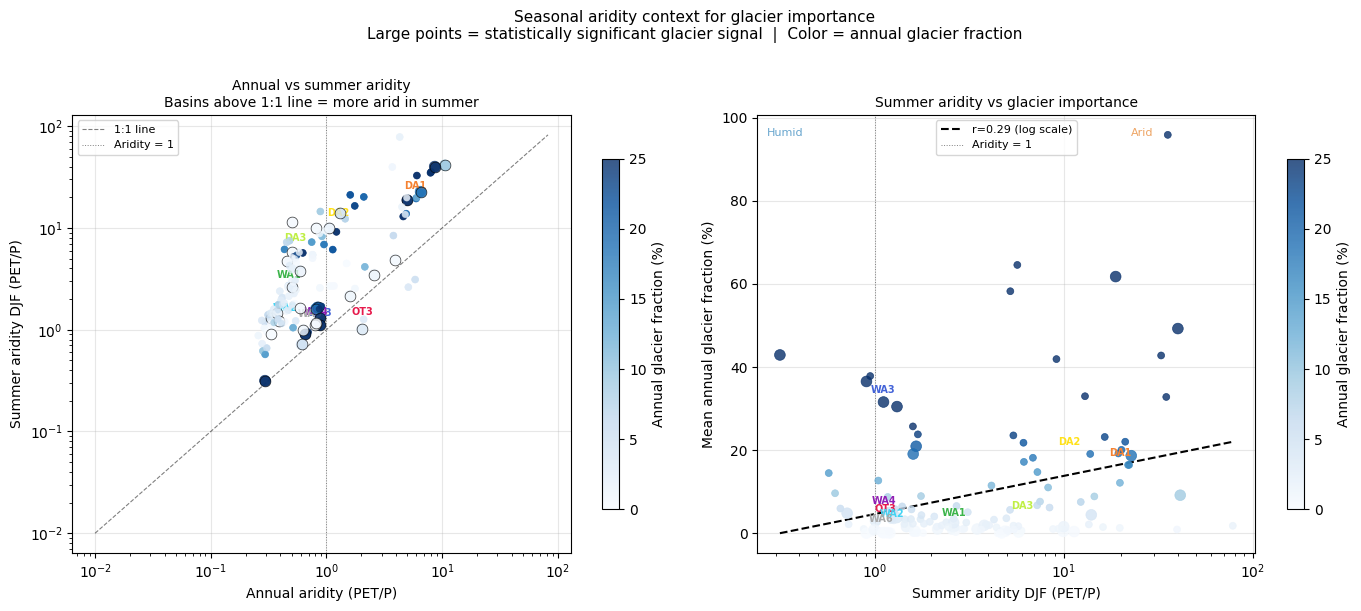


Does summer aridity predict glacier fraction better than annual?
  Annual aridity           : r=+0.363  p=1.281e-05
  Summer aridity DJF       : r=+0.294  p=4.969e-04


In [ ]:
# ── Cell XV: Seasonal aridity ─────────────────────────────────────────────

print('Computing seasonal aridity by gauge...')

NON_GAUGE    = ['date','year','month','day']
gauge_cols_p = [c for c in precip_df.columns if c not in NON_GAUGE]
gauge_cols_e = [c for c in pet_df.columns    if c not in NON_GAUGE]

p_djf = (precip_df[precip_df['month'].isin([12,1,2])]
         .groupby('year')[gauge_cols_p].sum(numeric_only=True).mean())
e_djf = (pet_df[pet_df['month'].isin([12,1,2])]
         .groupby('year')[gauge_cols_e].sum(numeric_only=True).mean())
p_jja = (precip_df[precip_df['month'].isin([6,7,8])]
         .groupby('year')[gauge_cols_p].sum(numeric_only=True).mean())
e_jja = (pet_df[pet_df['month'].isin([6,7,8])]
         .groupby('year')[gauge_cols_e].sum(numeric_only=True).mean())

seasonal_records = []
for gauge_id in GAUGE_INFO_FRAC:
    gid = str(gauge_id)
    p_s = p_djf.get(gid, np.nan)
    e_s = e_djf.get(gid, np.nan)
    p_w = p_jja.get(gid, np.nan)
    e_w = e_jja.get(gid, np.nan)
    seasonal_records.append({
        'gauge_id':       gauge_id,
        'aridity_summer': e_s/p_s if (p_s > 0 and
                           not np.isnan(p_s)) else np.nan,
        'aridity_winter': e_w/p_w if (p_w > 0 and
                           not np.isnan(p_w)) else np.nan,
        'precip_summer':  p_s,
        'precip_winter':  p_w,
        'pet_summer':     e_s,
    })

df_seasonal = pd.DataFrame(seasonal_records)

# Drop old seasonal cols if they exist and re-merge
for col in ['aridity_summer','aridity_winter',
            'precip_summer','precip_winter','pet_summer']:
    if col in df_aridity.columns:
        df_aridity = df_aridity.drop(columns=[col])
df_aridity = df_aridity.merge(df_seasonal, on='gauge_id', how='left')
print(f'Seasonal aridity merged: {df_seasonal["aridity_summer"].notna().sum()} gauges')

# ── Summary table ─────────────────────────────────────────────────────────
print('\nSeasonal aridity by cluster:')
print(f'{"Cluster":6s} {"Ann aridity":12s} {"Summer aridity":15s} '
      f'{"Winter aridity":15s} {"Summer precip(mm)"}')
print('-' * 65)
for cl in CLUSTERS:
    sub = df_aridity[df_aridity['cluster'] == cl]
    if len(sub) == 0:
        continue
    print(f'{cl:6s} '
          f'{sub["aridity_cr2met_1979_2010"].median():12.2f} '
          f'{sub["aridity_summer"].median():15.2f} '
          f'{sub["aridity_winter"].median():15.2f} '
          f'{sub["precip_summer"].median():15.1f}')

# ── Build plot DataFrames explicitly — no loop ────────────────────────────
# Panel 1: annual aridity vs summer aridity
p1_cols = ['aridity_cr2met_1979_2010', 'aridity_summer',
           'mean_ann_frac', 'cluster', 'sig']
p1 = df_aridity[p1_cols].dropna().reset_index(drop=True)
p1['sig'] = p1['sig'].astype(bool)

# Panel 2: summer aridity vs glacier fraction
p2_cols = ['aridity_summer', 'mean_ann_frac', 'cluster', 'sig']
p2 = df_aridity[p2_cols].dropna().reset_index(drop=True)
p2['sig'] = p2['sig'].astype(bool)

print(f'\nPanel 1 rows: {len(p1)}')
print(f'Panel 2 rows: {len(p2)}')

# ── Figure ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: annual vs summer aridity
ax = axes[0]
x1   = p1['aridity_cr2met_1979_2010'].values
y1   = p1['aridity_summer'].values
c1   = p1['mean_ann_frac'].values
s1   = np.where(p1['sig'].values, 60, 25)
ec1  = ['k' if s else 'none' for s in p1['sig'].values]

sc1 = ax.scatter(x1, y1, c=c1, cmap='Blues', vmin=0, vmax=25,
                  s=s1, alpha=0.8, linewidths=0.5, zorder=3)
# edgecolors must be passed separately for variable colors
for i, (xi, yi, si, eci) in enumerate(zip(x1, y1, s1, ec1)):
    ax.scatter(xi, yi, c=[c1[i]], cmap='Blues', vmin=0, vmax=25,
               s=si, alpha=0.8,
               edgecolors=eci, linewidths=0.5, zorder=4)

lim = max(x1.max(), y1.max()) * 1.05
ax.plot([0.01, lim], [0.01, lim], 'k--', lw=0.8, alpha=0.5,
        label='1:1 line')
ax.set_xscale('log')
ax.set_yscale('log')
ax.axvline(1.0, color='grey', lw=0.7, ls=':', label='Aridity = 1')
ax.set_xlabel('Annual aridity (PET/P)', fontsize=10)
ax.set_ylabel('Summer aridity DJF (PET/P)', fontsize=10)
ax.set_title('Annual vs summer aridity\n'
             'Basins above 1:1 line = more arid in summer', fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.colorbar(sc1, ax=ax, label='Annual glacier fraction (%)', shrink=0.8)

for cl in CLUSTERS:
    grp = p1[p1['cluster'] == cl]
    if len(grp) < 2:
        continue
    ax.annotate(cl,
                (np.median(grp['aridity_cr2met_1979_2010']),
                 np.median(grp['aridity_summer'])),
                fontsize=7, fontweight='bold',
                color=cluster_colors_map.get(cl, 'k'),
                ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points')

# Panel 2: summer aridity vs glacier fraction
ax = axes[1]
x2  = p2['aridity_summer'].values
y2  = p2['mean_ann_frac'].values
c2  = p2['mean_ann_frac'].values
s2  = np.where(p2['sig'].values, 60, 25)

sc2 = ax.scatter(x2, y2, c=c2, cmap='Blues', vmin=0, vmax=25,
                  s=s2, alpha=0.8, linewidths=0.5, zorder=3)

# Trend line
if len(x2) > 5:
    slope, intercept, r, p, _ = stats.linregress(
        np.log10(np.clip(x2, 0.01, None)), y2)
    xfit = np.logspace(np.log10(max(x2.min(), 0.01)),
                        np.log10(x2.max()), 100)
    ax.plot(xfit, slope*np.log10(xfit) + intercept,
            'k--', lw=1.5, label=f'r={r:.2f} (log scale)')

ax.axvline(1.0, color='grey', lw=0.7, ls=':', label='Aridity = 1')
ax.set_xscale('log')
ax.set_xlabel('Summer aridity DJF (PET/P)', fontsize=10)
ax.set_ylabel('Mean annual glacier fraction (%)', fontsize=10)
ax.set_title('Summer aridity vs glacier importance', fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.colorbar(sc2, ax=ax, label='Annual glacier fraction (%)', shrink=0.8)

for cl in CLUSTERS:
    grp = p2[p2['cluster'] == cl]
    if len(grp) < 2:
        continue
    ax.annotate(cl,
                (np.median(grp['aridity_summer']),
                 np.median(grp['mean_ann_frac'])),
                fontsize=7, fontweight='bold',
                color=cluster_colors_map.get(cl, 'k'),
                ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points')

ax.text(0.02, 0.97, 'Humid', transform=ax.transAxes,
        fontsize=8, va='top', color='#2980b9', alpha=0.7)
ax.text(0.75, 0.97, 'Arid', transform=ax.transAxes,
        fontsize=8, va='top', color='#e67e22', alpha=0.7)

fig.suptitle(
    'Seasonal aridity context for glacier importance\n'
    'Large points = statistically significant glacier signal  '
    '|  Color = annual glacier fraction',
    fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(f'{DROUGHT_DIR}/seasonal_aridity_glacier_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Final correlation test ─────────────────────────────────────────────────
print('\nDoes summer aridity predict glacier fraction better than annual?')
for col, label in [('aridity_cr2met_1979_2010', 'Annual aridity'),
                    ('aridity_summer',            'Summer aridity DJF')]:
    sub = df_aridity[[col, 'mean_ann_frac']].dropna()
    r, p_val = stats.pearsonr(
        np.log10(sub[col].clip(lower=0.01)),
        sub['mean_ann_frac'])
    print(f'  {label:25s}: r={r:+.3f}  p={p_val:.3e}')

interesting, annual aridity (r=+0.363) predicts glacier fraction slightly better than summer aridity (r=+0.294). Means the overall water balance of the basin (annual PET/P) is a better predictor of glacier dependence than summer water stress specifically. The reason is probably that annual aridity captures the full picture of how water-limited a basin is — including winter precipitation that fills groundwater and sustains baseflow — while summer aridity alone misses that context. A basin can be very arid in summer but have plenty of winter recharge that dilutes the glacier signal.

Summer aridity trend 2000-2019 by cluster (Mann-Kendall slope):
Cluster Slope (yr⁻¹)   p-value    Sig   Direction
-------------------------------------------------------
OT3           +0.0034     0.7985 ns    increasing
DA1           -1.9022     0.1020 ns    decreasing
DA2           -0.2134     0.7566 ns    decreasing
DA3           +0.7072     0.3803 ns    increasing
WA1           +0.0984     0.1686 ns    increasing
WA2           +0.0279     0.2779 ns    increasing
WA3           -0.0150     0.3703 ns    decreasing
WA4           -0.0043     0.7213 ns    decreasing
WA6           +0.0023     0.8204 ns    increasing


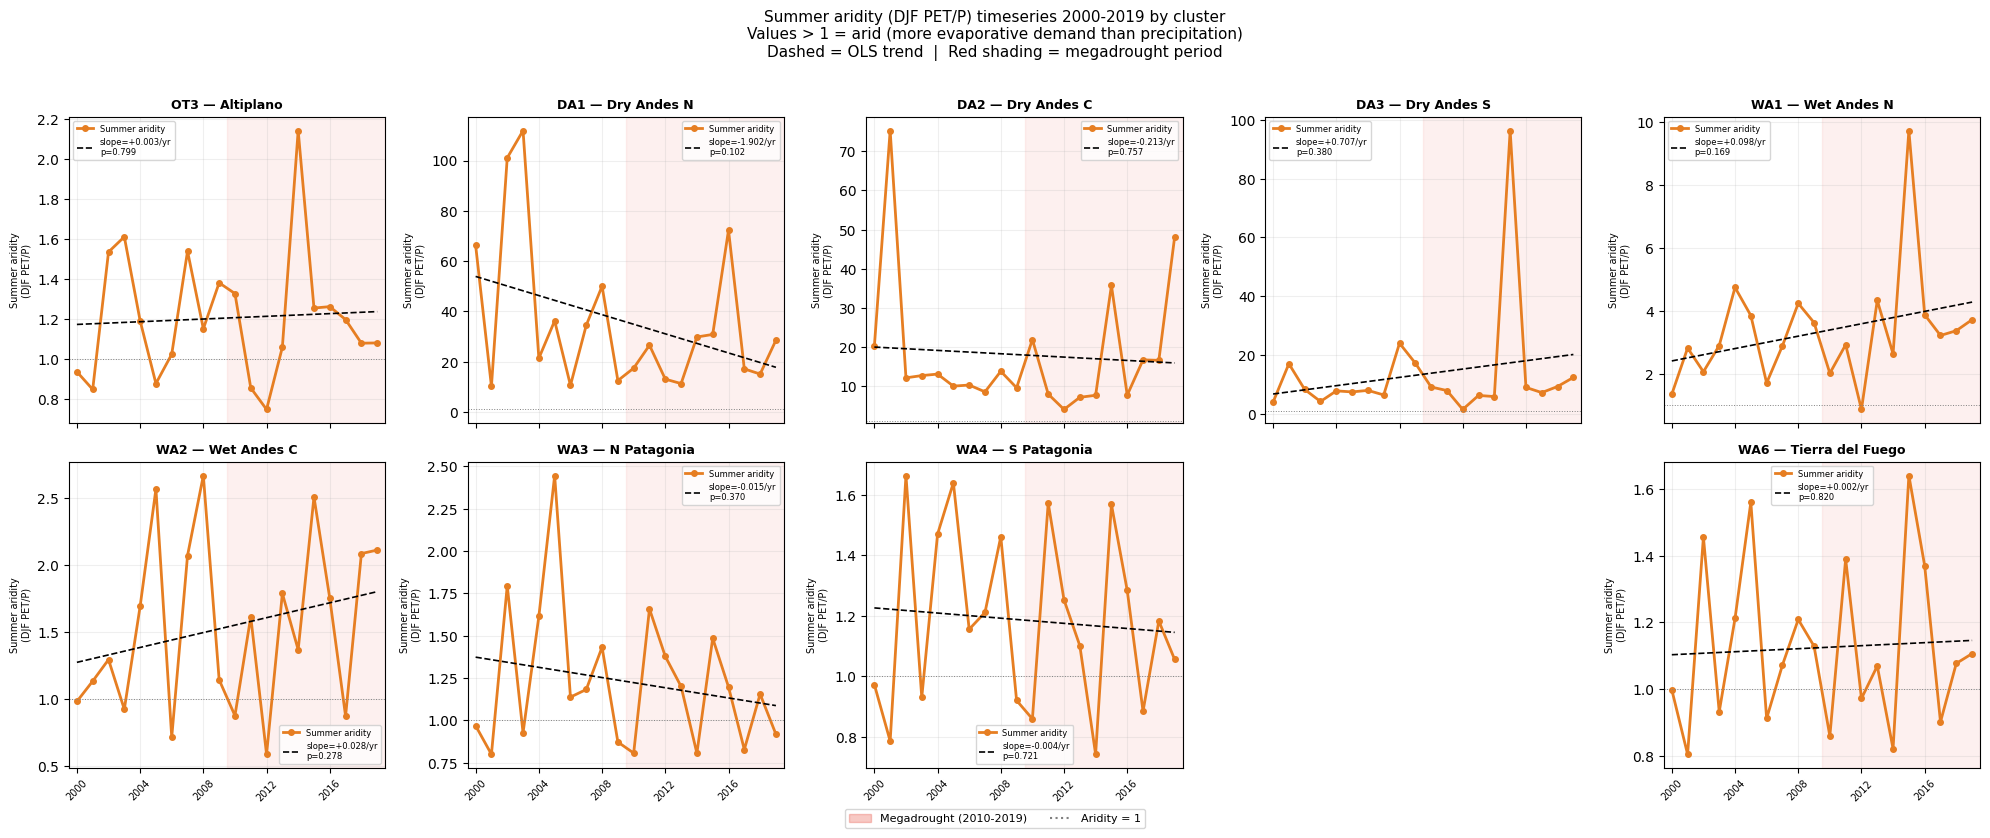


WA1 summer aridity decomposition — what is driving the trend?
  Summer aridity (PET/P)        : slope=+0.098/yr  r=+0.320  p=0.1686  ns
  Summer precip (mm)            : slope=-3.640/yr  r=-0.224  p=0.3431  ns
  Summer PET (mm)               : slope=+0.954/yr  r=+0.363  p=0.1160  ns


In [ ]:
# ── Cell XVI: Is summer aridity increasing over time? ─────────────────────
#
# Hypothesis: WA1 summers are becoming progressively more arid over
# 2000-2019 as precipitation declines and PET increases with warming.
# This would mean glaciers are becoming increasingly important as a
# seasonal water source independent of the megadrought signal.
#
# Note: CAMELS-CL CR2MET data covers 2000-2019 only. A longer baseline
# (CR2MET back to 1960) would be needed to place this in full context.
# That analysis is flagged as future work.

NON_GAUGE = ['date','year','month','day']
gauge_cols_p = [c for c in precip_df.columns if c not in NON_GAUGE]
gauge_cols_e = [c for c in pet_df.columns    if c not in NON_GAUGE]

# Annual summer aridity per gauge per year
p_djf_yr = (precip_df[precip_df['month'].isin([12,1,2])]
             .groupby('year')[gauge_cols_p].sum(numeric_only=True))
e_djf_yr = (pet_df[pet_df['month'].isin([12,1,2])]
             .groupby('year')[gauge_cols_e].sum(numeric_only=True))

# Annual aridity index per gauge per year
aridity_yr = e_djf_yr.div(p_djf_yr.where(p_djf_yr > 0))

# Annual precip per gauge per year
p_ann_yr = (precip_df.groupby('year')[gauge_cols_p]
             .sum(numeric_only=True))
e_ann_yr = (pet_df.groupby('year')[gauge_cols_e]
             .sum(numeric_only=True))
aridity_ann_yr = e_ann_yr.div(p_ann_yr.where(p_ann_yr > 0))

# ── Cluster-mean aridity timeseries ───────────────────────────────────────
trend_records = []
for cl in CLUSTERS:
    gauges = [str(gid) for gid, info in GAUGE_INFO_FRAC.items()
              if info['clusters'][0] == cl]
    gauges_in_data = [g for g in gauges if g in aridity_yr.columns]
    if not gauges_in_data:
        continue
    for year in YEARS:
        if year not in aridity_yr.index:
            continue
        trend_records.append({
            'cluster':        cl,
            'year':           year,
            'aridity_summer': aridity_yr.loc[year, gauges_in_data].median(),
            'aridity_ann':    aridity_ann_yr.loc[
                year, [g for g in gauges_in_data
                       if g in aridity_ann_yr.columns]].median(),
            'precip_summer':  p_djf_yr.loc[
                year, gauges_in_data].median(),
            'pet_summer':     e_djf_yr.loc[
                year, [g for g in gauges_in_data
                       if g in e_djf_yr.columns]].median(),
        })

df_trend = pd.DataFrame(trend_records)

# ── Trend test per cluster ─────────────────────────────────────────────────
print('Summer aridity trend 2000-2019 by cluster (Mann-Kendall slope):')
print(f'{"Cluster":6s} {"Slope (yr⁻¹)":14s} {"p-value":10s} {"Sig":5s} '
      f'{"Direction"}')
print('-' * 55)

for cl in CLUSTERS:
    cl_df = df_trend[df_trend['cluster'] == cl].sort_values('year')
    if len(cl_df) < 5:
        continue
    y = cl_df['aridity_summer'].dropna()
    x = cl_df.loc[y.index, 'year'].values.astype(float)
    y = y.values
    if len(y) < 5:
        continue
    slope, intercept, r, p, se = stats.linregress(x, y)
    sig = ('***' if p < 0.001 else '**' if p < 0.01
           else '*' if p < 0.05 else 'ns')
    direction = 'increasing' if slope > 0 else 'decreasing'
    print(f'{cl:6s} {slope:+14.4f} {p:10.4f} {sig:5s} {direction}')

# ── Figure: timeseries of summer aridity by cluster ───────────────────────
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True)
axes_flat = axes.flatten()

for ax, cl in zip(axes_flat, CLUSTERS):
    cl_df = df_trend[df_trend['cluster'] == cl].sort_values('year')
    if len(cl_df) == 0:
        ax.set_visible(False)
        continue

    # Summer aridity timeseries
    ax.plot(cl_df['year'], cl_df['aridity_summer'],
            color='#e67e22', lw=2, marker='o', ms=4,
            label='Summer aridity')

    # Trend line
    y = cl_df['aridity_summer'].dropna().values
    x = cl_df.dropna(subset=['aridity_summer'])['year'].values.astype(float)
    if len(y) > 4:
        slope, intercept, r, p, _ = stats.linregress(x, y)
        xfit = np.array([x.min(), x.max()])
        ax.plot(xfit, slope*xfit + intercept,
                'k--', lw=1.2,
                label=f'slope={slope:+.3f}/yr\np={p:.3f}')

    # Shade drought periods
    ax.axvspan(2009.5, 2019.5, color='#e74c3c', alpha=0.08, zorder=0)
    ax.axhline(1.0, color='grey', lw=0.7, ls=':')

    ax.set_title(f'{cl} — {REGION_LABELS[cl]}',
                 fontsize=9, fontweight='bold')
    ax.set_ylabel('Summer aridity\n(DJF PET/P)', fontsize=7)
    ax.set_xlim(1999.5, 2019.5)
    ax.set_xticks(range(2000, 2020, 4))
    ax.tick_params(labelsize=7, axis='x', rotation=45)
    ax.grid(True, alpha=0.2)
    ax.legend(fontsize=6)

fig.legend(
    handles=[
        Patch(color='#e74c3c', alpha=0.3, label='Megadrought (2010-2019)'),
        plt.Line2D([0],[0], color='grey', ls=':', label='Aridity = 1'),
    ],
    loc='lower center', ncol=2, fontsize=8,
    bbox_to_anchor=(0.5, -0.02))

fig.suptitle(
    'Summer aridity (DJF PET/P) timeseries 2000-2019 by cluster\n'
    'Values > 1 = arid (more evaporative demand than precipitation)\n'
    'Dashed = OLS trend  |  Red shading = megadrought period',
    fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(f'{DROUGHT_DIR}/summer_aridity_trend_by_cluster.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── WA1 decomposition: is aridity increasing due to precip or PET? ────────
print('\nWA1 summer aridity decomposition — what is driving the trend?')
wa1_df = df_trend[df_trend['cluster'] == 'WA1'].sort_values('year')

for var, label in [('aridity_summer', 'Summer aridity (PET/P)'),
                    ('precip_summer',  'Summer precip (mm)'),
                    ('pet_summer',     'Summer PET (mm)')]:
    y = wa1_df[var].dropna().values
    x = wa1_df.dropna(subset=[var])['year'].values.astype(float)
    if len(y) < 5:
        continue
    slope, _, r, p, _ = stats.linregress(x, y)
    sig = ('***' if p < 0.001 else '**' if p < 0.01
           else '*' if p < 0.05 else 'ns')
    print(f'  {label:30s}: slope={slope:+.3f}/yr  '
          f'r={r:+.3f}  p={p:.4f}  {sig}')

null result — no cluster shows a statistically significant trend in summer aridity over 2000-2019. All p-values are well above 0.05. probably too short a timeperiod and influenced by half the period being severe drought

Computing long-term summer aridity proxy by cluster...
Long-term records: 1,980
Year ranges by dataset:
  CR2MET: 1960 to 2019
  ERA5: 1979 to 2019
  CRU: 1901 to 2019

Long-term summer aridity trend by cluster and dataset:
Cluster Dataset  Period          Slope/yr   r      p        Sig
-----------------------------------------------------------------
OT3    CR2MET   1960-2019          -0.0002 -0.114   0.3870 ns
OT3    ERA5     1979-2019          -0.0004 -0.223   0.1616 ns
OT3    CRU      1901-2019          +0.0003 +0.089   0.3382 ns

DA1    CR2MET   1960-2019          -0.0047 -0.147   0.2615 ns
DA1    ERA5     1979-2019          +0.0038 +0.196   0.2186 ns
DA1    CRU      1901-2019          +0.0010 +0.276   0.0024 **

DA2    CR2MET   1960-2019          -0.0049 -0.212   0.1040 ns
DA2    ERA5     1979-2019          +0.0001 +0.028   0.8632 ns
DA2    CRU      1901-2019          +0.0005 +0.051   0.5852 ns

DA3    CR2MET   1960-2019          -0.0033 -0.103   0.4353 ns
DA3    ERA5     1979-20

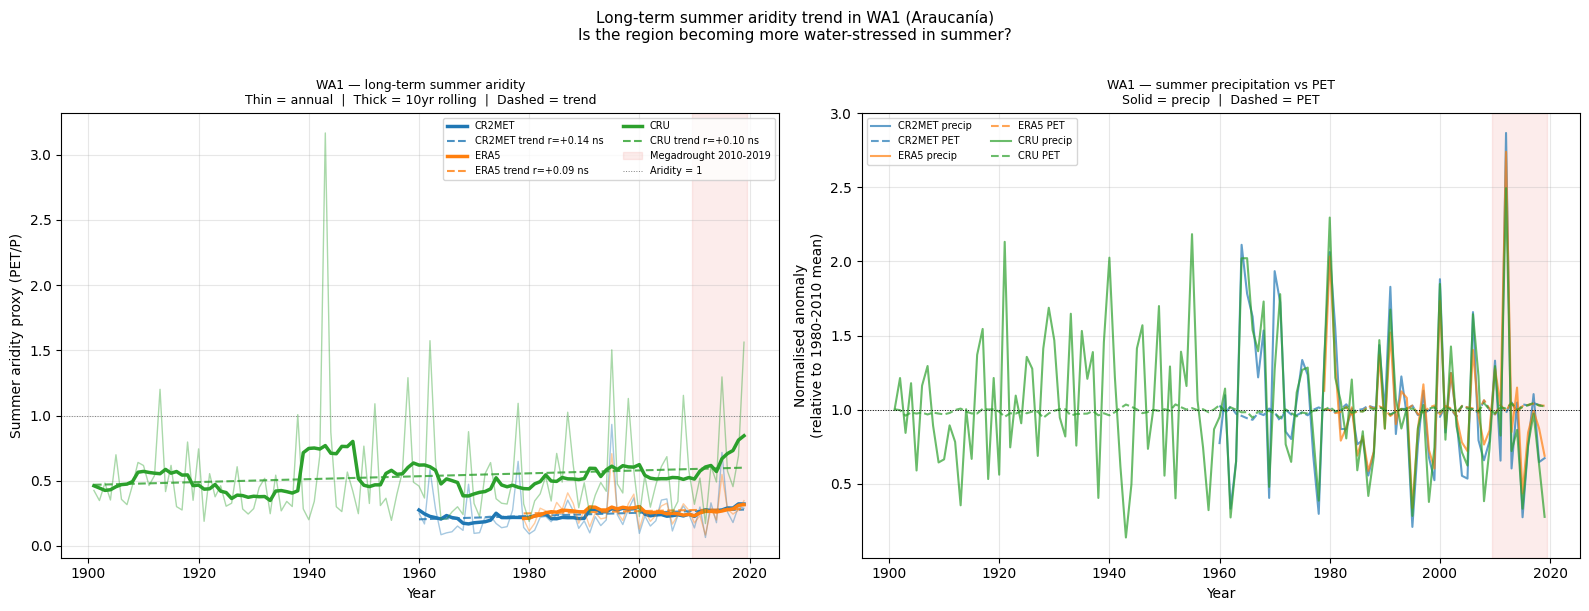

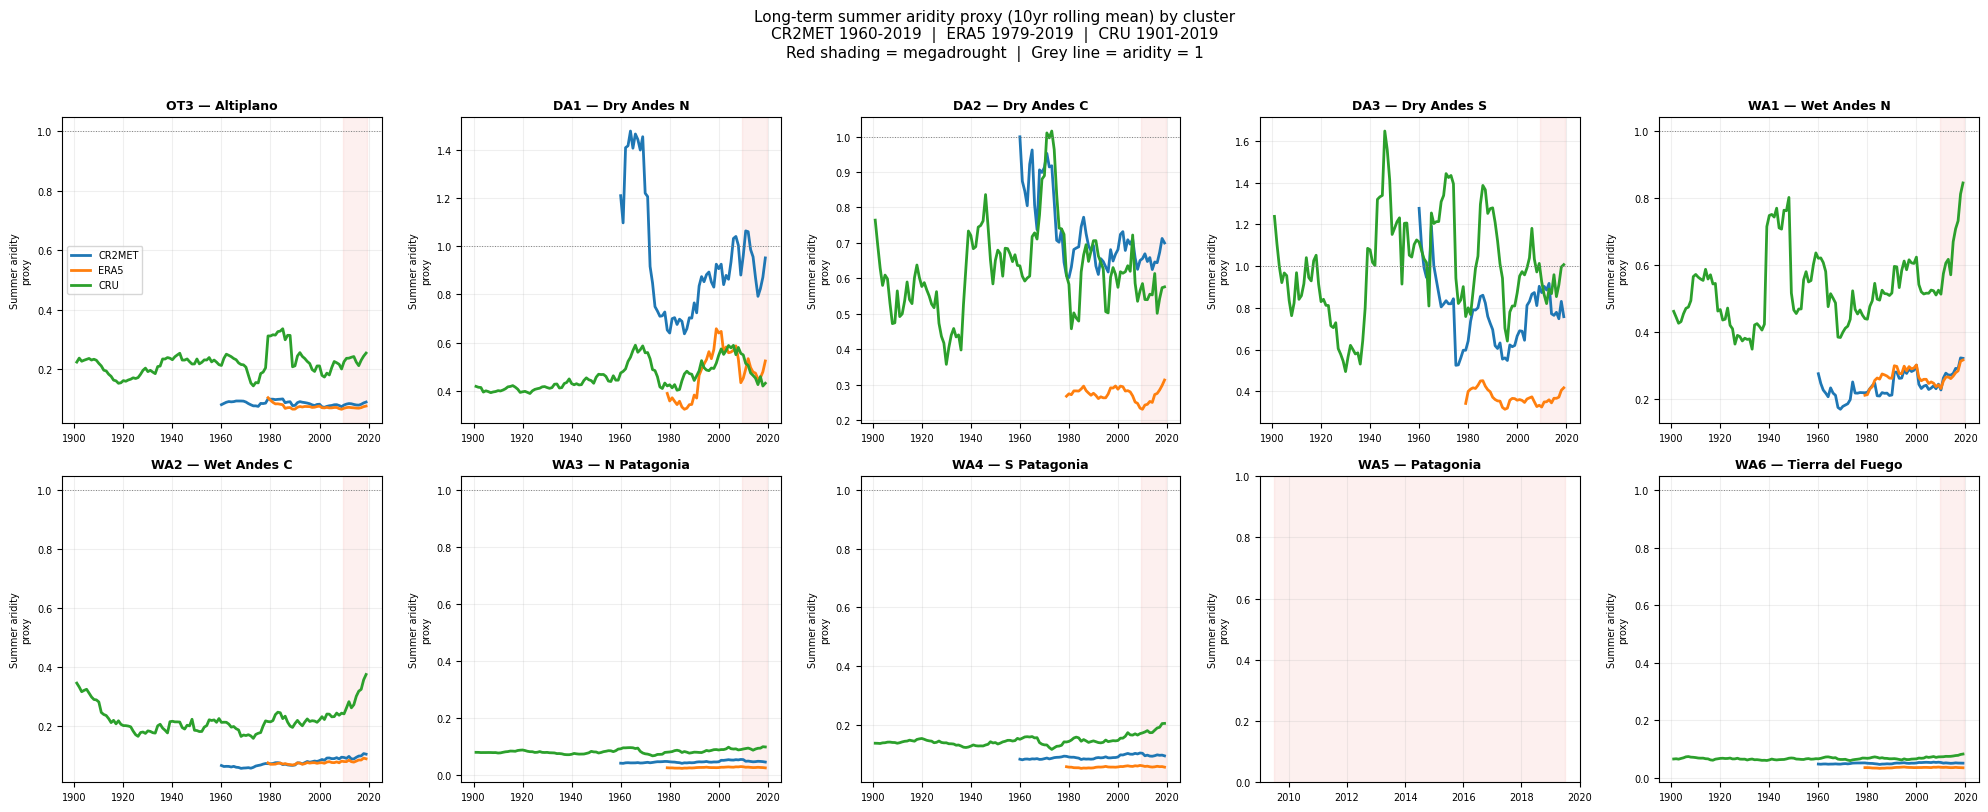


WA1 summer trend decomposition — precip vs PET:
Dataset  Variable                  Slope/yr   r      p        Sig
-----------------------------------------------------------------
CR2MET   Summer precip (mm)           -1.2553 -0.181   0.1667 ns
CR2MET   Summer PET proxy (mm)        +0.0337 +0.446   0.0004 ***
CR2MET   Summer tmean (°C)            +0.0204 +0.446   0.0004 ***

ERA5     Summer precip (mm)           -0.2957 -0.044   0.7866 ns
ERA5     Summer PET proxy (mm)        +0.0363 +0.380   0.0144 *
ERA5     Summer tmean (°C)            +0.0220 +0.380   0.0144 *

CRU      Summer precip (mm)           -0.1023 -0.066   0.4756 ns
CRU      Summer PET proxy (mm)        +0.0125 +0.439   0.0000 ***
CRU      Summer tmean (°C)            +0.0075 +0.439   0.0000 ***



In [ ]:
# ── Cell XVII: Long-term aridity trend using OGGM lista files ─────────────
#
# CAMELS-CL only covers 2000-2019 — too short for trend detection.
# OGGM lista files cover:
#   CR2MET: 1960-2021 (62 years)
#   ERA5:   1979-2019 (41 years)
#   CRU:    1901-2019 (119 years)
#
# We use glacier-location temperature and precipitation to compute
# a summer aridity proxy (PET_proxy / P) at glacier elevations.
# PET proxy from temperature via simplified Hamon equation.
# Relative trends are more reliable than absolute aridity values.

LISTA_START_YEARS = {
    'CR2MET': 1960,   # 744 rows  → 1960-2021
    'ERA5':   1979,   # 492 rows  → 1979-2019
    'CRU':    1901,   # 1428 rows → 1901-2019
}

def hamon_pet_monthly(tmean_c):
    """Simple temperature-based PET proxy (mm/month)."""
    return np.maximum(0, 0.55 * tmean_c + 8)

def load_lista_cluster_mean(ds_name, cluster, variable='temp'):
    """
    Load lista file and return long DataFrame with year, month,
    cluster_mean columns. Assigns years based on dataset start year.
    """
    start_year = LISTA_START_YEARS[ds_name]
    fname      = 'lista_temp.csv' if variable == 'temp' else 'lista_prec.csv'
    path       = f'{OUTPUT_ROOT}/{ds_name}/{cluster}/{fname}'
    if not os.path.exists(path):
        return None

    df      = pd.read_csv(path, header=0)
    n_rows  = len(df)
    n_years = n_rows // 12

    years  = np.repeat(range(start_year, start_year + n_years), 12)[:n_rows]
    months = (list(range(1, 13)) * n_years)[:n_rows]

    glacier_cols       = [c for c in df.columns]
    df['year']         = years
    df['month']        = months
    df['cluster_mean'] = df[glacier_cols].mean(axis=1)

    return df[['year', 'month', 'cluster_mean']]

print('Computing long-term summer aridity proxy by cluster...')
lt_records = []

for ds_name in ['CR2MET', 'ERA5', 'CRU']:
    for cl in CLUSTERS:
        gauges_in_cl = [gid for gid, info in GAUGE_INFO_FRAC.items()
                        if info['clusters'][0] == cl]
        if not gauges_in_cl:
            continue

        t_df = load_lista_cluster_mean(ds_name, cl, 'temp')
        p_df = load_lista_cluster_mean(ds_name, cl, 'prec')
        if t_df is None or p_df is None:
            continue

        merged = t_df.merge(p_df, on=['year','month'],
                            suffixes=('_temp','_prec'))

        summer = merged[merged['month'].isin([12, 1, 2])].copy()
        summer['pet_proxy'] = hamon_pet_monthly(
            summer['cluster_mean_temp'])

        ann_summer = summer.groupby('year').agg(
            precip_sum=('cluster_mean_prec', 'sum'),
            pet_sum   =('pet_proxy',          'sum'),
            tmean     =('cluster_mean_temp',   'mean'),
        ).reset_index()

        ann_summer['aridity_proxy'] = (
            ann_summer['pet_sum'] /
            ann_summer['precip_sum'].where(
                ann_summer['precip_sum'] > 0))

        for _, row in ann_summer.iterrows():
            lt_records.append({
                'dataset':       ds_name,
                'cluster':       cl,
                'year':          int(row['year']),
                'aridity_proxy': row['aridity_proxy'],
                'precip_sum':    row['precip_sum'],
                'pet_sum':       row['pet_sum'],
                'tmean':         row['tmean'],
            })

df_lt = pd.DataFrame(lt_records)

# Cap CRU at 2019 (TS4.04 ends there — extra rows are artifacts)
df_lt = df_lt[~((df_lt['dataset'] == 'CRU') & (df_lt['year'] > 2019))]

# Cap CR2MET at 2019 to match study period
df_lt = df_lt[~((df_lt['dataset'] == 'CR2MET') & (df_lt['year'] > 2019))]

print(f'Long-term records: {len(df_lt):,}')
print('Year ranges by dataset:')
for ds in ['CR2MET', 'ERA5', 'CRU']:
    sub = df_lt[df_lt['dataset'] == ds]
    if len(sub):
        print(f'  {ds}: {int(sub["year"].min())} to {int(sub["year"].max())}')

# ── Trend analysis ────────────────────────────────────────────────────────
print('\nLong-term summer aridity trend by cluster and dataset:')
print(f'{"Cluster":6s} {"Dataset":8s} {"Period":15s} '
      f'{"Slope/yr":10s} {"r":6s} {"p":8s} {"Sig"}')
print('-' * 65)

for cl in CLUSTERS:
    for ds_name in ['CR2MET', 'ERA5', 'CRU']:
        sub = (df_lt[(df_lt['cluster'] == cl) &
                     (df_lt['dataset']  == ds_name)]
               .dropna(subset=['aridity_proxy'])
               .sort_values('year'))
        if len(sub) < 10:
            continue
        x = sub['year'].values.astype(float)
        y = sub['aridity_proxy'].values
        slope, _, r, p, _ = stats.linregress(x, y)
        sig    = ('***' if p < 0.001 else '**' if p < 0.01
                  else '*' if p < 0.05 else 'ns')
        period = f'{int(x.min())}-{int(x.max())}'
        print(f'{cl:6s} {ds_name:8s} {period:15s} '
              f'{slope:+10.4f} {r:+6.3f} {p:8.4f} {sig}')
    print()

# ── Figure 1: WA1 long-term summer aridity ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
for ds_name in ['CR2MET', 'ERA5', 'CRU']:
    sub = (df_lt[(df_lt['cluster'] == 'WA1') &
                 (df_lt['dataset']  == ds_name)]
           .dropna(subset=['aridity_proxy'])
           .sort_values('year'))
    if len(sub) == 0:
        continue
    ax.plot(sub['year'], sub['aridity_proxy'],
            color=DS_COLORS[ds_name], lw=1.0, alpha=0.4)
    roll = (sub.set_index('year')['aridity_proxy']
               .rolling(10, center=True, min_periods=5).mean())
    ax.plot(roll.index, roll.values,
            color=DS_COLORS[ds_name], lw=2.5, alpha=1.0, label=ds_name)
    x = sub['year'].values.astype(float)
    y = sub['aridity_proxy'].values
    slope, intercept, r, p, _ = stats.linregress(x, y)
    sig = ('***' if p < 0.001 else '**' if p < 0.01
           else '*' if p < 0.05 else 'ns')
    ax.plot([x.min(), x.max()],
            [slope*x.min()+intercept, slope*x.max()+intercept],
            color=DS_COLORS[ds_name], lw=1.5, ls='--', alpha=0.8,
            label=f'{ds_name} trend r={r:+.2f} {sig}')

ax.axvspan(2009.5, 2019.5, color='#e74c3c', alpha=0.1, zorder=0,
           label='Megadrought 2010-2019')
ax.axhline(1.0, color='grey', lw=0.7, ls=':', label='Aridity = 1')
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Summer aridity proxy (PET/P)', fontsize=10)
ax.set_title('WA1 — long-term summer aridity\n'
             'Thin = annual  |  Thick = 10yr rolling  '
             '|  Dashed = trend', fontsize=9)
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

# Panel 2: WA1 decomposition — is it precip or PET driving any trend?
ax = axes[1]
for ds_name in ['CR2MET', 'ERA5', 'CRU']:
    sub = (df_lt[(df_lt['cluster'] == 'WA1') &
                 (df_lt['dataset']  == ds_name)]
           .dropna(subset=['precip_sum','pet_sum'])
           .sort_values('year'))
    if len(sub) == 0:
        continue
    ref = sub[sub['year'].between(1980, 2010)]
    if len(ref) == 0:
        ref = sub
    p_norm   = sub['precip_sum'] / ref['precip_sum'].mean()
    pet_norm = sub['pet_sum']    / ref['pet_sum'].mean()
    ax.plot(sub['year'].values, p_norm.values,
            color=DS_COLORS[ds_name], lw=1.5, ls='-',
            alpha=0.7, label=f'{ds_name} precip')
    ax.plot(sub['year'].values, pet_norm.values,
            color=DS_COLORS[ds_name], lw=1.5, ls='--',
            alpha=0.7, label=f'{ds_name} PET')

ax.axvspan(2009.5, 2019.5, color='#e74c3c', alpha=0.1, zorder=0)
ax.axhline(1.0, color='k', lw=0.7, ls=':')
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Normalised anomaly\n(relative to 1980-2010 mean)',
              fontsize=10)
ax.set_title('WA1 — summer precipitation vs PET\n'
             'Solid = precip  |  Dashed = PET', fontsize=9)
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

fig.suptitle(
    'Long-term summer aridity trend in WA1 (Araucanía)\n'
    'Is the region becoming more water-stressed in summer?',
    fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(f'{DROUGHT_DIR}/WA1_longterm_aridity_trend.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2: All clusters ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=False)
axes_flat = axes.flatten()

for ax, cl in zip(axes_flat, CLUSTERS):
    for ds_name in ['CR2MET', 'ERA5', 'CRU']:
        sub = (df_lt[(df_lt['cluster'] == cl) &
                     (df_lt['dataset']  == ds_name)]
               .dropna(subset=['aridity_proxy'])
               .sort_values('year'))
        if len(sub) < 5:
            continue
        roll = (sub.set_index('year')['aridity_proxy']
                   .rolling(10, center=True, min_periods=5).mean())
        ax.plot(roll.index, roll.values,
                color=DS_COLORS[ds_name], lw=2, label=ds_name)

    ax.axvspan(2009.5, 2019.5, color='#e74c3c', alpha=0.08, zorder=0)
    ax.axhline(1.0, color='grey', lw=0.7, ls=':')
    ax.set_title(f'{cl} — {REGION_LABELS[cl]}', fontsize=9,
                 fontweight='bold')
    ax.set_ylabel('Summer aridity\nproxy', fontsize=7)
    ax.grid(True, alpha=0.2)
    ax.tick_params(labelsize=7)

axes_flat[0].legend(fontsize=7)
for ax in axes_flat[len(CLUSTERS):]:
    ax.set_visible(False)

fig.suptitle(
    'Long-term summer aridity proxy (10yr rolling mean) by cluster\n'
    'CR2MET 1960-2019  |  ERA5 1979-2019  |  CRU 1901-2019\n'
    'Red shading = megadrought  |  Grey line = aridity = 1',
    fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(f'{DROUGHT_DIR}/longterm_aridity_all_clusters.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── WA1 decomposition table ───────────────────────────────────────────────
print('\nWA1 summer trend decomposition — precip vs PET:')
print(f'{"Dataset":8s} {"Variable":25s} {"Slope/yr":10s} '
      f'{"r":6s} {"p":8s} {"Sig"}')
print('-' * 65)
for ds_name in ['CR2MET', 'ERA5', 'CRU']:
    sub = (df_lt[(df_lt['cluster'] == 'WA1') &
                 (df_lt['dataset']  == ds_name)]
           .dropna(subset=['precip_sum','pet_sum'])
           .sort_values('year'))
    if len(sub) < 10:
        continue
    for var, label in [('precip_sum', 'Summer precip (mm)'),
                        ('pet_sum',    'Summer PET proxy (mm)'),
                        ('tmean',      'Summer tmean (°C)')]:
        x = sub['year'].values.astype(float)
        y = sub[var].dropna().values
        if len(y) < 10:
            continue
        slope, _, r, p, _ = stats.linregress(x[:len(y)], y)
        sig = ('***' if p < 0.001 else '**' if p < 0.01
               else '*' if p < 0.05 else 'ns')
        print(f'{ds_name:8s} {label:25s} {slope:+10.4f} '
              f'{r:+6.3f} {p:8.4f} {sig}')
    print()

WE find suggestive but not fully robust evidence of increasing summer aridity at glacier locations in the Wet Andes (WA2) and Patagonia (WA3-WA4) over the long-term record, particularly in CR2MET and CRU. WA1 shows no significant trend despite the megadrought signal — the megadrought appears to be an episodic event rather than part of a secular drying trend at glacier elevations in Araucanía. These findings warrant further investigation using station-based records and longer reanalysis products.

RE WA1: 
The WA1 summer aridity trend is temperature-driven, not precipitation-driven:
Across all three datasets, the pattern is identical:

Summer precipitation trend: non-significant in all three (CR2MET p=0.17, ERA5 p=0.79, CRU p=0.48). WA1 summer precipitation is not declining.
Summer temperature trend: highly significant in all three (CR2MET p=0.0004, ERA5 p=0.014, CRU p<0.0001). WA1 glacier locations are warming at +0.020°C/yr (CR2MET), +0.022°C/yr (ERA5), and +0.008°C/yr (CRU).
Summer PET proxy trend: identical significance and magnitude to temperature because PET is computed directly from temperature — this confirms the PET increase is entirely temperature-driven.

The warming rates are substantial:

CR2MET: +0.020°C/yr over 1960-2019 = +1.2°C over 60 years
ERA5: +0.022°C/yr over 1979-2019 = +0.9°C over 40 years
CRU: +0.008°C/yr over 1901-2019 = +0.9°C over 119 years

WA1 glacier locations have experienced robust and consistent summer warming of approximately +0.9 to +1.2°C since 1960, significant across all three climate datasets (p<0.001 to p=0.014). Summer precipitation shows no significant trend. This warming increases potential evapotranspiration and accelerates glacier melt, while precipitation-fed streamflow remains stable — meaning the relative importance of glacier melt as a summer water source is likely increasing over the long term, independent of the megadrought signal. This secular warming trend is distinct from but compounded by the episodic megadrought precipitation deficit observed in 2010-2019

In [ ]:
# Does OGGM show increasing glacier melt in WA1 over 2000-2019?
import numpy as np
import pandas as pd
from scipy import stats

print('WA1 annual glacier melt trend 2000-2019 (OGGM):')
print(f'{"Dataset":8s} {"Slope (m³/yr²)":15s} {"r":6s} {"p":8s} {"Sig"}')
print('-' * 50)

for ds_name in ['CR2MET', 'ERA5', 'CRU']:
    # Get all WA1 gauges
    wa1_gauges = [gid for gid, info in GAUGE_INFO_FRAC.items()
                  if 'WA1' in info['clusters']]

    ann_melt = np.zeros(len(YEARS))
    n_gauges  = 0

    for gauge_id in wa1_gauges:
        res = RESULTS[ds_name].get(gauge_id)
        if res is None:
            continue
        m  = res['monthly']
        cy = res.get('complete_years', YEARS)
        ann = (m[m['year'].isin(cy)]
               .groupby('year')['melt_on_glacier_m3'].sum()
               .reindex(YEARS, fill_value=np.nan))
        ann_melt += ann.fillna(0).values
        n_gauges += 1

    if n_gauges == 0:
        continue

    # Trend test
    valid = ~np.isnan(ann_melt) & (ann_melt > 0)
    x = np.array(YEARS)[valid].astype(float)
    y = ann_melt[valid]
    slope, intercept, r, p, _ = stats.linregress(x, y)
    sig = ('***' if p < 0.001 else '**' if p < 0.01
           else '*' if p < 0.05 else 'ns')
    print(f'{ds_name:8s} {slope:+15.0f} {r:+6.3f} {p:8.4f} {sig}')

print(f'\n(Based on {n_gauges} WA1 gauges, complete years only)')

WA1 annual glacier melt trend 2000-2019 (OGGM):
Dataset  Slope (m³/yr²)  r      p        Sig
--------------------------------------------------
CR2MET           +740369 +0.015   0.9500 ns
ERA5            +6528426 +0.137   0.5648 ns
CRU             +2259380 +0.084   0.7262 ns

(Based on 50 WA1 gauges, complete years only)


glacier locations in WA1 are warming significantly (+0.9 to +1.2°C since 1960, robust across all three datasets), but OGGM does not show a statistically significant increase in glacier melt over the 2000-2019 study period. This could reflect the short study window, the fixed calibration structure, or compensating effects between increasing melt and declining solid precipitation. Resolving this would require either a longer OGGM simulation or a sensitivity analysis with evolving mu_star — both flagged as future work.

If we trust that glacier melt isnt accelerating (i dont think i do...), this actually reinforces why the megadrought finding is so important: even without a detectable long-term melt trend, glaciers provided critical hydrological stability during the drought precisely because melt was stable while everything else declined. The future risk is not that melt will accelerate dramatically (though it may) but that glaciers will eventually lose enough mass to sustain even current melt rates — the peak water problem.

## Ale's snow fraction question: 

In [8]:
# ── Load mu_star_glacierwide from per-glacier JSON files ──────────────────
import json

def load_mustar_cluster(ds_name, cluster):
    """Read all local_mustar.json files and return median mu_star_glacierwide."""
    base = f'{OUTPUT_ROOT}/{ds_name}/{cluster}/per_glacier'
    if not os.path.exists(base):
        return np.nan, 0
    mu_vals = []
    for root, dirs, files in os.walk(base):
        for fname in files:
            if fname == 'local_mustar.json':
                try:
                    with open(os.path.join(root, fname)) as f:
                        d = json.load(f)
                    val = d.get('mu_star_glacierwide', None)
                    if val is not None and not np.isnan(float(val)):
                        mu_vals.append(float(val))
                except Exception:
                    pass
    if not mu_vals:
        return np.nan, 0
    return np.median(mu_vals), len(mu_vals)

print('Loading mu_star_glacierwide for all clusters and datasets...')
print('(This will take a few minutes — reading one JSON per glacier)')
print()

mustar_results = {}
for ds_name in ['CR2MET', 'ERA5', 'CRU']:
    mustar_results[ds_name] = {}
    for cl in CLUSTERS:
        med, n = load_mustar_cluster(ds_name, cl)
        mustar_results[ds_name][cl] = med
        print(f'  {ds_name} {cl}: median μ* = {med:.2f} '
              f'mm °C⁻¹ month⁻¹ (n={n} glaciers)')
    print()

# ── Print full comparison table ───────────────────────────────────────────
print('\nMedian μ* (mm °C⁻¹ month⁻¹) by cluster and dataset:')
print(f'{"Cluster":6s}  {"CR2MET":10s}  {"ERA5":10s}  {"CRU":10s}  '
      f'{"ERA5/CR2":10s}  {"CRU/CR2"}')
print('-' * 65)
for cl in CLUSTERS:
    cr2 = mustar_results['CR2MET'].get(cl, np.nan)
    era = mustar_results['ERA5'].get(cl, np.nan)
    cru = mustar_results['CRU'].get(cl, np.nan)
    r_era = era/cr2 if cr2 > 0 else np.nan
    r_cru = cru/cr2 if cr2 > 0 else np.nan
    print(f'{cl:6s}  {cr2:10.2f}  {era:10.2f}  {cru:10.2f}  '
          f'{r_era:10.2f}  {r_cru:.2f}')

# ── Convert to daily units for literature comparison ─────────────────────
print('\nμ* in daily units (mm d⁻¹ °C⁻¹, divide monthly by 30.4):')
print('Literature range: 3-10 mm d⁻¹ °C⁻¹ (Hock, 2003)')
print(f'{"Cluster":6s}  {"CR2MET":10s}  {"ERA5":10s}  {"CRU":10s}')
print('-' * 40)
for cl in CLUSTERS:
    cr2 = mustar_results['CR2MET'].get(cl, np.nan) / 30.4
    era = mustar_results['ERA5'].get(cl, np.nan)   / 30.4
    cru = mustar_results['CRU'].get(cl, np.nan)    / 30.4
    print(f'{cl:6s}  {cr2:10.3f}  {era:10.3f}  {cru:10.3f}')

Loading mu_star_glacierwide for all clusters and datasets...
(This will take a few minutes — reading one JSON per glacier)

  CR2MET OT3: median μ* = 528.74 mm °C⁻¹ month⁻¹ (n=34 glaciers)
  CR2MET DA1: median μ* = 442.72 mm °C⁻¹ month⁻¹ (n=421 glaciers)
  CR2MET DA2: median μ* = 106.33 mm °C⁻¹ month⁻¹ (n=200 glaciers)
  CR2MET DA3: median μ* = 50.70 mm °C⁻¹ month⁻¹ (n=409 glaciers)
  CR2MET WA1: median μ* = 33.68 mm °C⁻¹ month⁻¹ (n=672 glaciers)
  CR2MET WA2: median μ* = 56.81 mm °C⁻¹ month⁻¹ (n=2919 glaciers)
  CR2MET WA3: median μ* = 91.46 mm °C⁻¹ month⁻¹ (n=447 glaciers)
  CR2MET WA4: median μ* = 70.47 mm °C⁻¹ month⁻¹ (n=4716 glaciers)
  CR2MET WA5: median μ* = 101.27 mm °C⁻¹ month⁻¹ (n=709 glaciers)
  CR2MET WA6: median μ* = 84.13 mm °C⁻¹ month⁻¹ (n=2633 glaciers)

  ERA5 OT3: median μ* = 558.27 mm °C⁻¹ month⁻¹ (n=34 glaciers)
  ERA5 DA1: median μ* = 522.70 mm °C⁻¹ month⁻¹ (n=422 glaciers)
  ERA5 DA2: median μ* = 541.26 mm °C⁻¹ month⁻¹ (n=200 glaciers)
  ERA5 DA3: median μ* = 178.